Burst duration distribution
  duration_s: array(2917,), mean=0.0750442


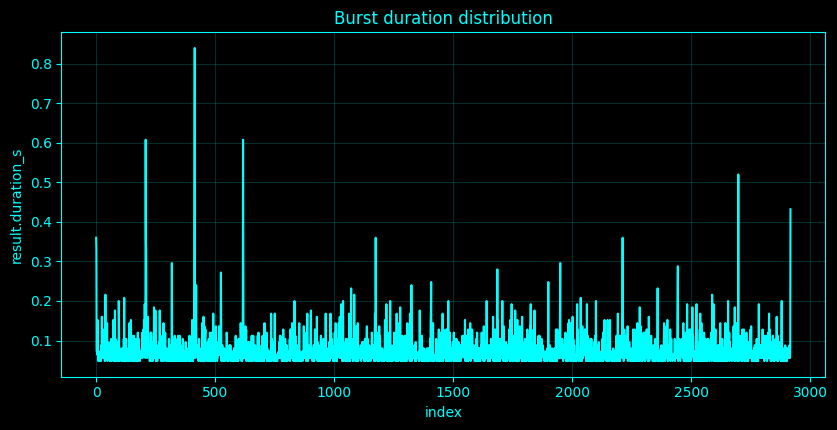

In [62]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_228():
    idx = 228
    name = 'Burst duration distribution'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    return ({'duration_s': [(r[2] - r[1] + 1) / _fs for r in rows]}, locals().get('__plot_spec', None))
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_228,_plot_spec=_compute_method_228()
print('Burst duration distribution')
if isinstance(result_228,dict):
    for _k,_v in result_228.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_228)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_228)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst duration distribution',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst duration distribution',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst duration distribution',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">229. Burst amplitude distribution</h3>
<p>Burst amplitude is the maximum narrow-band analytic-envelope amplitude within each detected burst.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Burst amplitude distribution
  peak_envelope_amplitude: array(2917,), mean=0.370878


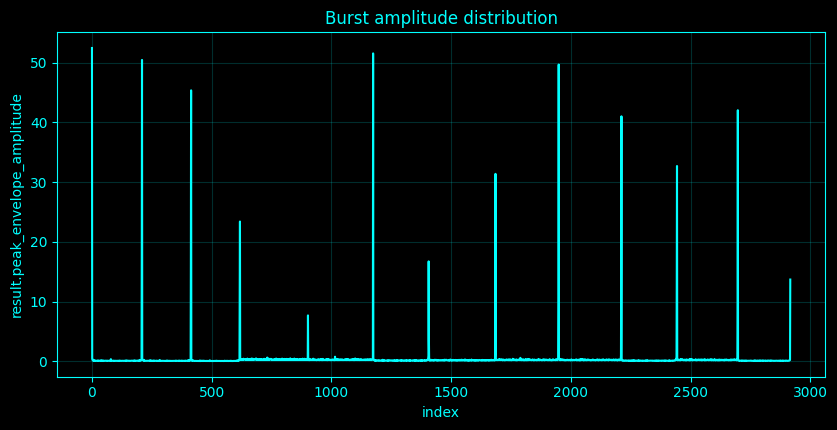

In [63]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_229():
    idx = 229
    name = 'Burst amplitude distribution'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    return ({'peak_envelope_amplitude': [r[4] for r in rows]}, locals().get('__plot_spec', None))
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_229,_plot_spec=_compute_method_229()
print('Burst amplitude distribution')
if isinstance(result_229,dict):
    for _k,_v in result_229.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_229)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_229)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst amplitude distribution',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst amplitude distribution',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst amplitude distribution',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">230. Burst frequency distribution</h3>
<p>Burst frequency is sampled from the analytic instantaneous frequency at each burst's envelope peak.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Burst frequency distribution
  peak_instantaneous_frequency_hz: array(2917,), mean=20.0553


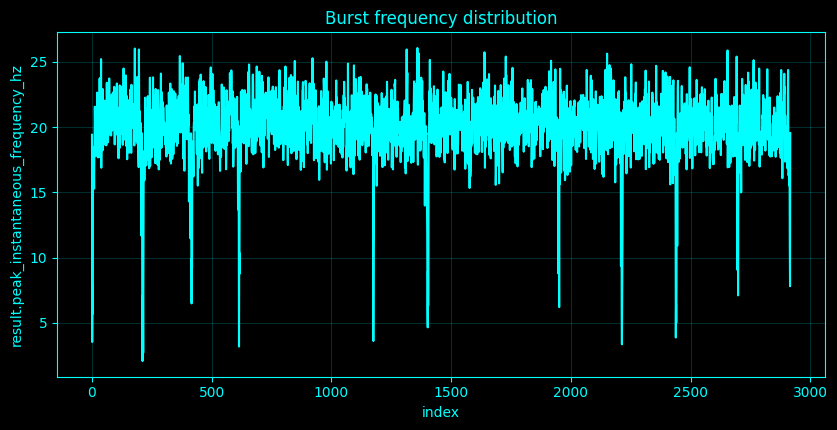

In [64]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_230():
    idx = 230
    name = 'Burst frequency distribution'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    z = _analytic_band(BANDS['beta'])
    phi = np.unwrap(np.angle(z), axis=0)
    inst = np.gradient(phi, axis=0) * _fs / (2 * np.pi)
    return ({'peak_instantaneous_frequency_hz': [float(inst[r[3], r[0]]) for r in rows]}, locals().get('__plot_spec', None))
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_230,_plot_spec=_compute_method_230()
print('Burst frequency distribution')
if isinstance(result_230,dict):
    for _k,_v in result_230.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_230)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_230)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst frequency distribution',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst frequency distribution',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst frequency distribution',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">231. Burst inter-event interval</h3>
<p>Burst inter-event intervals are differences between successive burst-peak times within the same channel.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Burst inter-event interval
  inter_event_intervals_s: array(2905,), mean=0.441633


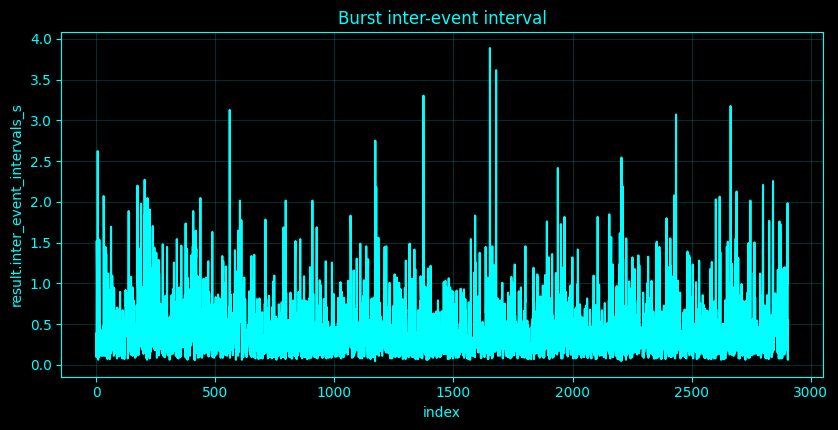

In [65]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_231():
    idx = 231
    name = 'Burst inter-event interval'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    by = {j: [] for j in range(C)}
    for r in rows:
        by[r[0]].append(r[3] / _fs)
    iei = [np.diff(v) for v in by.values() if len(v) >= 2]
    return ({'inter_event_intervals_s': np.concatenate(iei).tolist() if iei else []}, locals().get('__plot_spec', None))
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_231,_plot_spec=_compute_method_231()
print('Burst inter-event interval')
if isinstance(result_231,dict):
    for _k,_v in result_231.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_231)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_231)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst inter-event interval',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst inter-event interval',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst inter-event interval',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">232. Burst co-occurrence networks</h3>
<p>Burst co-occurrence connects channels when burst peaks fall within a fixed temporal tolerance; edge weights are normalized co-occurrence counts.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Burst co-occurrence networks
  cooccurrence_matrix: array(12, 12), mean=0.481878


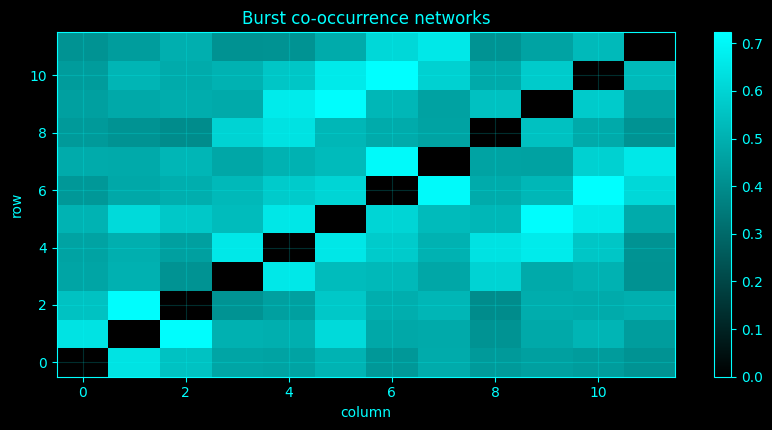

In [66]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_232():
    idx = 232
    name = 'Burst co-occurrence networks'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    peaks = {j: np.array([r[3] for r in rows if r[0] == j], int) for j in range(C)}
    M = np.zeros((C, C))
    tol = int(0.1 * _fs)
    for i in range(C):
        for j in range(i + 1, C):
            if len(peaks[i]) and len(peaks[j]):
                cnt = sum((np.any(np.abs(peaks[j] - p) <= tol) for p in peaks[i]))
                v = cnt / max(len(peaks[i]), len(peaks[j]), 1)
                M[i, j] = M[j, i] = v
    return ({'cooccurrence_matrix': M}, locals().get('__plot_spec', None))
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_232,_plot_spec=_compute_method_232()
print('Burst co-occurrence networks')
if isinstance(result_232,dict):
    for _k,_v in result_232.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_232)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_232)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst co-occurrence networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst co-occurrence networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst co-occurrence networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">233. Burst propagation analysis</h3>
<p>Burst propagation is summarized by the lag of maximal cross-correlation between narrow-band envelopes; the antisymmetric lag matrix describes relative timing, not anatomical propagation speed.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Burst propagation analysis
  propagation_lag_matrix_s: array(12, 12), mean=0


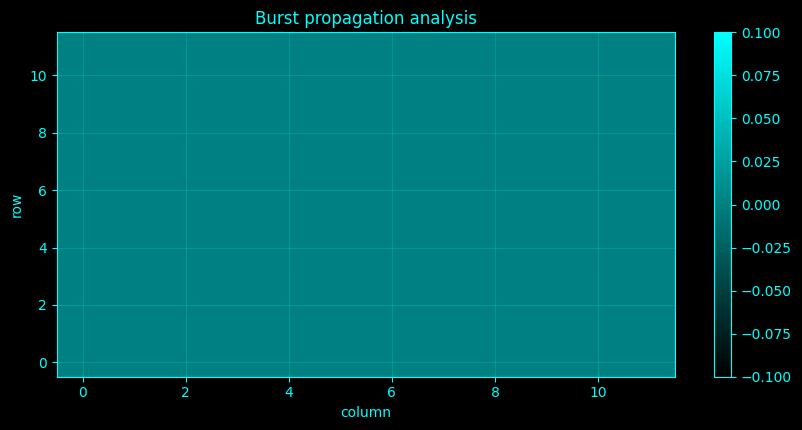

In [67]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_233():
    idx = 233
    name = 'Burst propagation analysis'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    env = np.abs(_analytic_band(BANDS['beta']))
    lags = np.arange(-int(0.25 * _fs), int(0.25 * _fs) + 1)
    M = np.zeros((C, C))
    for i in range(C):
        for j in range(i + 1, C):
            x = env[:, i] - env[:, i].mean()
            y = env[:, j] - env[:, j].mean()
            cc = signal.correlate(y, x, mode='full', method='fft')
            ll = signal.correlation_lags(len(y), len(x))
            m = np.isin(ll, lags)
            lag = ll[m][np.argmax(cc[m])] / _fs
            M[i, j] = lag
            M[j, i] = -lag
    return ({'propagation_lag_matrix_s': M}, locals().get('__plot_spec', None))
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_233,_plot_spec=_compute_method_233()
print('Burst propagation analysis')
if isinstance(result_233,dict):
    for _k,_v in result_233.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_233)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_233)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst propagation analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst propagation analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst propagation analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">234. Burst-triggered average spectrum</h3>
<p>A burst-triggered average spectrum averages PSDs from fixed windows centered on burst peaks.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Burst-triggered average spectrum
  burst_triggered_mean_spectrum: array(55,), mean=0.00166908


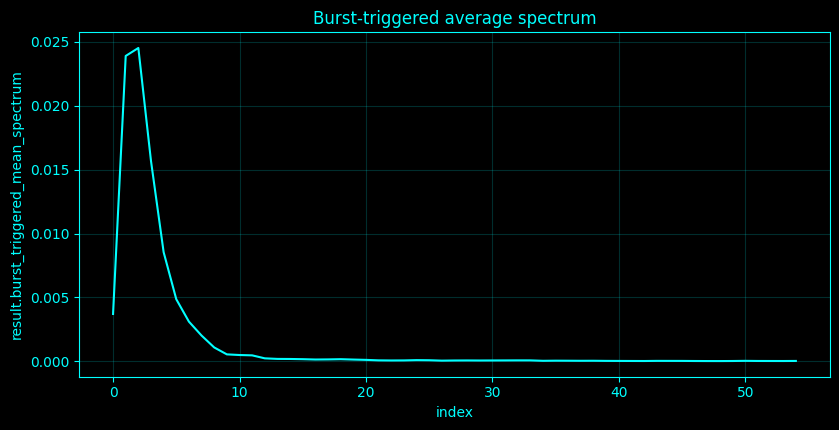

In [68]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_234():
    idx = 234
    name = 'Burst-triggered average spectrum'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    vals = []
    for e in valid:
        ff, pp = _psd_of(X[e - half:e + half, [0]])
        vals.append(pp[:, 0])
    return ({'burst_triggered_mean_spectrum': np.mean(vals, axis=0) if vals else np.array([])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_234,_plot_spec=_compute_method_234()
print('Burst-triggered average spectrum')
if isinstance(result_234,dict):
    for _k,_v in result_234.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_234)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_234)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst-triggered average spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst-triggered average spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst-triggered average spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">235. Burst-triggered phase synchrony</h3>
<p>Burst-triggered phase synchrony averages PLV measured within burst-centered windows.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [69]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _plv(d):
    return float(np.abs(np.mean(np.exp(1j * d))))

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_235():
    idx = 235
    name = 'Burst-triggered phase synchrony'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    ph = np.angle(_analytic_band(BANDS['beta']))
    vals = []
    for e in valid:
        d = ph[e - half:e + half, 0] - ph[e - half:e + half, min(1, C - 1)]
        vals.append(_plv(d))
    return ({'burst_triggered_PLV': float(np.mean(vals)) if vals else np.nan}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_235,_plot_spec=_compute_method_235()
print('Burst-triggered phase synchrony')
if isinstance(result_235,dict):
    for _k,_v in result_235.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_235)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_235)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst-triggered phase synchrony',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst-triggered phase synchrony',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst-triggered phase synchrony',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Burst-triggered phase synchrony
  burst_triggered_PLV: 0.7506852796380844


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">236. Burst-triggered coherence</h3>
<p>Burst-triggered coherence averages magnitude-squared coherence within burst-centered windows.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [70]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_236():
    idx = 236
    name = 'Burst-triggered coherence'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    vals = []
    for e in valid:
        ff, cc = signal.coherence(X[e - half:e + half, 0], X[e - half:e + half, min(1, C - 1)], fs=_fs, nperseg=min(128, 2 * half))
        m = (ff >= 13) & (ff < 30)
        vals.append(float(np.mean(cc[m])) if np.any(m) else np.nan)
    return ({'burst_triggered_beta_coherence': float(np.nanmean(vals)) if vals else np.nan}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_236,_plot_spec=_compute_method_236()
print('Burst-triggered coherence')
if isinstance(result_236,dict):
    for _k,_v in result_236.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_236)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_236)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst-triggered coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst-triggered coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst-triggered coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Burst-triggered coherence
  burst_triggered_beta_coherence: 1.0


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">237. Narrowband envelope spectra</h3>
<p>The modulation/envelope spectrum is the PSD of a narrow-band analytic amplitude envelope. Its frequencies describe how rapidly oscillation amplitude itself fluctuates.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Narrowband envelope spectra
  envelope_power_shape: array(2,), mean=47


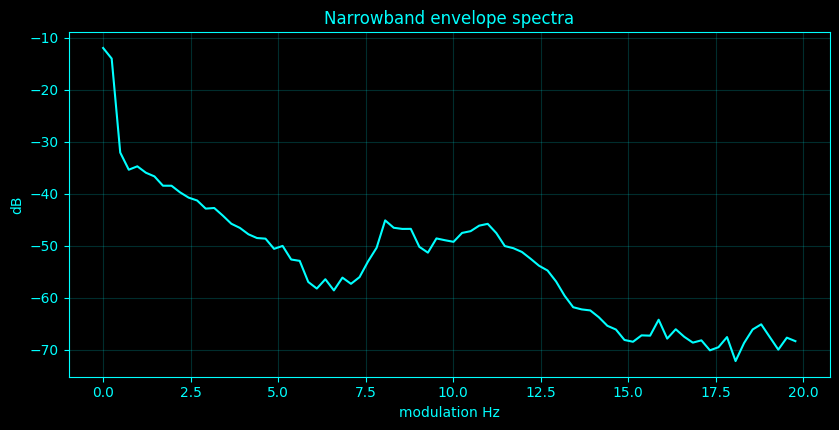

In [71]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_237():
    idx = 237
    name = 'Narrowband envelope spectra'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    __plot_spec = ('summary', 10 * np.log10(PE[:, 0] + EPS), name, fE, 'modulation Hz', 'dB')
    return ({'envelope_power_shape': PE.shape}, locals().get('__plot_spec', None))
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_237,_plot_spec=_compute_method_237()
print('Narrowband envelope spectra')
if isinstance(result_237,dict):
    for _k,_v in result_237.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_237)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_237)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Narrowband envelope spectra',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Narrowband envelope spectra',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Narrowband envelope spectra',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">238. Envelope power spectrum</h3>
<p>The modulation/envelope spectrum is the PSD of a narrow-band analytic amplitude envelope. Its frequencies describe how rapidly oscillation amplitude itself fluctuates.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Envelope power spectrum
  envelope_power_shape: array(2,), mean=47


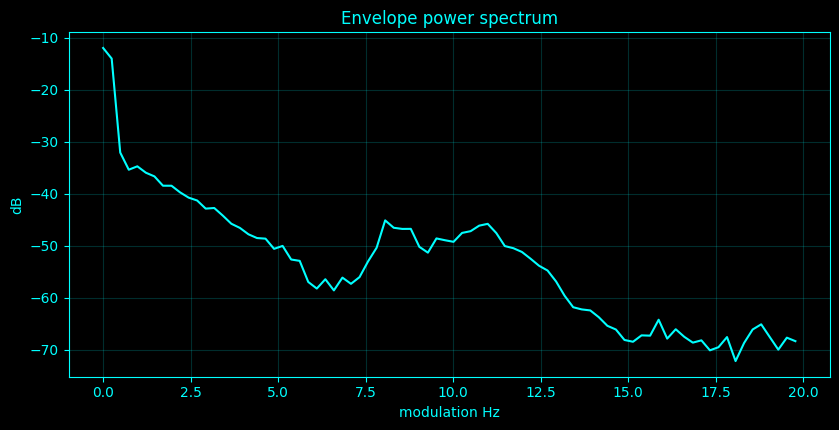

In [72]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_238():
    idx = 238
    name = 'Envelope power spectrum'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    __plot_spec = ('summary', 10 * np.log10(PE[:, 0] + EPS), name, fE, 'modulation Hz', 'dB')
    return ({'envelope_power_shape': PE.shape}, locals().get('__plot_spec', None))
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_238,_plot_spec=_compute_method_238()
print('Envelope power spectrum')
if isinstance(result_238,dict):
    for _k,_v in result_238.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_238)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_238)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Envelope power spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Envelope power spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Envelope power spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">239. Envelope autocorrelation spectrum</h3>
<p>By Wiener-Khinchin, the Fourier transform of the envelope autocovariance equals its power spectrum. This cell computes that autocorrelation-spectrum representation explicitly.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The Fourier transform represents a time-domain signal as a weighted sum of sinusoidal components. Each Fourier coefficient is complex: its magnitude describes the strength of a frequency component, while its angle describes phase relative to the chosen time origin. The discrete Fourier transform evaluates this representation only at a finite set of frequencies determined by the sampling rate and record length. It describes global frequency content over the analyzed window and does not by itself show when a frequency occurs.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [73]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_239():
    idx = 239
    name = 'Envelope autocorrelation spectrum'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    y = env[:, 0] - env[:, 0].mean()
    acf = signal.fftconvolve(y, y[::-1], mode='full')[len(y) - 1:] / np.arange(len(y), 0, -1)
    ps = np.real(np.fft.rfft(acf))
    ff = np.fft.rfftfreq(len(acf), 1 / _fs)
    return ({'autocorrelation_spectrum_peak_hz': float(ff[np.argmax(ps[1:]) + 1]) if len(ps) > 1 else 0}, locals().get('__plot_spec', None))
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_239,_plot_spec=_compute_method_239()
print('Envelope autocorrelation spectrum')
if isinstance(result_239,dict):
    for _k,_v in result_239.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_239)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_239)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Envelope autocorrelation spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Envelope autocorrelation spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Envelope autocorrelation spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Envelope autocorrelation spectrum
  autocorrelation_spectrum_peak_hz: 0.037402752842609216


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">240. Modulation spectrum</h3>
<p>The modulation/envelope spectrum is the PSD of a narrow-band analytic amplitude envelope. Its frequencies describe how rapidly oscillation amplitude itself fluctuates.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [74]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_240():
    idx = 240
    name = 'Modulation spectrum'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    return ({'modulation_spectrum_peak_hz': float(fE[1:][np.argmax(np.mean(PE[1:], axis=1))]) if len(fE) > 1 else 0}, locals().get('__plot_spec', None))
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_240,_plot_spec=_compute_method_240()
print('Modulation spectrum')
if isinstance(result_240,dict):
    for _k,_v in result_240.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_240)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_240)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Modulation spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Modulation spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Modulation spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Modulation spectrum
  modulation_spectrum_peak_hz: 0.244140625


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">241. Amplitude modulation frequency analysis</h3>
<p>Amplitude-modulation frequency is the dominant nonzero frequency of the envelope power spectrum.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Amplitude modulation frequency analysis
  amplitude_modulation_frequency_hz: array(12,), mean=0.264486


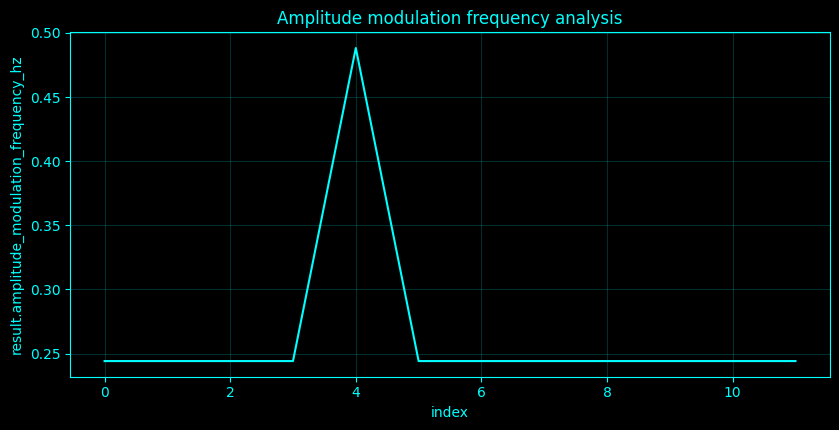

In [75]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_241():
    idx = 241
    name = 'Amplitude modulation frequency analysis'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    vals = []
    for j in range(C):
        k = np.argmax(PE[1:, j]) + 1 if len(fE) > 1 else 0
        vals.append(float(fE[k]))
    return ({'amplitude_modulation_frequency_hz': vals}, locals().get('__plot_spec', None))
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_241,_plot_spec=_compute_method_241()
print('Amplitude modulation frequency analysis')
if isinstance(result_241,dict):
    for _k,_v in result_241.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_241)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_241)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Amplitude modulation frequency analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Amplitude modulation frequency analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Amplitude modulation frequency analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">242. Cross-channel envelope coherence</h3>
<p>Cross-channel envelope coherence applies magnitude-squared coherence to narrow-band amplitude envelopes, measuring shared modulation frequencies.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [76]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_242():
    idx = 242
    name = 'Cross-channel envelope coherence'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    vals = []
    for j in range(1, C):
        ff, cc = signal.coherence(env[:, 0], env[:, j], fs=_fs, nperseg=nper)
        m = (ff >= 0.1) & (ff <= 10)
        vals.append(float(np.mean(cc[m])) if np.any(m) else np.nan)
    return ({'mean_envelope_coherence': float(np.nanmean(vals))}, locals().get('__plot_spec', None))
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_242,_plot_spec=_compute_method_242()
print('Cross-channel envelope coherence')
if isinstance(result_242,dict):
    for _k,_v in result_242.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_242)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_242)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-channel envelope coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-channel envelope coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-channel envelope coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-channel envelope coherence
  mean_envelope_coherence: 0.37485020503309713


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">243. Envelope phase synchrony</h3>
<p>Envelope phase synchrony takes the analytic phase of the demeaned amplitude envelopes and applies PLV to their modulation phases.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [77]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _plv(d):
    return float(np.abs(np.mean(np.exp(1j * d))))

# Method-specific calculation.
def _compute_method_243():
    idx = 243
    name = 'Envelope phase synchrony'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    ep = np.angle(signal.hilbert(env - env.mean(axis=0), axis=0))
    vals = [_plv(ep[:, 0] - ep[:, j]) for j in range(1, C)]
    return ({'mean_envelope_phase_synchrony': float(np.mean(vals))}, locals().get('__plot_spec', None))
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_243,_plot_spec=_compute_method_243()
print('Envelope phase synchrony')
if isinstance(result_243,dict):
    for _k,_v in result_243.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_243)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_243)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Envelope phase synchrony',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Envelope phase synchrony',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Envelope phase synchrony',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Envelope phase synchrony
  mean_envelope_phase_synchrony: 0.6965763931111736


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">244. Envelope burst coupling</h3>
<p>Envelope burst coupling is the correlation between binary high-envelope burst indicators from two bands.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [78]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_244():
    idx = 244
    name = 'Envelope burst coupling'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    a = np.abs(_analytic_band(BANDS['alpha']))
    b = np.abs(_analytic_band(BANDS['beta']))
    ia = a > np.quantile(a, 0.75, axis=0)
    ib = b > np.quantile(b, 0.75, axis=0)
    return ({'alpha_beta_burst_indicator_correlation': float(np.corrcoef(ia[:, 0].astype(float), ib[:, 0].astype(float))[0, 1])}, locals().get('__plot_spec', None))
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_244,_plot_spec=_compute_method_244()
print('Envelope burst coupling')
if isinstance(result_244,dict):
    for _k,_v in result_244.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_244)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_244)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Envelope burst coupling',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Envelope burst coupling',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Envelope burst coupling',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Envelope burst coupling
  alpha_beta_burst_indicator_correlation: 0.16736485138639542


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">245. Envelope graph spectra</h3>
<p>Envelope graph spectra are Laplacian eigenvalues of a network weighted by cross-channel envelope coherence.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Envelope graph spectra
  envelope_graph_laplacian_eigenvalues: array(12,), mean=3.32702


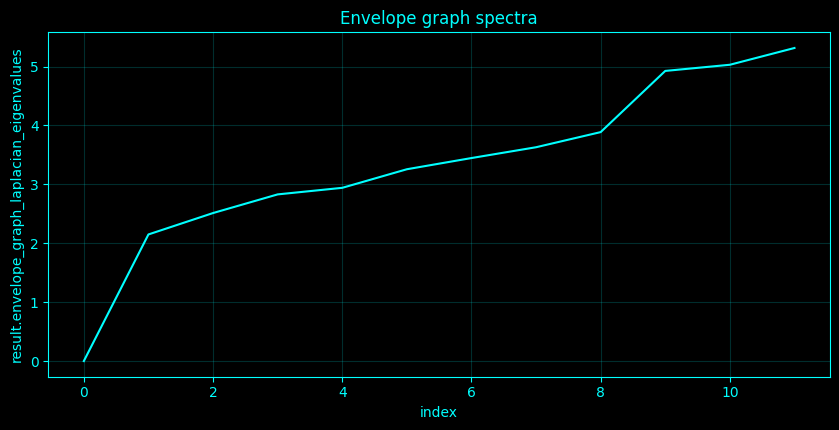

In [79]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_245():
    idx = 245
    name = 'Envelope graph spectra'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    M = np.eye(C)
    for i in range(C):
        for j in range(i + 1, C):
            ff, cc = signal.coherence(env[:, i], env[:, j], fs=_fs, nperseg=nper)
            m = (ff >= 0.1) & (ff <= 10)
            M[i, j] = M[j, i] = float(np.mean(cc[m])) if np.any(m) else 0
    np.fill_diagonal(M, 0)
    L = np.diag(M.sum(1)) - M
    lam = np.linalg.eigvalsh(L)
    return ({'envelope_graph_laplacian_eigenvalues': lam.tolist()}, locals().get('__plot_spec', None))
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_245,_plot_spec=_compute_method_245()
print('Envelope graph spectra')
if isinstance(result_245,dict):
    for _k,_v in result_245.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_245)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_245)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Envelope graph spectra',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Envelope graph spectra',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Envelope graph spectra',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">246. Envelope spectral entropy</h3>
<p>Envelope spectral entropy normalizes envelope PSD over modulation frequency and computes \(-\sum p_f\log p_f/\log F\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Spectral entropy treats the normalized power spectrum as a probability distribution over frequency bins and applies Shannon entropy to that distribution. If power is concentrated in only a few frequencies, the distribution is uneven and entropy is low. If power is spread broadly across many frequencies, entropy is higher. The result therefore describes spectral dispersion, not temporal unpredictability in exactly the same sense as Sample Entropy or permutation entropy.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Envelope spectral entropy
  envelope_spectral_entropy: array(12,), mean=0.326365


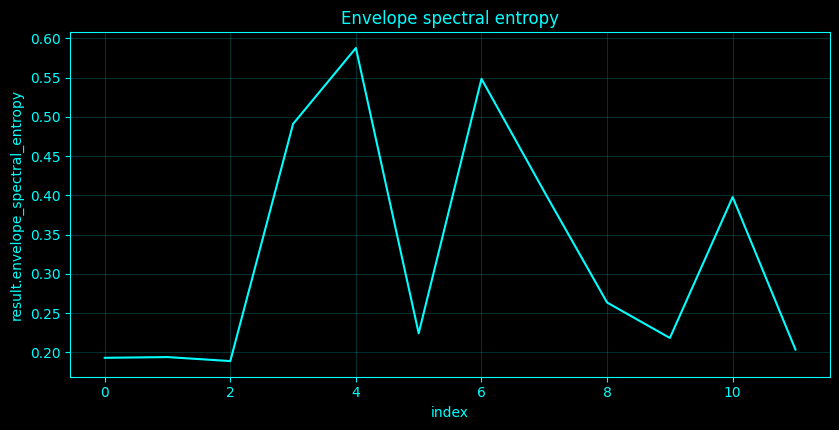

In [80]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_246():
    idx = 246
    name = 'Envelope spectral entropy'
    __plot_spec = None
    A = _analytic_band(BANDS['alpha'])
    env = np.abs(A)
    nper = min(_SPEED['nperseg'], N)
    fE, PE = signal.welch(env, fs=_fs, axis=0, nperseg=nper, noverlap=nper // 2)
    keep = fE <= min(20, 0.49 * _fs)
    fE = fE[keep]
    PE = PE[keep]
    q = PE / (np.sum(PE, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(max(len(fE), 2))
    return ({'envelope_spectral_entropy': H.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_246,_plot_spec=_compute_method_246()
print('Envelope spectral entropy')
if isinstance(result_246,dict):
    for _k,_v in result_246.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_246)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_246)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Envelope spectral entropy',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Envelope spectral entropy',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Envelope spectral entropy',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">247. Spectral Granger causality</h3>
<p>For a stable multivariate autoregressive process \(x_t=\sum_{k=1}^p A_kx_{t-k}+\varepsilon_t\), the transfer matrix is \(H(f)=A(f)^{-1}\), where \(A(f)=I-\sum_kA_ke^{-i2\pi fk/f_s}\). Frequency-domain Granger influence is the log ratio between the target spectrum and the spectrum remaining after the source innovation contribution is removed, \(F_{j\to i}(f)=\log[S_{ii}(f)/\tilde S_{ii}^{(j)}(f)]\). This cell fits one MVAR model to the same EEG segment and evaluates that directed spectrum.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Spectral Granger causality
  peak_hz: 2.3968253968253967
  mean_gc: 0.06630750524560483


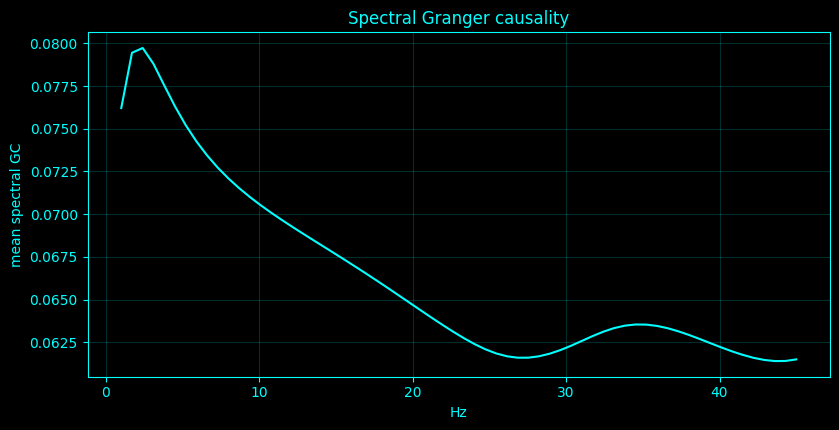

In [81]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_247():
    idx = 247
    name = 'Spectral Granger causality'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    y = np.mean(gc, axis=(1, 2))
    __plot_spec = ('summary', y, name, f, 'Hz', 'mean spectral GC')
    return ({'peak_hz': float(f[np.argmax(y)]), 'mean_gc': float(np.mean(y))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_247,_plot_spec=_compute_method_247()
print('Spectral Granger causality')
if isinstance(result_247,dict):
    for _k,_v in result_247.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_247)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_247)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral Granger causality',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral Granger causality',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral Granger causality',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">248. Frequency-domain Granger causality</h3>
<p>For a stable multivariate autoregressive process \(x_t=\sum_{k=1}^p A_kx_{t-k}+\varepsilon_t\), the transfer matrix is \(H(f)=A(f)^{-1}\), where \(A(f)=I-\sum_kA_ke^{-i2\pi fk/f_s}\). Frequency-domain Granger influence is the log ratio between the target spectrum and the spectrum remaining after the source innovation contribution is removed, \(F_{j\to i}(f)=\log[S_{ii}(f)/\tilde S_{ii}^{(j)}(f)]\). This cell fits one MVAR model to the same EEG segment and evaluates that directed spectrum.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Frequency-domain Granger causality
  strongest: Fp1→Fpz
  forward: 0.7268447724257423
  reverse: 0.07203058240277287


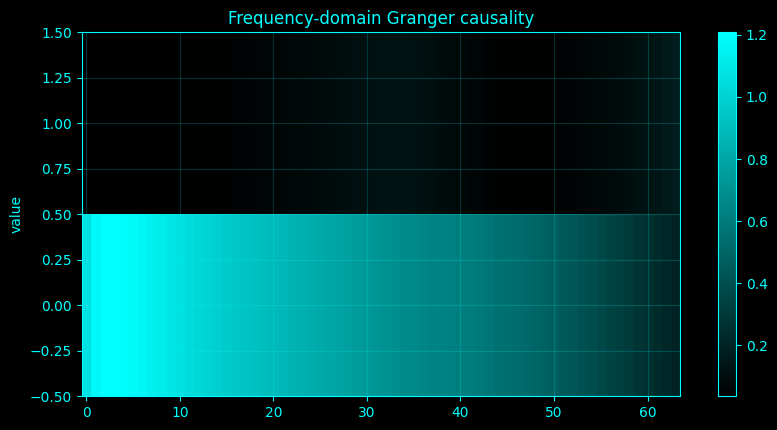

In [82]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_248():
    idx = 248
    name = 'Frequency-domain Granger causality'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    score = np.mean(gc, axis=0)
    np.fill_diagonal(score, 0)
    i, j = np.unravel_index(np.argmax(score), score.shape)
    __plot_spec = ('summary', np.vstack([gc[:, i, j], gc[:, j, i]]), name, None, '', 'value')
    return ({'strongest': f'{CH_NAMES[j]}→{CH_NAMES[i]}', 'forward': float(score[i, j]), 'reverse': float(score[j, i])}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_248,_plot_spec=_compute_method_248()
print('Frequency-domain Granger causality')
if isinstance(result_248,dict):
    for _k,_v in result_248.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_248)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_248)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-domain Granger causality',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-domain Granger causality',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-domain Granger causality',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">249. Conditional spectral Granger causality</h3>
<p>Conditional spectral Granger causality asks whether source \(j\) improves prediction of target \(i\) after all other modeled channels are already included. In the fitted multivariate system it is evaluated from the full transfer matrix and whitened innovations; the directed contribution is therefore conditional on the remaining variables in the VAR.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [83]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_249():
    idx = 249
    name = 'Conditional spectral Granger causality'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    score = np.mean(gc[:, bm], axis=1) if False else np.mean(gc[bm], axis=0)
    np.fill_diagonal(score, 0)
    i, j = np.unravel_index(np.argmax(score), score.shape)
    __plot_spec = ('summary', gc[:, i, j], name, f, 'Hz', 'conditional GC')
    return ({'edge': f'{CH_NAMES[j]}→{CH_NAMES[i]}', 'alpha_gc': float(score[i, j])}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_249,_plot_spec=_compute_method_249()
print('Conditional spectral Granger causality')
if isinstance(result_249,dict):
    for _k,_v in result_249.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_249)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_249)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Conditional spectral Granger causality',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Conditional spectral Granger causality',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Conditional spectral Granger causality',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Conditional spectral Granger causality
  edge: Fp1→Fpz
  alpha_gc: 0.9888439469953713


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">250. Pairwise spectral Granger networks</h3>
<p>A spectral Granger network uses channels as nodes and frequency-averaged Granger influence as directed edge weight, \(w_{j\to i}=|B|^{-1}\int_B F_{j\to i}(f)\,df\) (implemented by the sampled-frequency mean). Pairwise summaries and the multivariate network use the same fitted VAR but differ in how the edge matrix is summarized.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [84]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_250():
    idx = 250
    name = 'Pairwise spectral Granger networks'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = np.mean(gc[bm], axis=0) if idx == 250 else np.mean(gc, axis=0)
    np.fill_diagonal(M, 0)
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'edges_above_q75': int(np.sum(M > np.quantile(M[M > 0], 0.75))) if np.any(M > 0) else 0}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_250,_plot_spec=_compute_method_250()
print('Pairwise spectral Granger networks')
if isinstance(result_250,dict):
    for _k,_v in result_250.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_250)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_250)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Pairwise spectral Granger networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Pairwise spectral Granger networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Pairwise spectral Granger networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Pairwise spectral Granger networks
  edges_above_q75: 33


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">251. Multivariate spectral Granger networks</h3>
<p>A spectral Granger network uses channels as nodes and frequency-averaged Granger influence as directed edge weight, \(w_{j\to i}=|B|^{-1}\int_B F_{j\to i}(f)\,df\) (implemented by the sampled-frequency mean). Pairwise summaries and the multivariate network use the same fitted VAR but differ in how the edge matrix is summarized.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [85]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_251():
    idx = 251
    name = 'Multivariate spectral Granger networks'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = np.mean(gc[bm], axis=0) if idx == 250 else np.mean(gc, axis=0)
    np.fill_diagonal(M, 0)
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'edges_above_q75': int(np.sum(M > np.quantile(M[M > 0], 0.75))) if np.any(M > 0) else 0}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_251,_plot_spec=_compute_method_251()
print('Multivariate spectral Granger networks')
if isinstance(result_251,dict):
    for _k,_v in result_251.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_251)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_251)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multivariate spectral Granger networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multivariate spectral Granger networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multivariate spectral Granger networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Multivariate spectral Granger networks
  edges_above_q75: 33


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">252. Spectral causality asymmetry</h3>
<p>Directed asymmetry is the antisymmetric component of a directed connectivity matrix, \(A_{ij}=w_{j\to i}-w_{i\to j}\). Positive values indicate stronger flow from \(j\) to \(i\) than in the reverse direction.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [86]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_252():
    idx = 252
    name = 'Spectral causality asymmetry'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = np.mean(gc[bm], axis=0)
    A = M - M.T
    __plot_spec = ('summary', A, name, None, '', 'value')
    return ({'max_abs_asymmetry': float(np.max(np.abs(A)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_252,_plot_spec=_compute_method_252()
print('Spectral causality asymmetry')
if isinstance(result_252,dict):
    for _k,_v in result_252.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_252)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_252)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral causality asymmetry',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral causality asymmetry',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral causality asymmetry',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral causality asymmetry
  max_abs_asymmetry: 0.942360692711569


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">253. Spectral causality source-sink maps</h3>
<p>For node \(j\), spectral source strength is \(s_j^{out}=\sum_iw_{j\to i}\), sink strength is \(s_j^{in}=\sum_iw_{i\to j}\), and net source-sink score is \(s_j^{out}-s_j^{in}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [87]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_253():
    idx = 253
    name = 'Spectral causality source-sink maps'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = np.mean(gc[bm], axis=0)
    out = np.sum(M, axis=0)
    inn = np.sum(M, axis=1)
    net = out - inn
    __plot_spec = ('summary', net, name, np.arange(C), 'channel', 'out-in')
    return ({'top_source': CH_NAMES[int(np.argmax(net))], 'top_sink': CH_NAMES[int(np.argmin(net))]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_253,_plot_spec=_compute_method_253()
print('Spectral causality source-sink maps')
if isinstance(result_253,dict):
    for _k,_v in result_253.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_253)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_253)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral causality source-sink maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral causality source-sink maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral causality source-sink maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral causality source-sink maps
  top_source: Fp1
  top_sink: Fp2


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">254. Spectral Granger surrogate testing</h3>
<p>Surrogate testing compares an observed Granger edge with a null distribution generated after phase randomization. The Monte-Carlo p-value is \((1+\#\{T_s\ge T_{obs}\})/(1+N_s)\), which avoids zero p-values for a finite surrogate ensemble.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral Granger surrogate testing
  edge: Fp1→Fpz
  observed: 0.9888439469953713
  surrogate_p: 0.1111111111111111


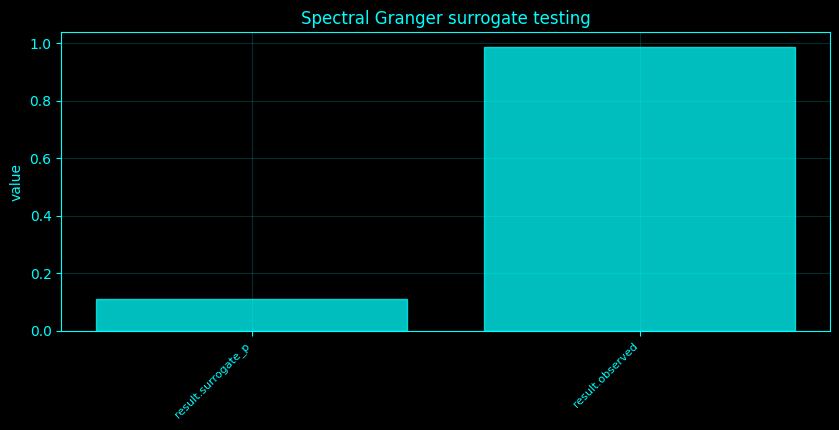

In [88]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

def _phase_randomize(x, rng):
    xf = np.fft.rfft(x, axis=0)
    ph = rng.uniform(0, 2 * np.pi, size=xf.shape)
    ph[0] = 0
    if x.shape[0] % 2 == 0:
        ph[-1] = 0
    return np.fft.irfft(np.abs(xf) * np.exp(1j * ph), n=x.shape[0], axis=0)

# Method-specific calculation.
def _compute_method_254():
    idx = 254
    name = 'Spectral Granger surrogate testing'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = np.mean(gc[bm], axis=0)
    np.fill_diagonal(M, 0)
    i, j = np.unravel_index(np.argmax(M), M.shape)
    obs = float(M[i, j])
    vals = []
    for _ in range(_SPEED['n_sur']):
        xx = _phase_randomize(X[:, [i, j]], _rng)
        p = min(_SPEED['var_order'], 8)
        Y = xx[p:]
        Z = np.hstack([xx[p - k:N - k] for k in range(1, p + 1)])
        B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(2 * p), Z.T @ Y)
        E = Y - Z @ B
        vals.append(float(np.log((np.var(E[:, 0]) + EPS) / (np.var(E[:, 0] - Z[:, 1::2] @ B[1::2, 0]) + EPS))) if p > 0 else 0)
    vals = np.maximum(vals, 0)
    pval = (1 + np.sum(np.asarray(vals) >= obs)) / (1 + len(vals))
    return ({'edge': f'{CH_NAMES[j]}→{CH_NAMES[i]}', 'observed': obs, 'surrogate_p': float(pval)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_254,_plot_spec=_compute_method_254()
print('Spectral Granger surrogate testing')
if isinstance(result_254,dict):
    for _k,_v in result_254.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_254)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_254)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral Granger surrogate testing',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral Granger surrogate testing',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral Granger surrogate testing',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">255. Directed transfer function</h3>
<p>The directed transfer function normalizes each target row of the transfer matrix, \(\mathrm{DTF}_{ij}(f)=|H_{ij}(f)|/\sqrt{\sum_k|H_{ik}(f)|^2}\). It quantifies how strongly source \(j\) contributes to target \(i\) through the full VAR transfer function.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [89]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_255():
    idx = 255
    name = 'Directed transfer function'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = D['dtf']
    score = np.mean(M[bm], axis=0)
    np.fill_diagonal(score, 0)
    i, j = np.unravel_index(np.argmax(score), score.shape)
    __plot_spec = ('summary', M[:, i, j], name, f, 'Hz', 'DTF')
    return ({'edge': f'{CH_NAMES[j]}→{CH_NAMES[i]}', 'alpha_mean': float(score[i, j])}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_255,_plot_spec=_compute_method_255()
print('Directed transfer function')
if isinstance(result_255,dict):
    for _k,_v in result_255.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_255)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_255)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Directed transfer function',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Directed transfer function',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Directed transfer function',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Directed transfer function
  edge: FC1→F3
  alpha_mean: 0.6475506826866955


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">256. Direct directed transfer function</h3>
<p>Direct DTF suppresses indirect pathways by multiplying DTF by partial coherence, \(\mathrm{dDTF}_{ij}(f)=\mathrm{DTF}_{ij}(f)\,|\mathrm{PCoh}_{ij}(f)|\), where partial coherence is computed from the inverse spectral matrix.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [90]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_256():
    idx = 256
    name = 'Direct directed transfer function'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = D['ddtf']
    score = np.mean(M[bm], axis=0)
    np.fill_diagonal(score, 0)
    i, j = np.unravel_index(np.argmax(score), score.shape)
    __plot_spec = ('summary', M[:, i, j], name, f, 'Hz', 'dDTF')
    return ({'edge': f'{CH_NAMES[j]}→{CH_NAMES[i]}', 'alpha_mean': float(score[i, j])}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_256,_plot_spec=_compute_method_256()
print('Direct directed transfer function')
if isinstance(result_256,dict):
    for _k,_v in result_256.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_256)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_256)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Direct directed transfer function',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Direct directed transfer function',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Direct directed transfer function',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Direct directed transfer function
  edge: FC6→F8
  alpha_mean: 0.3749086507035347


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">257. Partial directed coherence</h3>
<p>Partial directed coherence uses the Fourier-domain AR matrix rather than the transfer matrix. For sender \(j\), \(\mathrm{PDC}_{ij}(f)=|A_{ij}(f)|/\sqrt{\sum_k|A_{kj}(f)|^2}\); the column normalization emphasizes direct outgoing coefficients.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [91]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_257():
    idx = 257
    name = 'Partial directed coherence'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = D['pdc']
    score = np.mean(M[bm], axis=0)
    np.fill_diagonal(score, 0)
    i, j = np.unravel_index(np.argmax(score), score.shape)
    __plot_spec = ('summary', M[:, i, j], name, f, 'Hz', 'PDC')
    return ({'edge': f'{CH_NAMES[j]}→{CH_NAMES[i]}', 'alpha_mean': float(score[i, j])}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_257,_plot_spec=_compute_method_257()
print('Partial directed coherence')
if isinstance(result_257,dict):
    for _k,_v in result_257.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_257)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_257)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Partial directed coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Partial directed coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Partial directed coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Partial directed coherence
  edge: FC1→F3
  alpha_mean: 0.5464343659046756


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">258. Generalized partial directed coherence</h3>
<p>Generalized PDC makes PDC scale-aware by weighting each receiving equation with its innovation variance, \(\mathrm{gPDC}_{ij}=|A_{ij}|/\sigma_i\,[\sum_k|A_{kj}|^2/\sigma_k^2]^{-1/2}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [92]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_258():
    idx = 258
    name = 'Generalized partial directed coherence'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = D['gpdc']
    score = np.mean(M[bm], axis=0)
    np.fill_diagonal(score, 0)
    i, j = np.unravel_index(np.argmax(score), score.shape)
    __plot_spec = ('summary', M[:, i, j], name, f, 'Hz', 'gPDC')
    return ({'edge': f'{CH_NAMES[j]}→{CH_NAMES[i]}', 'alpha_mean': float(score[i, j])}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_258,_plot_spec=_compute_method_258()
print('Generalized partial directed coherence')
if isinstance(result_258,dict):
    for _k,_v in result_258.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_258)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_258)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Generalized partial directed coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Generalized partial directed coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Generalized partial directed coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Generalized partial directed coherence
  edge: Fpz→Fp1
  alpha_mean: 0.5502539576057963


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">259. Renormalized PDC</h3>
<p>Renormalized PDC treats the real and imaginary parts of \(A_{ij}(f)\) as a two-vector \(Z_{ij}(f)=[\Re A_{ij},\Im A_{ij}]^\top\) and forms the Wald statistic \(\lambda_{ij}(f)=Z_{ij}^\top V_{ij}^{-1}Z_{ij}\), where \(V_{ij}\) is the estimated coefficient covariance.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [93]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_259():
    idx = 259
    name = 'Renormalized PDC'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = D['rpdc']
    score = np.mean(M[bm], axis=0)
    np.fill_diagonal(score, 0)
    i, j = np.unravel_index(np.argmax(score), score.shape)
    __plot_spec = ('summary', M[:, i, j], name, f, 'Hz', 'Wald λ')
    return ({'edge': f'{CH_NAMES[j]}→{CH_NAMES[i]}', 'mean_lambda': float(score[i, j])}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_259,_plot_spec=_compute_method_259()
print('Renormalized PDC')
if isinstance(result_259,dict):
    for _k,_v in result_259.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_259)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_259)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Renormalized PDC',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Renormalized PDC',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Renormalized PDC',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Renormalized PDC
  edge: FC1→Fpz
  mean_lambda: 1125.827287250467


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">260. Frequency-domain causal flow</h3>
<p>Frequency-domain causal flow is the total directed Granger mass at each frequency, \(\Phi(f)=\sum_{i\ne j}F_{j\to i}(f)\). It is a network summary, not a new pairwise causal estimator.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [94]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_260():
    idx = 260
    name = 'Frequency-domain causal flow'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    flow = np.sum(gc, axis=(1, 2))
    __plot_spec = ('summary', flow, name, f, 'Hz', 'total directed GC')
    return ({'peak_hz': float(f[np.argmax(flow)])}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_260,_plot_spec=_compute_method_260()
print('Frequency-domain causal flow')
if isinstance(result_260,dict):
    for _k,_v in result_260.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_260)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_260)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-domain causal flow',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-domain causal flow',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-domain causal flow',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Frequency-domain causal flow
  peak_hz: 2.3968253968253967


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">261. Frequency-specific net outflow</h3>
<p>Frequency-specific net outflow from source \(j\) is \(O_j(f)=\sum_{i\ne j}F_{j\to i}(f)\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [95]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_261():
    idx = 261
    name = 'Frequency-specific net outflow'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    out = np.sum(gc, axis=1)
    __plot_spec = ('summary', out.T, name, None, '', 'value')
    return ({'max_channel': CH_NAMES[int(np.argmax(np.mean(out, axis=0)))]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_261,_plot_spec=_compute_method_261()
print('Frequency-specific net outflow')
if isinstance(result_261,dict):
    for _k,_v in result_261.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_261)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_261)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-specific net outflow',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-specific net outflow',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-specific net outflow',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Frequency-specific net outflow
  max_channel: Fp1


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">262. Frequency-specific net inflow</h3>
<p>Frequency-specific net inflow to target \(i\) is \(I_i(f)=\sum_{j\ne i}F_{j\to i}(f)\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [96]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_262():
    idx = 262
    name = 'Frequency-specific net inflow'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    inn = np.sum(gc, axis=2)
    __plot_spec = ('summary', inn.T, name, None, '', 'value')
    return ({'max_channel': CH_NAMES[int(np.argmax(np.mean(inn, axis=0)))]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_262,_plot_spec=_compute_method_262()
print('Frequency-specific net inflow')
if isinstance(result_262,dict):
    for _k,_v in result_262.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_262)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_262)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-specific net inflow',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-specific net inflow',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-specific net inflow',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Frequency-specific net inflow
  max_channel: Fpz


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">263. Frequency-resolved causal hubness</h3>
<p>Causal hubness is summarized as outflow minus inflow, \(H_j(f)=O_j(f)-I_j(f)\). Positive values identify source-like nodes and negative values identify sink-like nodes.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [97]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_263():
    idx = 263
    name = 'Frequency-resolved causal hubness'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    out = np.sum(gc, axis=1)
    inn = np.sum(gc, axis=2)
    hub = out - inn
    __plot_spec = ('summary', hub.T, name, None, '', 'value')
    return ({'strongest_source': CH_NAMES[int(np.argmax(np.mean(hub, axis=0)))]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_263,_plot_spec=_compute_method_263()
print('Frequency-resolved causal hubness')
if isinstance(result_263,dict):
    for _k,_v in result_263.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_263)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_263)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-resolved causal hubness',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-resolved causal hubness',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-resolved causal hubness',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Frequency-resolved causal hubness
  strongest_source: Fp1


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">264. Directed spectral graph analysis</h3>
<p>Directed spectral graph analysis thresholds a band-averaged directed connectivity matrix to form a weighted digraph. Graph centrality is then computed on those directed weights; the graph step does not change the underlying DTF/Granger estimator.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Directed spectral graph analysis
  nodes: 12
  edges: 33
  top_pagerank: F8


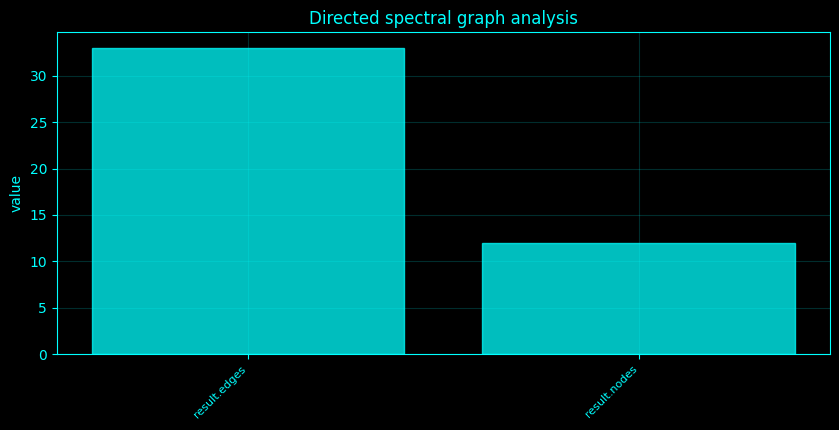

In [98]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_264():
    idx = 264
    name = 'Directed spectral graph analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    D = _directed_measures()
    f = D['f']
    gc = D['gc']
    band = (8, 13)
    bm = (f >= band[0]) & (f < band[1])
    M = np.mean(D['dtf'][bm], axis=0)
    np.fill_diagonal(M, 0)
    G = nx.DiGraph()
    for j in range(C):
        for i in range(C):
            if i != j and M[i, j] >= np.quantile(M[M > 0], 0.75):
                G.add_edge(j, i, weight=float(M[i, j]))
    pr = nx.pagerank(G, weight='weight') if G.number_of_edges() else {i: 0 for i in range(C)}
    return ({'nodes': G.number_of_nodes(), 'edges': G.number_of_edges(), 'top_pagerank': CH_NAMES[max(pr, key=pr.get)] if pr else None}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_264,_plot_spec=_compute_method_264()
print('Directed spectral graph analysis')
if isinstance(result_264,dict):
    for _k,_v in result_264.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_264)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_264)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Directed spectral graph analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Directed spectral graph analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Directed spectral graph analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">265. Cross-channel spectral mutual information</h3>
<p>Mutual information measures statistical dependence: \(I(X;Y)=\sum_{x,y}p(x,y)\log[p(x,y)/(p(x)p(y))]\). Here the variables are windowed log spectral powers, quantized only for the finite-sample estimator.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [99]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _hist_mi(x, y, bins=8):
    h, _, _ = np.histogram2d(np.asarray(x), np.asarray(y), bins=bins)
    p = h / (h.sum() + EPS)
    px = p.sum(1, keepdims=True)
    py = p.sum(0, keepdims=True)
    ratio = p / (px @ py + EPS)
    m = p > 0
    return float(np.sum(p[m] * np.log(ratio[m] + EPS)))

def _digitize_quantile(x, bins=5):
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) <= 2:
        return np.zeros(len(x), int)
    return np.clip(np.digitize(x, q[1:-1]), 0, len(q) - 2)

def _entropy_disc(*arrs):
    A = np.column_stack(arrs)
    _, cnt = np.unique(A, axis=0, return_counts=True)
    p = cnt / cnt.sum()
    return float(-np.sum(p * np.log(p + EPS)))

def _info_features():
    if 'info' in SPEC_CACHE:
        return SPEC_CACHE['info']
    t, W = _window_bandpower()
    Z = np.log(W + EPS)
    SPEC_CACHE['info'] = (t, Z)
    return SPEC_CACHE['info']

# Method-specific calculation.
def _compute_method_265():
    idx = 265
    name = 'Cross-channel spectral mutual information'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, Z = _info_features()
    A = np.mean(Z, axis=2)
    M = np.eye(C)
    for i in range(C):
        for j in range(i + 1, C):
            M[i, j] = M[j, i] = _hist_mi(A[:, i], A[:, j], bins=6)
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'mean_offdiag_mi': float(np.mean(M[np.triu_indices(C, 1)]))}, locals().get('__plot_spec', None))
    q = [_digitize_quantile(A[:, k], 4) for k in range(min(C, 5))]
    H = lambda inds: _entropy_disc(*[q[k] for k in inds])
    n = len(q)
    Hall = H(list(range(n)))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_265,_plot_spec=_compute_method_265()
print('Cross-channel spectral mutual information')
if isinstance(result_265,dict):
    for _k,_v in result_265.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_265)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_265)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-channel spectral mutual information',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-channel spectral mutual information',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-channel spectral mutual information',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-channel spectral mutual information
  mean_offdiag_mi: 0.4232572494584808


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">266. Frequency-resolved mutual information</h3>
<p>Frequency-resolved mutual information applies the same \(I(X;Y)\) definition separately to each EEG band, using window-to-window bandpower fluctuations as samples.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Frequency-resolved mutual information
  delta: 0.9364452434649025
  theta: 0.6498644193970063
  alpha: 1.070168276561646
  beta: 0.4212152850946526
  gamma: 0.512843803713235


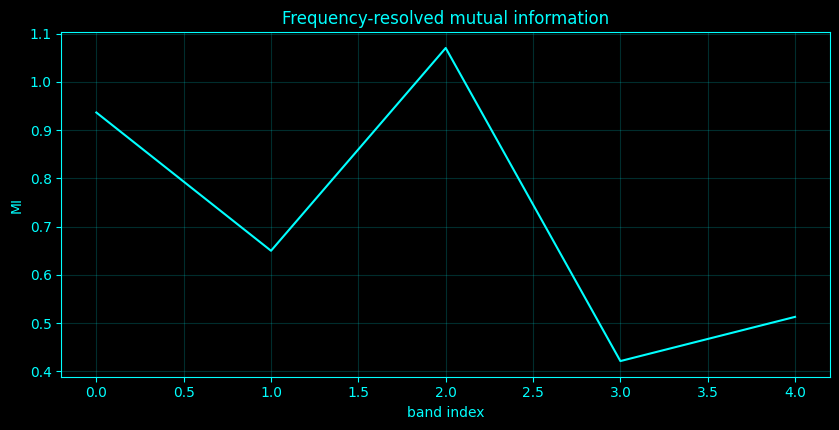

In [100]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _hist_mi(x, y, bins=8):
    h, _, _ = np.histogram2d(np.asarray(x), np.asarray(y), bins=bins)
    p = h / (h.sum() + EPS)
    px = p.sum(1, keepdims=True)
    py = p.sum(0, keepdims=True)
    ratio = p / (px @ py + EPS)
    m = p > 0
    return float(np.sum(p[m] * np.log(ratio[m] + EPS)))

def _digitize_quantile(x, bins=5):
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) <= 2:
        return np.zeros(len(x), int)
    return np.clip(np.digitize(x, q[1:-1]), 0, len(q) - 2)

def _entropy_disc(*arrs):
    A = np.column_stack(arrs)
    _, cnt = np.unique(A, axis=0, return_counts=True)
    p = cnt / cnt.sum()
    return float(-np.sum(p * np.log(p + EPS)))

def _info_features():
    if 'info' in SPEC_CACHE:
        return SPEC_CACHE['info']
    t, W = _window_bandpower()
    Z = np.log(W + EPS)
    SPEC_CACHE['info'] = (t, Z)
    return SPEC_CACHE['info']

# Method-specific calculation.
def _compute_method_266():
    idx = 266
    name = 'Frequency-resolved mutual information'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, Z = _info_features()
    A = np.mean(Z, axis=2)
    i, j = (0, min(1, C - 1))
    vals = [_hist_mi(Z[:, i, b], Z[:, j, b], bins=6) for b in range(Z.shape[2])]
    __plot_spec = ('summary', vals, name, np.arange(len(vals)), 'band index', 'MI')
    return (dict(zip(BANDS.keys(), map(float, vals))), locals().get('__plot_spec', None))
    q = [_digitize_quantile(A[:, k], 4) for k in range(min(C, 5))]
    H = lambda inds: _entropy_disc(*[q[k] for k in inds])
    n = len(q)
    Hall = H(list(range(n)))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_266,_plot_spec=_compute_method_266()
print('Frequency-resolved mutual information')
if isinstance(result_266,dict):
    for _k,_v in result_266.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_266)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_266)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-resolved mutual information',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-resolved mutual information',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-resolved mutual information',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">267. Spectral transfer entropy</h3>
<p>Transfer entropy is conditional mutual information from source past to target future, \(TE_{X\to Y}=I(Y_t;X_{t-1}\mid Y_{t-1})\). The implementation uses quantile-discretized windowed spectral power; the band-specific variant repeats the calculation band by band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [101]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _digitize_quantile(x, bins=5):
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) <= 2:
        return np.zeros(len(x), int)
    return np.clip(np.digitize(x, q[1:-1]), 0, len(q) - 2)

def _entropy_disc(*arrs):
    A = np.column_stack(arrs)
    _, cnt = np.unique(A, axis=0, return_counts=True)
    p = cnt / cnt.sum()
    return float(-np.sum(p * np.log(p + EPS)))

def _te_discrete(x, y, bins=4):
    xd = _digitize_quantile(x, bins)
    yd = _digitize_quantile(y, bins)
    yt = yd[1:]
    yp = yd[:-1]
    xp = xd[:-1]
    return _entropy_disc(yt, yp) + _entropy_disc(yp, xp) - _entropy_disc(yp) - _entropy_disc(yt, yp, xp)

def _info_features():
    if 'info' in SPEC_CACHE:
        return SPEC_CACHE['info']
    t, W = _window_bandpower()
    Z = np.log(W + EPS)
    SPEC_CACHE['info'] = (t, Z)
    return SPEC_CACHE['info']

# Method-specific calculation.
def _compute_method_267():
    idx = 267
    name = 'Spectral transfer entropy'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, Z = _info_features()
    A = np.mean(Z, axis=2)
    M = np.zeros((C, C))
    alpha = list(BANDS).index('alpha')
    for i in range(C):
        for j in range(C):
            if i != j:
                M[i, j] = max(0, _te_discrete(Z[:, j, alpha], Z[:, i, alpha]))
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'strongest_te': float(np.max(M))}, locals().get('__plot_spec', None))
    q = [_digitize_quantile(A[:, k], 4) for k in range(min(C, 5))]
    H = lambda inds: _entropy_disc(*[q[k] for k in inds])
    n = len(q)
    Hall = H(list(range(n)))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_267,_plot_spec=_compute_method_267()
print('Spectral transfer entropy')
if isinstance(result_267,dict):
    for _k,_v in result_267.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_267)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_267)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral transfer entropy',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral transfer entropy',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral transfer entropy',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral transfer entropy
  strongest_te: 0.6558343139173988


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">268. Frequency-band transfer entropy</h3>
<p>Transfer entropy is conditional mutual information from source past to target future, \(TE_{X\to Y}=I(Y_t;X_{t-1}\mid Y_{t-1})\). The implementation uses quantile-discretized windowed spectral power; the band-specific variant repeats the calculation band by band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Frequency-band transfer entropy
  delta: 0.3027425075092949
  theta: 0.14279288736689066
  alpha: 0.21730313633164133
  beta: 0.34470962883998446
  gamma: 0.3629275038084989


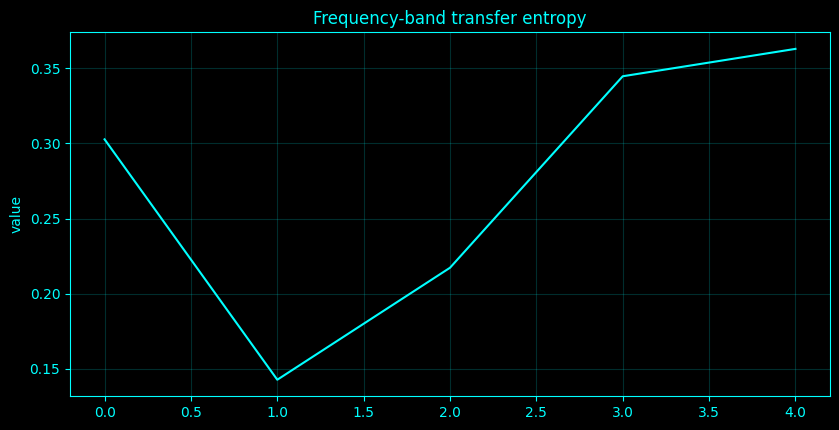

In [102]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _digitize_quantile(x, bins=5):
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) <= 2:
        return np.zeros(len(x), int)
    return np.clip(np.digitize(x, q[1:-1]), 0, len(q) - 2)

def _entropy_disc(*arrs):
    A = np.column_stack(arrs)
    _, cnt = np.unique(A, axis=0, return_counts=True)
    p = cnt / cnt.sum()
    return float(-np.sum(p * np.log(p + EPS)))

def _te_discrete(x, y, bins=4):
    xd = _digitize_quantile(x, bins)
    yd = _digitize_quantile(y, bins)
    yt = yd[1:]
    yp = yd[:-1]
    xp = xd[:-1]
    return _entropy_disc(yt, yp) + _entropy_disc(yp, xp) - _entropy_disc(yp) - _entropy_disc(yt, yp, xp)

def _info_features():
    if 'info' in SPEC_CACHE:
        return SPEC_CACHE['info']
    t, W = _window_bandpower()
    Z = np.log(W + EPS)
    SPEC_CACHE['info'] = (t, Z)
    return SPEC_CACHE['info']

# Method-specific calculation.
def _compute_method_268():
    idx = 268
    name = 'Frequency-band transfer entropy'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, Z = _info_features()
    A = np.mean(Z, axis=2)
    i, j = (0, min(1, C - 1))
    vals = [max(0, _te_discrete(Z[:, i, b], Z[:, j, b])) for b in range(Z.shape[2])]
    __plot_spec = ('summary', vals, name, None, '', 'value')
    return (dict(zip(BANDS.keys(), map(float, vals))), locals().get('__plot_spec', None))
    q = [_digitize_quantile(A[:, k], 4) for k in range(min(C, 5))]
    H = lambda inds: _entropy_disc(*[q[k] for k in inds])
    n = len(q)
    Hall = H(list(range(n)))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_268,_plot_spec=_compute_method_268()
print('Frequency-band transfer entropy')
if isinstance(result_268,dict):
    for _k,_v in result_268.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_268)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_268)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-band transfer entropy',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-band transfer entropy',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-band transfer entropy',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">269. Spectral conditional mutual information</h3>
<p>Conditional mutual information removes dependence explained by a conditioning variable: \(I(X;Y\mid Z)=H(X,Z)+H(Y,Z)-H(Z)-H(X,Y,Z)\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [103]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _digitize_quantile(x, bins=5):
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) <= 2:
        return np.zeros(len(x), int)
    return np.clip(np.digitize(x, q[1:-1]), 0, len(q) - 2)

def _entropy_disc(*arrs):
    A = np.column_stack(arrs)
    _, cnt = np.unique(A, axis=0, return_counts=True)
    p = cnt / cnt.sum()
    return float(-np.sum(p * np.log(p + EPS)))

def _info_features():
    if 'info' in SPEC_CACHE:
        return SPEC_CACHE['info']
    t, W = _window_bandpower()
    Z = np.log(W + EPS)
    SPEC_CACHE['info'] = (t, Z)
    return SPEC_CACHE['info']

# Method-specific calculation.
def _compute_method_269():
    idx = 269
    name = 'Spectral conditional mutual information'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, Z = _info_features()
    A = np.mean(Z, axis=2)
    q = [_digitize_quantile(A[:, k], 4) for k in range(min(C, 5))]
    H = lambda inds: _entropy_disc(*[q[k] for k in inds])
    if len(q) < 3:
        return ({'conditional_mi': np.nan}, locals().get('__plot_spec', None))
    cmi = H([0, 2]) + H([1, 2]) - H([2]) - H([0, 1, 2])
    return ({'I(X0;X1|X2)': float(max(cmi, 0))}, locals().get('__plot_spec', None))
    n = len(q)
    Hall = H(list(range(n)))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_269,_plot_spec=_compute_method_269()
print('Spectral conditional mutual information')
if isinstance(result_269,dict):
    for _k,_v in result_269.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_269)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_269)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral conditional mutual information',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral conditional mutual information',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral conditional mutual information',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral conditional mutual information
  I(X0;X1|X2): 0.29605195161498665


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">270. Spectral redundancy-synergy analysis</h3>
<p>For three variables, co-information \(I(X;Y;Z)=I(X;Y)-I(X;Y\mid Z)\) is reported as a redundancy-versus-synergy diagnostic. Its sign is informative, but it is not a unique partial-information decomposition.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [104]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _digitize_quantile(x, bins=5):
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) <= 2:
        return np.zeros(len(x), int)
    return np.clip(np.digitize(x, q[1:-1]), 0, len(q) - 2)

def _entropy_disc(*arrs):
    A = np.column_stack(arrs)
    _, cnt = np.unique(A, axis=0, return_counts=True)
    p = cnt / cnt.sum()
    return float(-np.sum(p * np.log(p + EPS)))

def _info_features():
    if 'info' in SPEC_CACHE:
        return SPEC_CACHE['info']
    t, W = _window_bandpower()
    Z = np.log(W + EPS)
    SPEC_CACHE['info'] = (t, Z)
    return SPEC_CACHE['info']

# Method-specific calculation.
def _compute_method_270():
    idx = 270
    name = 'Spectral redundancy-synergy analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, Z = _info_features()
    A = np.mean(Z, axis=2)
    q = [_digitize_quantile(A[:, k], 4) for k in range(min(C, 5))]
    H = lambda inds: _entropy_disc(*[q[k] for k in inds])
    if len(q) < 3:
        return ({'interaction_information': np.nan}, locals().get('__plot_spec', None))
    I01 = H([0]) + H([1]) - H([0, 1])
    I01c = H([0, 2]) + H([1, 2]) - H([2]) - H([0, 1, 2])
    coinf = I01 - I01c
    return ({'co_information': float(coinf), 'interpretation': 'positive=redundancy-dominant, negative=synergy-dominant (not a unique PID)'}, locals().get('__plot_spec', None))
    n = len(q)
    Hall = H(list(range(n)))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_270,_plot_spec=_compute_method_270()
print('Spectral redundancy-synergy analysis')
if isinstance(result_270,dict):
    for _k,_v in result_270.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_270)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_270)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral redundancy-synergy analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral redundancy-synergy analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral redundancy-synergy analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral redundancy-synergy analysis
  co_information: 0.3537027393164851
  interpretation: positive=redundancy-dominant, negative=synergy-dominant (not a unique PID)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">271. Spectral total correlation</h3>
<p>Total correlation is \(TC=\sum_iH(X_i)-H(X_1,\ldots,X_n)\). It is nonnegative and vanishes only for mutually independent variables.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [105]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _digitize_quantile(x, bins=5):
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) <= 2:
        return np.zeros(len(x), int)
    return np.clip(np.digitize(x, q[1:-1]), 0, len(q) - 2)

def _entropy_disc(*arrs):
    A = np.column_stack(arrs)
    _, cnt = np.unique(A, axis=0, return_counts=True)
    p = cnt / cnt.sum()
    return float(-np.sum(p * np.log(p + EPS)))

def _info_features():
    if 'info' in SPEC_CACHE:
        return SPEC_CACHE['info']
    t, W = _window_bandpower()
    Z = np.log(W + EPS)
    SPEC_CACHE['info'] = (t, Z)
    return SPEC_CACHE['info']

# Method-specific calculation.
def _compute_method_271():
    idx = 271
    name = 'Spectral total correlation'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, Z = _info_features()
    A = np.mean(Z, axis=2)
    q = [_digitize_quantile(A[:, k], 4) for k in range(min(C, 5))]
    H = lambda inds: _entropy_disc(*[q[k] for k in inds])
    n = len(q)
    Hall = H(list(range(n)))
    tc = sum((H([i]) for i in range(n))) - Hall
    return ({'total_correlation': float(max(tc, 0))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_271,_plot_spec=_compute_method_271()
print('Spectral total correlation')
if isinstance(result_271,dict):
    for _k,_v in result_271.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_271)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_271)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral total correlation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral total correlation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral total correlation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral total correlation
  total_correlation: 3.4993560237242125


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">272. Spectral O-information</h3>
<p>O-information is \(\Omega=(n-2)H(X)+\sum_i[H(X_i)-H(X_{-i})]\). Positive values indicate redundancy-dominated dependence and negative values synergy-dominated dependence.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [106]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _digitize_quantile(x, bins=5):
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) <= 2:
        return np.zeros(len(x), int)
    return np.clip(np.digitize(x, q[1:-1]), 0, len(q) - 2)

def _entropy_disc(*arrs):
    A = np.column_stack(arrs)
    _, cnt = np.unique(A, axis=0, return_counts=True)
    p = cnt / cnt.sum()
    return float(-np.sum(p * np.log(p + EPS)))

def _info_features():
    if 'info' in SPEC_CACHE:
        return SPEC_CACHE['info']
    t, W = _window_bandpower()
    Z = np.log(W + EPS)
    SPEC_CACHE['info'] = (t, Z)
    return SPEC_CACHE['info']

# Method-specific calculation.
def _compute_method_272():
    idx = 272
    name = 'Spectral O-information'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, Z = _info_features()
    A = np.mean(Z, axis=2)
    q = [_digitize_quantile(A[:, k], 4) for k in range(min(C, 5))]
    H = lambda inds: _entropy_disc(*[q[k] for k in inds])
    n = len(q)
    Hall = H(list(range(n)))
    om = (n - 2) * Hall + sum((H([i]) - H([k for k in range(n) if k != i]) for i in range(n)))
    return ({'O_information': float(om), 'sign': 'redundancy-dominant' if om > 0 else 'synergy-dominant'}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_272,_plot_spec=_compute_method_272()
print('Spectral O-information')
if isinstance(result_272,dict):
    for _k,_v in result_272.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_272)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_272)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral O-information',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral O-information',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral O-information',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral O-information
  O_information: 0.8526702164104201
  sign: redundancy-dominant


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">273. Spectral information decomposition</h3>
<p>The implemented decomposition reports total correlation \(TC\), dual total correlation \(DTC=\sum_iH(X_{-i})-(n-1)H(X)\), and \(\Omega=TC-DTC\), providing complementary multivariate information summaries.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral information decomposition
  total_correlation: 3.4993560237242125
  dual_total_correlation: 2.6466858073137907
  O_information: 0.8526702164104218


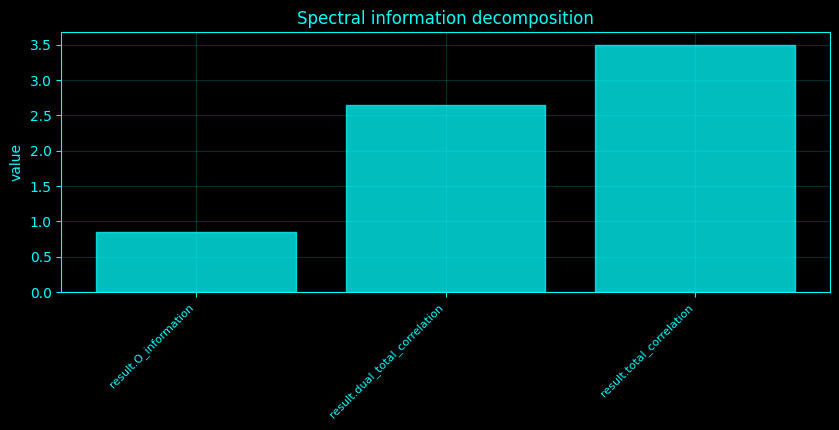

In [107]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _digitize_quantile(x, bins=5):
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) <= 2:
        return np.zeros(len(x), int)
    return np.clip(np.digitize(x, q[1:-1]), 0, len(q) - 2)

def _entropy_disc(*arrs):
    A = np.column_stack(arrs)
    _, cnt = np.unique(A, axis=0, return_counts=True)
    p = cnt / cnt.sum()
    return float(-np.sum(p * np.log(p + EPS)))

def _info_features():
    if 'info' in SPEC_CACHE:
        return SPEC_CACHE['info']
    t, W = _window_bandpower()
    Z = np.log(W + EPS)
    SPEC_CACHE['info'] = (t, Z)
    return SPEC_CACHE['info']

# Method-specific calculation.
def _compute_method_273():
    idx = 273
    name = 'Spectral information decomposition'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, Z = _info_features()
    A = np.mean(Z, axis=2)
    q = [_digitize_quantile(A[:, k], 4) for k in range(min(C, 5))]
    H = lambda inds: _entropy_disc(*[q[k] for k in inds])
    n = len(q)
    Hall = H(list(range(n)))
    tc = sum((H([i]) for i in range(n))) - Hall
    dtc = sum((H([k for k in range(n) if k != i]) for i in range(n))) - (n - 1) * Hall
    return ({'total_correlation': float(tc), 'dual_total_correlation': float(dtc), 'O_information': float(tc - dtc)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_273,_plot_spec=_compute_method_273()
print('Spectral information decomposition')
if isinstance(result_273,dict):
    for _k,_v in result_273.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_273)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_273)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral information decomposition',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral information decomposition',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral information decomposition',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">274. Bandpower covariance analysis</h3>
<p>Bandpower covariance is \(\Sigma_{ij}=\operatorname{Cov}(\log P_i,\log P_j)\) across analysis windows. Log power is used because spectral power is positive and typically right-skewed.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Bandpower covariance analysis
  trace: 5.037511721239445
  condition: 1251.8419511996588


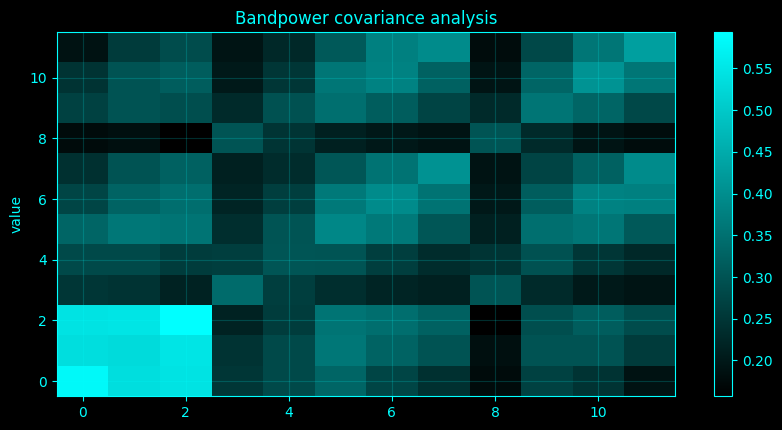

In [108]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_274():
    idx = 274
    name = 'Bandpower covariance analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    __plot_spec = ('summary', cov, name, None, '', 'value')
    return ({'trace': float(np.trace(cov)), 'condition': float(np.linalg.cond(cov + 1e-06 * np.eye(C)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_274,_plot_spec=_compute_method_274()
print('Bandpower covariance analysis')
if isinstance(result_274,dict):
    for _k,_v in result_274.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_274)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_274)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower covariance analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower covariance analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower covariance analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">275. Bandpower correlation networks</h3>
<p>The bandpower correlation network uses Pearson correlation \(r_{ij}=\Sigma_{ij}/\sqrt{\Sigma_{ii}\Sigma_{jj}}\) between windowed log-bandpower trajectories.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [109]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_275():
    idx = 275
    name = 'Bandpower correlation networks'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    __plot_spec = ('summary', corr, name, None, '', 'value')
    return ({'mean_abs_corr': float(np.mean(np.abs(corr[np.triu_indices(C, 1)])))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_275,_plot_spec=_compute_method_275()
print('Bandpower correlation networks')
if isinstance(result_275,dict):
    for _k,_v in result_275.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_275)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_275)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower correlation networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower correlation networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower correlation networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpower correlation networks
  mean_abs_corr: 0.6945463371648507


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">276. Bandpower partial-correlation networks</h3>
<p>Partial correlation is derived from the precision matrix \(\Theta=\Sigma^{-1}\): \(\rho_{ij\cdot rest}=-\Theta_{ij}/\sqrt{\Theta_{ii}\Theta_{jj}}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [110]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_276():
    idx = 276
    name = 'Bandpower partial-correlation networks'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    __plot_spec = ('summary', pcorr, name, None, '', 'value')
    return ({'mean_abs_partial': float(np.mean(np.abs(pcorr[np.triu_indices(C, 1)])))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_276,_plot_spec=_compute_method_276()
print('Bandpower partial-correlation networks')
if isinstance(result_276,dict):
    for _k,_v in result_276.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_276)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_276)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower partial-correlation networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower partial-correlation networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower partial-correlation networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpower partial-correlation networks
  mean_abs_partial: 0.23847803820053382


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">277. Bandpower precision matrices</h3>
<p>The precision matrix \(\Theta=\Sigma^{-1}\) parameterizes a Gaussian graphical model; nonzero off-diagonal entries correspond to conditional dependence under that model.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [111]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_277():
    idx = 277
    name = 'Bandpower precision matrices'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    __plot_spec = ('summary', prec, name, None, '', 'value')
    return ({'precision_fro': float(np.linalg.norm(prec))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_277,_plot_spec=_compute_method_277()
print('Bandpower precision matrices')
if isinstance(result_277,dict):
    for _k,_v in result_277.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_277)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_277)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower precision matrices',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower precision matrices',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower precision matrices',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpower precision matrices
  precision_fro: 447.0108093965615


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">278. Graphical-lasso bandpower networks</h3>
<p>Graphical lasso estimates a sparse precision matrix by minimizing \(\operatorname{tr}(S\Theta)-\log\det\Theta+\lambda\|\Theta\|_{1,\mathrm{off}}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [112]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_278():
    idx = 278
    name = 'Graphical-lasso bandpower networks'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    alpha = max(0.001, 0.03 * np.mean(np.diag(cov)))
    try:
        mdl = GraphicalLasso(alpha=alpha, max_iter=300).fit(A)
        P = mdl.precision_
        nnz = int(np.sum(np.abs(P) > 1e-08) - C)
    except Exception:
        P = prec
        nnz = int(np.sum(np.abs(P) > np.quantile(np.abs(P[np.triu_indices(C, 1)]), 0.75)) * 2)
    __plot_spec = ('summary', P, name, None, '', 'value')
    return ({'offdiag_nonzero': nnz}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_278,_plot_spec=_compute_method_278()
print('Graphical-lasso bandpower networks')
if isinstance(result_278,dict):
    for _k,_v in result_278.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_278)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_278)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Graphical-lasso bandpower networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Graphical-lasso bandpower networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Graphical-lasso bandpower networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Graphical-lasso bandpower networks
  offdiag_nonzero: 68


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/sklearn/covariance/_graph_lasso.py:192: ConvergenceWarning: graphical_lasso: did not converge after 300 iteration: dual gap: -6.273e-03
  warnings.warn(


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">279. Dynamic bandpower networks</h3>
<p>Dynamic bandpower networks recompute channel-channel correlation within successive blocks of spectral-power windows, producing a time-indexed adjacency sequence \(A(t)\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [113]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_279():
    idx = 279
    name = 'Dynamic bandpower networks'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    block = max(6, len(A) // 6)
    mats = []
    for s in range(0, len(A) - block + 1, max(1, block // 2)):
        mats.append(np.corrcoef(A[s:s + block], rowvar=False))
    strength = np.array([np.nanmean(np.abs(m - np.eye(C)), axis=1) for m in mats])
    __plot_spec = ('summary', strength.T, name, None, '', 'value')
    return ({'n_dynamic_networks': len(mats)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_279,_plot_spec=_compute_method_279()
print('Dynamic bandpower networks')
if isinstance(result_279,dict):
    for _k,_v in result_279.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_279)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_279)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Dynamic bandpower networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Dynamic bandpower networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Dynamic bandpower networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Dynamic bandpower networks
  n_dynamic_networks: 11


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">280. Bandpower community detection</h3>
<p>Community detection partitions the weighted bandpower network into groups with stronger within-community than between-community connectivity; modularity is optimized on the thresholded correlation graph.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Bandpower community detection
  communities: 4
  sizes: array(4,), mean=3


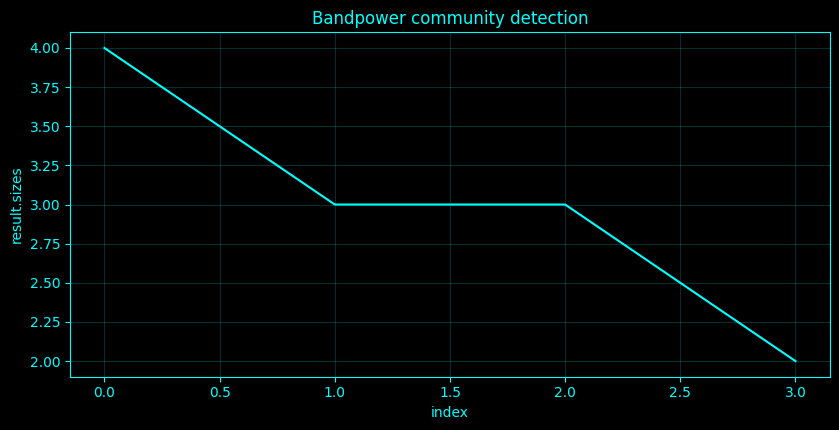

In [114]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _graph_from_matrix(M, quant=0.75):
    A = np.array(M, float, copy=True)
    np.fill_diagonal(A, 0)
    vals = A[np.triu_indices_from(A, 1)]
    th = np.nanquantile(vals, quant) if len(vals) else 0
    G = nx.Graph()
    G.add_nodes_from(range(len(A)))
    for i in range(len(A)):
        for j in range(i + 1, len(A)):
            if np.isfinite(A[i, j]) and A[i, j] >= th:
                G.add_edge(i, j, weight=float(A[i, j]), length=float(1 / (A[i, j] + EPS)))
    return G

# Method-specific calculation.
def _compute_method_280():
    idx = 280
    name = 'Bandpower community detection'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    G = _graph_from_matrix(np.abs(corr), 0.75)
    comm = list(nx.algorithms.community.greedy_modularity_communities(G, weight='weight')) if G.number_of_edges() else []
    return ({'communities': len(comm), 'sizes': [len(x) for x in comm]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_280,_plot_spec=_compute_method_280()
print('Bandpower community detection')
if isinstance(result_280,dict):
    for _k,_v in result_280.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_280)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_280)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower community detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower community detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower community detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">281. Bandpower graph spectra</h3>
<p>For weighted adjacency \(W\), the graph Laplacian is \(L=D-W\). Its eigenvalues summarize connectedness and graph-scale structure; \(\lambda_2\) is algebraic connectivity for a connected undirected graph.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [115]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_281():
    idx = 281
    name = 'Bandpower graph spectra'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    M = np.abs(corr)
    np.fill_diagonal(M, 0)
    D = np.diag(M.sum(1))
    lam = np.linalg.eigvalsh(D - M)
    __plot_spec = ('summary', lam, name, np.arange(C), 'index', 'Laplacian eigenvalue')
    return ({'algebraic_connectivity': float(lam[1]) if C > 1 else 0}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_281,_plot_spec=_compute_method_281()
print('Bandpower graph spectra')
if isinstance(result_281,dict):
    for _k,_v in result_281.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_281)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_281)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower graph spectra',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower graph spectra',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower graph spectra',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpower graph spectra
  algebraic_connectivity: 6.627302254191035


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">282. Bandpower hubness</h3>
<p>Bandpower hubness is weighted degree (strength), \(s_i=\sum_j|r_{ij}|\), on the bandpower-correlation network.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [116]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_282():
    idx = 282
    name = 'Bandpower hubness'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    M = np.abs(corr)
    np.fill_diagonal(M, 0)
    strength = M.sum(1)
    __plot_spec = ('summary', strength, name, None, '', 'value')
    return ({'hub': CH_NAMES[int(np.argmax(strength))]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_282,_plot_spec=_compute_method_282()
print('Bandpower hubness')
if isinstance(result_282,dict):
    for _k,_v in result_282.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_282)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_282)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower hubness',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower hubness',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower hubness',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpower hubness
  hub: Fz


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">283. Bandpower left-right asymmetry</h3>
<p>Left-right bandpower asymmetry uses paired homologous channels and log ratios, \(A_{L,R}=\log P_L-\log P_R=\log(P_L/P_R)\), so equal proportional changes cancel naturally.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [117]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_283():
    idx = 283
    name = 'Bandpower left-right asymmetry'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    _, BP = _bandpower_matrix()
    alpha = BP[:, aidx]
    vals = np.zeros(C)
    pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('C3', 'C4'), ('P3', 'P4'), ('O1', 'O2')]
    for l, r in pairs:
        if l in CH_NAMES and r in CH_NAMES:
            il, ir = (CH_NAMES.index(l), CH_NAMES.index(r))
            d = np.log(alpha[il] + EPS) - np.log(alpha[ir] + EPS)
            vals[il] = d
            vals[ir] = -d
    __plot_spec = ('scalp', vals, name, None, '', 'value')
    return ({'mean_abs_log_asymmetry': float(np.mean(np.abs(vals)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_283,_plot_spec=_compute_method_283()
print('Bandpower left-right asymmetry')
if isinstance(result_283,dict):
    for _k,_v in result_283.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_283)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_283)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower left-right asymmetry',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower left-right asymmetry',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower left-right asymmetry',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpower left-right asymmetry
  mean_abs_log_asymmetry: 0.12009999608412707


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">284. Bandpower regional gradients</h3>
<p>A regional bandpower gradient is the least-squares slope of log bandpower versus electrode coordinate; it is a finite sensor-space spatial trend, not a cortical gradient.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [118]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_284():
    idx = 284
    name = 'Bandpower regional gradients'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    _, BP = _bandpower_matrix()
    y = np.array([ELECTRODE_XY.get(ch, (0, 0))[1] for ch in CH_NAMES])
    z = np.log(BP[:, aidx] + EPS)
    slope = np.polyfit(y, z, 1)[0]
    __plot_spec = ('scalp', z, name, None, '', 'value')
    return ({'posterior_to_anterior_slope': float(slope)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_284,_plot_spec=_compute_method_284()
print('Bandpower regional gradients')
if isinstance(result_284,dict):
    for _k,_v in result_284.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_284)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_284)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower regional gradients',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower regional gradients',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower regional gradients',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpower regional gradients
  posterior_to_anterior_slope: -1.8205246927576322


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">285. Bandpower topographic interpolation</h3>
<p>Topographic interpolation estimates a smooth sensor-space field from irregular electrode samples. The displayed values remain sensor-level bandpower; interpolation does not create independent observations.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [119]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_285():
    idx = 285
    name = 'Bandpower topographic interpolation'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    t, W = _window_bandpower()
    aidx = list(BANDS).index('alpha')
    A = np.log(W[:, :, aidx] + EPS)
    cov = np.cov(A, rowvar=False)
    corr = np.corrcoef(A, rowvar=False)
    prec = np.linalg.pinv(cov + 1e-06 * np.eye(C))
    pcorr = -prec / np.sqrt(np.outer(np.diag(prec), np.diag(prec)) + EPS)
    np.fill_diagonal(pcorr, 1)
    _, BP = _bandpower_matrix()
    vals = np.log(BP[:, aidx] + EPS)
    xy = np.array([ELECTRODE_XY[ch] for ch in CH_NAMES])
    gx, gy = np.mgrid[-1.1:1.1:80j, -1.1:1.1:80j]
    from scipy.interpolate import griddata
    zi = griddata(xy, vals, (gx, gy), method='linear')
    __plot_spec = ('summary', zi.T, name, None, '', 'value')
    return ({'grid_finite_fraction': float(np.mean(np.isfinite(zi)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_285,_plot_spec=_compute_method_285()
print('Bandpower topographic interpolation')
if isinstance(result_285,dict):
    for _k,_v in result_285.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_285)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_285)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower topographic interpolation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower topographic interpolation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower topographic interpolation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpower topographic interpolation
  grid_finite_fraction: 0.23125


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">286. Source-space spectral analysis</h3>
<p>Source-space spectra require a forward model and inverse operator \(W\), giving estimated source activity \(\hat s(t)=Wx(t)\). Because sensor EEG alone does not identify \(W\), this cell only executes source spectra when `SPECTRAL_INVERSE_OPERATOR` is supplied.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [120]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_286():
    idx = 286
    name = 'Source-space spectral analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    W = globals().get('SPECTRAL_INVERSE_OPERATOR', None)
    if W is None:
        return ({'status': 'requires SPECTRAL_INVERSE_OPERATOR', 'reason': 'sensor EEG alone does not identify cortical source spectra'}, locals().get('__plot_spec', None))
    W = np.asarray(W)
    Y = X @ W.T
    fs, Ps = _psd_of(Y)
    __plot_spec = ('summary', 10 * np.log10(Ps + EPS), name, fs, 'Hz', 'dB')
    return ({'sources': Y.shape[1]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_286,_plot_spec=_compute_method_286()
print('Source-space spectral analysis')
if isinstance(result_286,dict):
    for _k,_v in result_286.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_286)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_286)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Source-space spectral analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Source-space spectral analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Source-space spectral analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Source-space spectral analysis
  status: requires SPECTRAL_INVERSE_OPERATOR
  reason: sensor EEG alone does not identify cortical source spectra


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">287. Surface Laplacian spectral analysis</h3>
<p>A discrete surface Laplacian uses an electrode-neighbour graph \(L=D-W\). Applying \(LX(t)\) approximates spatial second derivatives; current-source-density convention differs by sign/physical scaling. Without a spherical head model this is explicitly a graph-Laplacian sensor-space approximation.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [121]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _finite_diff_laplacian_matrix():
    xy = np.array([ELECTRODE_XY.get(ch, (np.nan, np.nan)) for ch in CH_NAMES], float)
    d = squareform(pdist(xy))
    k = min(max(3, _SPEED['graph_k']), max(C - 1, 1))
    W = np.zeros((C, C))
    for i in range(C):
        jj = np.argsort(d[i])[1:k + 1]
        sig = np.median(d[i, jj]) + EPS
        W[i, jj] = np.exp(-d[i, jj] ** 2 / (2 * sig ** 2))
    W = np.maximum(W, W.T)
    D = np.diag(W.sum(1))
    return D - W

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_287():
    idx = 287
    name = 'Surface Laplacian spectral analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    L = _finite_diff_laplacian_matrix()
    Y = -(X @ L.T) if idx == 288 else X @ L.T
    fs, Ps = _psd_of(Y)
    alpha = _band_integral(Ps, fs, BANDS['alpha'])
    __plot_spec = ('scalp', np.log(alpha + EPS), name, None, '', 'value')
    return ({'operator_norm': float(np.linalg.norm(L))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_287,_plot_spec=_compute_method_287()
print('Surface Laplacian spectral analysis')
if isinstance(result_287,dict):
    for _k,_v in result_287.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_287)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_287)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Surface Laplacian spectral analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Surface Laplacian spectral analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Surface Laplacian spectral analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Surface Laplacian spectral analysis
  operator_norm: 13.27586604754654


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">288. Current source density spectral analysis</h3>
<p>A discrete surface Laplacian uses an electrode-neighbour graph \(L=D-W\). Applying \(LX(t)\) approximates spatial second derivatives; current-source-density convention differs by sign/physical scaling. Without a spherical head model this is explicitly a graph-Laplacian sensor-space approximation.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [122]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _finite_diff_laplacian_matrix():
    xy = np.array([ELECTRODE_XY.get(ch, (np.nan, np.nan)) for ch in CH_NAMES], float)
    d = squareform(pdist(xy))
    k = min(max(3, _SPEED['graph_k']), max(C - 1, 1))
    W = np.zeros((C, C))
    for i in range(C):
        jj = np.argsort(d[i])[1:k + 1]
        sig = np.median(d[i, jj]) + EPS
        W[i, jj] = np.exp(-d[i, jj] ** 2 / (2 * sig ** 2))
    W = np.maximum(W, W.T)
    D = np.diag(W.sum(1))
    return D - W

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_288():
    idx = 288
    name = 'Current source density spectral analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    L = _finite_diff_laplacian_matrix()
    Y = -(X @ L.T) if idx == 288 else X @ L.T
    fs, Ps = _psd_of(Y)
    alpha = _band_integral(Ps, fs, BANDS['alpha'])
    __plot_spec = ('scalp', np.log(alpha + EPS), name, None, '', 'value')
    return ({'operator_norm': float(np.linalg.norm(L))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_288,_plot_spec=_compute_method_288()
print('Current source density spectral analysis')
if isinstance(result_288,dict):
    for _k,_v in result_288.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_288)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_288)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Current source density spectral analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Current source density spectral analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Current source density spectral analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Current source density spectral analysis
  operator_norm: 13.27586604754654


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">289. Bipolar montage spectral comparison</h3>
<p>A bipolar montage replaces potentials by pair differences \(y_{ab}(t)=x_a(t)-x_b(t)\). Its PSD follows from the linear combination and therefore changes both signal and reference sensitivity.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [123]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_289():
    idx = 289
    name = 'Bipolar montage spectral comparison'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('C3', 'C4'), ('P3', 'P4'), ('O1', 'O2')]
    ys = []
    labels = []
    for a, b in pairs:
        if a in CH_NAMES and b in CH_NAMES:
            ys.append(X[:, CH_NAMES.index(a)] - X[:, CH_NAMES.index(b)])
            labels.append(f'{a}-{b}')
    if not ys:
        return ({'status': 'no named bipolar pairs available'}, locals().get('__plot_spec', None))
    Y = np.column_stack(ys)
    fs, Ps = _psd_of(Y)
    __plot_spec = ('summary', 10 * np.log10(Ps + EPS), name, fs, 'Hz', 'dB')
    return ({'n_bipolar_pairs': len(labels)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_289,_plot_spec=_compute_method_289()
print('Bipolar montage spectral comparison')
if isinstance(result_289,dict):
    for _k,_v in result_289.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_289)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_289)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bipolar montage spectral comparison',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bipolar montage spectral comparison',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bipolar montage spectral comparison',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bipolar montage spectral comparison
  n_bipolar_pairs: 2


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">290. Common-average-reference spectral comparison</h3>
<p>Common-average reference subtracts the instantaneous channel mean, \(x_i^{CAR}(t)=x_i(t)-C^{-1}\sum_jx_j(t)\). The cell compares PSDs before and after this linear rereferencing.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [124]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_290():
    idx = 290
    name = 'Common-average-reference spectral comparison'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Y = X - X.mean(1, keepdims=True)
    fs, Pc = _psd_of(Y)
    diff = np.mean(np.abs(np.log(Pc + EPS) - np.log(P + EPS)))
    return ({'mean_abs_log_psd_change': float(diff)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_290,_plot_spec=_compute_method_290()
print('Common-average-reference spectral comparison')
if isinstance(result_290,dict):
    for _k,_v in result_290.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_290)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_290)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Common-average-reference spectral comparison',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Common-average-reference spectral comparison',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Common-average-reference spectral comparison',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Common-average-reference spectral comparison
  mean_abs_log_psd_change: 0.7470395130780733


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">291. Reference-sensitivity spectral audit</h3>
<p>Reference/montage sensitivity is quantified by recomputing the same spectral statistic after a valid rereferencing transform and comparing the result. This is a robustness audit, not evidence that one montage is physiologically correct.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [125]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_291():
    idx = 291
    name = 'Reference-sensitivity spectral audit'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Y = X - X.mean(1, keepdims=True)
    fs, Pc = _psd_of(Y)
    _, B0 = _bandpower_matrix()
    Bc = np.vstack([_band_integral(Pc, fs, b) for b in BANDS.values()]).T
    r = np.corrcoef(np.log(B0.ravel() + EPS), np.log(Bc.ravel() + EPS))[0, 1]
    return ({'raw_vs_CAR_bandpower_correlation': float(r)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_291,_plot_spec=_compute_method_291()
print('Reference-sensitivity spectral audit')
if isinstance(result_291,dict):
    for _k,_v in result_291.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_291)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_291)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Reference-sensitivity spectral audit',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Reference-sensitivity spectral audit',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Reference-sensitivity spectral audit',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Reference-sensitivity spectral audit
  raw_vs_CAR_bandpower_correlation: 0.7161222215367132


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">292. Montage-sensitivity spectral audit</h3>
<p>Reference/montage sensitivity is quantified by recomputing the same spectral statistic after a valid rereferencing transform and comparing the result. This is a robustness audit, not evidence that one montage is physiologically correct.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Montage-sensitivity spectral audit
  raw_alpha: 0.005635012515077683
  CAR_alpha: 0.0018699908905626848
  ratio: 0.3318521272538919


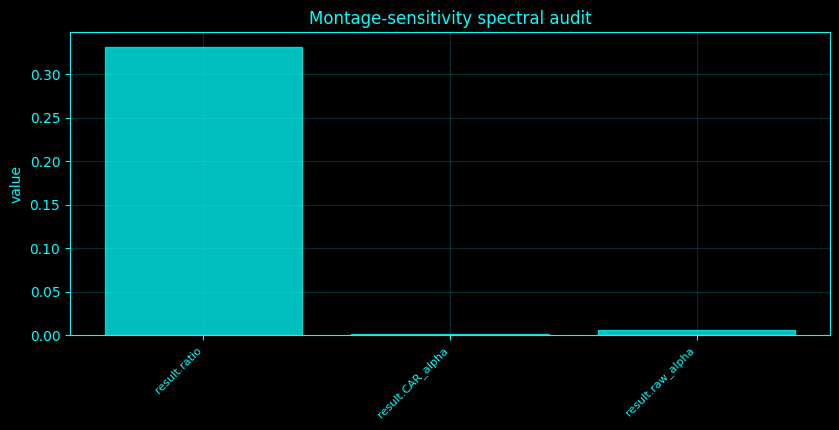

In [126]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_292():
    idx = 292
    name = 'Montage-sensitivity spectral audit'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Y = X - X.mean(1, keepdims=True)
    fs, Pc = _psd_of(Y)
    raw = np.mean(_band_integral(P, f, BANDS['alpha']))
    car = np.mean(_band_integral(Pc, fs, BANDS['alpha']))
    return ({'raw_alpha': float(raw), 'CAR_alpha': float(car), 'ratio': float(car / (raw + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_292,_plot_spec=_compute_method_292()
print('Montage-sensitivity spectral audit')
if isinstance(result_292,dict):
    for _k,_v in result_292.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_292)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_292)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Montage-sensitivity spectral audit',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Montage-sensitivity spectral audit',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Montage-sensitivity spectral audit',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">293. Artifact-sensitive spectral audit</h3>
<p>Artifact sensitivity compares spectra before and after excluding the highest-amplitude multichannel samples. The resulting difference estimates dependence on extreme transients; it is not a substitute for artifact classification.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Artifact-sensitive spectral audit
  retained_fraction: 0.9499551166965888
  alpha_change_fraction: -0.0496052761394366


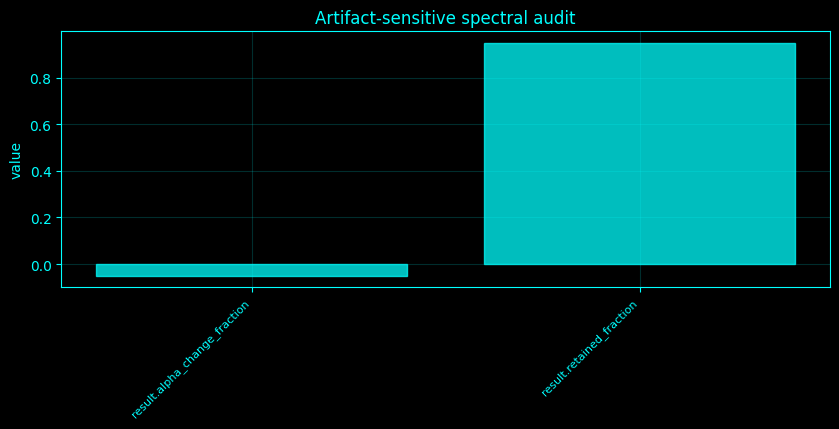

In [127]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_293():
    idx = 293
    name = 'Artifact-sensitive spectral audit'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    amp = np.max(np.abs(X), axis=1)
    mask = amp < np.quantile(amp, 0.95)
    fs, Pclean = _psd_of(X[mask])
    a0 = np.mean(_band_integral(P, f, BANDS['alpha']))
    a1 = np.mean(_band_integral(Pclean, fs, BANDS['alpha']))
    return ({'retained_fraction': float(mask.mean()), 'alpha_change_fraction': float((a1 - a0) / (a0 + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_293,_plot_spec=_compute_method_293()
print('Artifact-sensitive spectral audit')
if isinstance(result_293,dict):
    for _k,_v in result_293.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_293)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_293)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Artifact-sensitive spectral audit',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Artifact-sensitive spectral audit',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Artifact-sensitive spectral audit',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">294. Line-noise sensitivity audit</h3>
<p>Line-noise sensitivity is the ratio of power in a narrow 50/60-Hz line band to nearby background power, provided the line frequency lies below Nyquist.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Line-noise sensitivity audit
  line_hz: 50.0
  line_to_local_background: 0.5920108409707213


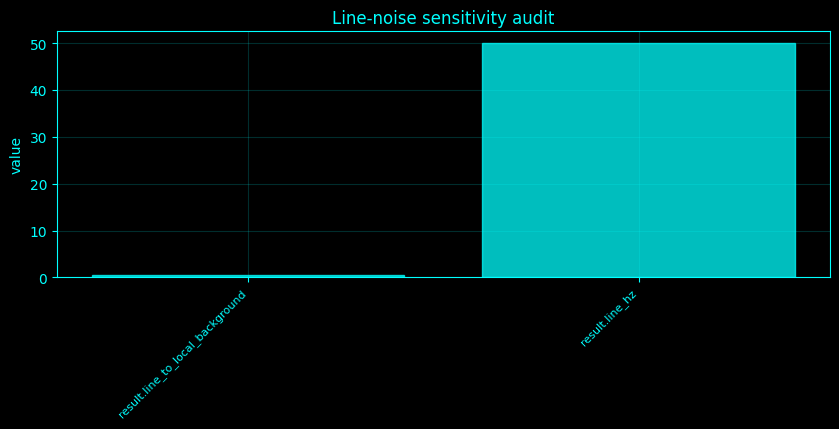

In [128]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

# Method-specific calculation.
def _compute_method_294():
    idx = 294
    name = 'Line-noise sensitivity audit'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    target = 60.0 if _fs > 125 else 50.0
    if target >= 0.49 * _fs:
        return ({'status': 'line frequency above analysis Nyquist'}, locals().get('__plot_spec', None))
    bw = (target - 1, target + 1)
    lp = np.mean(_band_integral(P, f, bw))
    bg = np.mean(_band_integral(P, f, (target - 5, target - 2)) + _band_integral(P, f, (target + 2, target + 5))) / 2
    return ({'line_hz': target, 'line_to_local_background': float(lp / (bg + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_294,_plot_spec=_compute_method_294()
print('Line-noise sensitivity audit')
if isinstance(result_294,dict):
    for _k,_v in result_294.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_294)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_294)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Line-noise sensitivity audit',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Line-noise sensitivity audit',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Line-noise sensitivity audit',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">295. Notch-filter sensitivity analysis</h3>
<p>Notch sensitivity applies a second-order IIR notch centered at the local line frequency and reports attenuation of narrowband line power.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [129]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_295():
    idx = 295
    name = 'Notch-filter sensitivity analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    target = 60.0 if _fs > 125 else 50.0
    if target >= 0.49 * _fs:
        return ({'status': 'notch target above Nyquist'}, locals().get('__plot_spec', None))
    b, a = signal.iirnotch(target, Q=30, fs=_fs)
    Y = signal.filtfilt(b, a, X, axis=0)
    fs, Pn = _psd_of(Y)
    before = np.mean(_band_integral(P, f, (target - 1, target + 1)))
    after = np.mean(_band_integral(Pn, fs, (target - 1, target + 1)))
    return ({'suppression_db': float(10 * np.log10((before + EPS) / (after + EPS)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_295,_plot_spec=_compute_method_295()
print('Notch-filter sensitivity analysis')
if isinstance(result_295,dict):
    for _k,_v in result_295.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_295)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_295)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Notch-filter sensitivity analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Notch-filter sensitivity analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Notch-filter sensitivity analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Notch-filter sensitivity analysis
  suppression_db: 10.063455669502186


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">296. Bandpass sensitivity analysis</h3>
<p>Bandpass sensitivity applies the same PSD estimator after a fixed 1–45-Hz Butterworth bandpass and compares retained spectral power.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [130]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_296():
    idx = 296
    name = 'Bandpass sensitivity analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    hi = min(45, 0.45 * _fs)
    sos = signal.butter(4, [1 / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    Y = signal.sosfiltfilt(sos, X, axis=0)
    fs, Pb = _psd_of(Y)
    return ({'passband_total_power': float(np.trapz(np.mean(Pb, axis=1), fs))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_296,_plot_spec=_compute_method_296()
print('Bandpass sensitivity analysis')
if isinstance(result_296,dict):
    for _k,_v in result_296.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_296)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_296)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpass sensitivity analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpass sensitivity analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpass sensitivity analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpass sensitivity analysis
  passband_total_power: 0.0983175706925159


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">297. Window-length sensitivity analysis</h3>
<p>Welch window length controls the bias-resolution tradeoff: frequency-bin spacing is approximately \(\Delta f=f_s/N_{seg}\), while more shorter segments reduce variance.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Window-length sensitivity analysis
  1s_alpha: 0.005078739904627932
  2s_alpha: 0.0053855921794403174
  4s_alpha: 0.005531570051113855


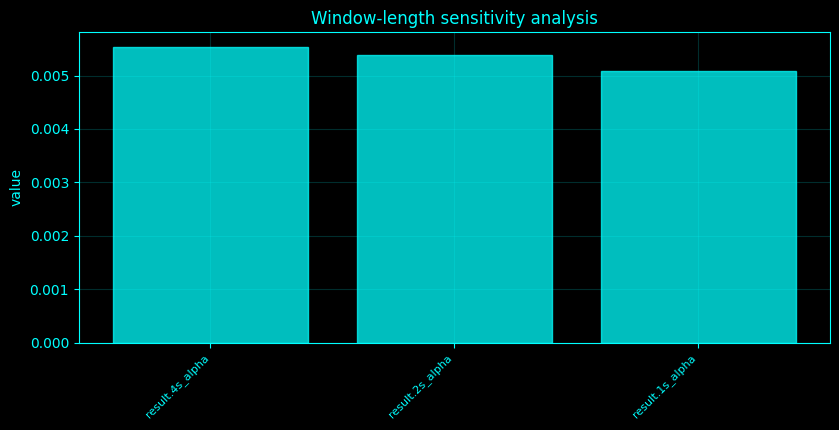

In [131]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_297():
    idx = 297
    name = 'Window-length sensitivity analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    vals = {}
    for sec in (1, 2, 4):
        n = min(N, max(32, int(sec * _fs)))
        ff, pp = _psd_of(X, nperseg=n)
        vals[f'{sec}s_alpha'] = float(np.mean(_band_integral(pp, ff, BANDS['alpha'])))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_297,_plot_spec=_compute_method_297()
print('Window-length sensitivity analysis')
if isinstance(result_297,dict):
    for _k,_v in result_297.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_297)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_297)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Window-length sensitivity analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Window-length sensitivity analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Window-length sensitivity analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">298. Overlap sensitivity analysis</h3>
<p>Welch overlap changes how many tapered segments contribute to the average. Greater overlap increases reuse of samples; adjacent estimates are therefore not independent.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Overlap sensitivity analysis
  overlap_0.00: 0.006068074896601139
  overlap_0.50: 0.005635012515077683
  overlap_0.75: 0.005634377671322479


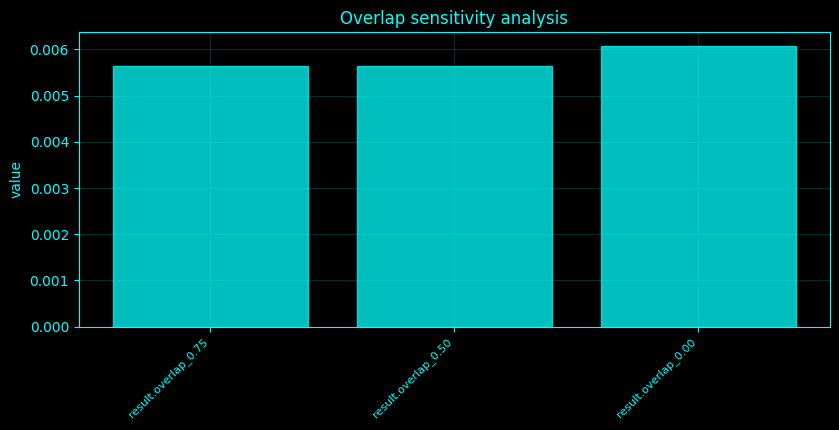

In [132]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

# Method-specific calculation.
def _compute_method_298():
    idx = 298
    name = 'Overlap sensitivity analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    n = min(int(_SPEED['nperseg']), N)
    vals = {}
    for ov in (0, 0.5, 0.75):
        ff, pp = signal.welch(X, fs=_fs, axis=0, nperseg=n, noverlap=min(n - 1, int(ov * n)))
        vals[f'overlap_{ov:.2f}'] = float(np.mean(_band_integral(pp, ff, BANDS['alpha'])))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_298,_plot_spec=_compute_method_298()
print('Overlap sensitivity analysis')
if isinstance(result_298,dict):
    for _k,_v in result_298.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_298)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_298)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Overlap sensitivity analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Overlap sensitivity analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Overlap sensitivity analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">299. NFFT sensitivity analysis</h3>
<p>Zero-padding changes the sampled frequency grid, \(\Delta f=f_s/N_{FFT}\), but does not improve the intrinsic resolving power set by the data window.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The Fourier transform represents a time-domain signal as a weighted sum of sinusoidal components. Each Fourier coefficient is complex: its magnitude describes the strength of a frequency component, while its angle describes phase relative to the chosen time origin. The discrete Fourier transform evaluates this representation only at a finite set of frequencies determined by the sampling rate and record length. It describes global frequency content over the analyzed window and does not by itself show when a frequency occurs.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


NFFT sensitivity analysis
  nfft_x1_df: 0.244140625
  nfft_x2_df: 0.1220703125
  nfft_x4_df: 0.06103515625


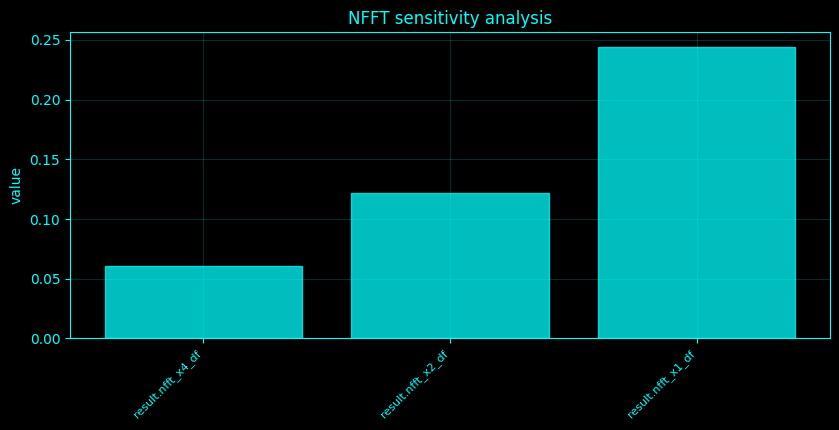

In [133]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_299():
    idx = 299
    name = 'NFFT sensitivity analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    n = min(int(_SPEED['nperseg']), N)
    vals = {}
    for mult in (1, 2, 4):
        ff, pp = signal.welch(X, fs=_fs, axis=0, nperseg=n, noverlap=n // 2, nfft=max(n, n * mult))
        vals[f'nfft_x{mult}_df'] = float(ff[1] - ff[0])
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_299,_plot_spec=_compute_method_299()
print('NFFT sensitivity analysis')
if isinstance(result_299,dict):
    for _k,_v in result_299.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_299)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_299)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'NFFT sensitivity analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'NFFT sensitivity analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('NFFT sensitivity analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">300. Detrending sensitivity analysis</h3>
<p>Detrending removes fitted low-order components before spectral estimation. Constant detrending subtracts the mean; linear detrending removes the least-squares line.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Detrending sensitivity analysis
  constant: 0.005635012515077683
  linear: 0.005635012661976129
  False: 0.005635012515077683


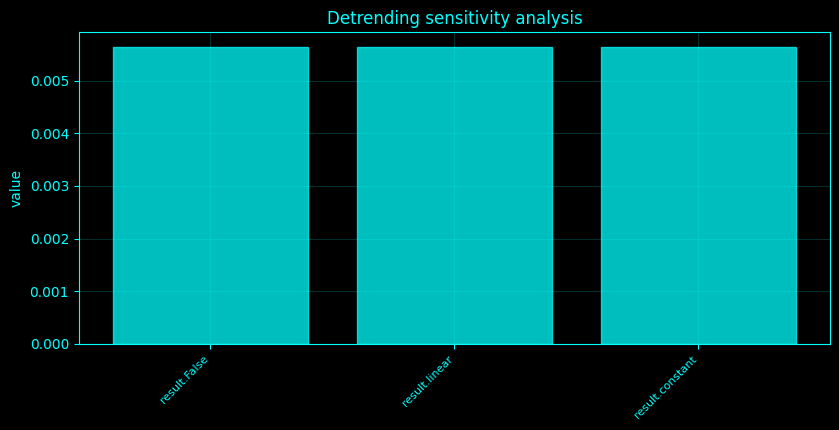

In [134]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_300():
    idx = 300
    name = 'Detrending sensitivity analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    vals = {}
    for d in ('constant', 'linear', False):
        ff, pp = _psd_of(X, detrend=d)
        vals[str(d)] = float(np.mean(_band_integral(pp, ff, BANDS['alpha'])))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_300,_plot_spec=_compute_method_300()
print('Detrending sensitivity analysis')
if isinstance(result_300,dict):
    for _k,_v in result_300.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_300)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_300)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Detrending sensitivity analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Detrending sensitivity analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Detrending sensitivity analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">301. Taper sensitivity analysis</h3>
<p>Tapers trade main-lobe width against side-lobe leakage. Hann, Hamming, and Blackman windows therefore give different leakage and resolution properties even with identical segment length.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Taper sensitivity analysis
  hann: 0.005635012515077683
  hamming: 0.005841592145849623
  blackman: 0.005636003862359636


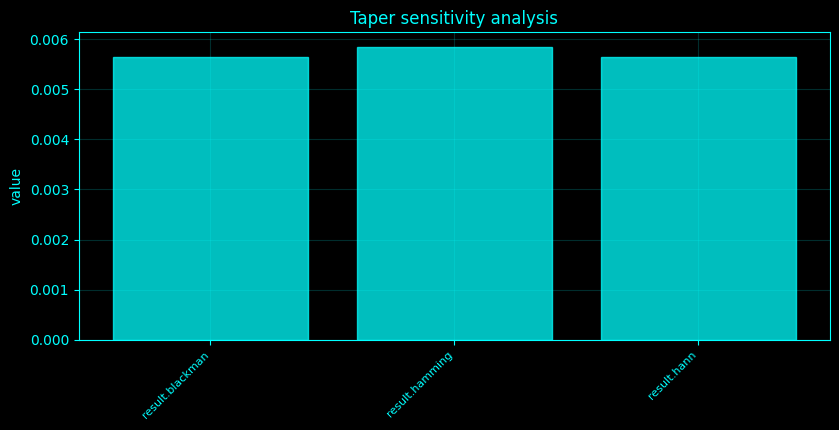

In [135]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_301():
    idx = 301
    name = 'Taper sensitivity analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    vals = {}
    for w in ('hann', 'hamming', 'blackman'):
        ff, pp = _psd_of(X, window=w)
        vals[w] = float(np.mean(_band_integral(pp, ff, BANDS['alpha'])))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_301,_plot_spec=_compute_method_301()
print('Taper sensitivity analysis')
if isinstance(result_301,dict):
    for _k,_v in result_301.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_301)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_301)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Taper sensitivity analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Taper sensitivity analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Taper sensitivity analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">302. Downsampling sensitivity analysis</h3>
<p>Downsampling is valid only after antialias filtering and with the new sampling rate used in all frequency formulas. `resample_poly` performs the antialias filtering before decimation.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [136]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_302():
    idx = 302
    name = 'Downsampling sensitivity analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    fs2 = _fs / 2
    Y = signal.resample_poly(X, 1, 2, axis=0)
    f2, p2 = _psd_of(Y, fs=fs2)
    a0 = np.mean(_band_integral(P, f, BANDS['alpha']))
    a2 = np.mean(_band_integral(p2, f2, BANDS['alpha']))
    return ({'alpha_power_ratio_downsampled_to_original': float(a2 / (a0 + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_302,_plot_spec=_compute_method_302()
print('Downsampling sensitivity analysis')
if isinstance(result_302,dict):
    for _k,_v in result_302.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_302)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_302)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Downsampling sensitivity analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Downsampling sensitivity analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Downsampling sensitivity analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Downsampling sensitivity analysis
  alpha_power_ratio_downsampled_to_original: 0.9803991084155035


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">303. Segment-length robustness analysis</h3>
<p>Segment-length robustness recomputes the same bandpower statistic using progressively longer prefixes of the EEG segment to reveal finite-record dependence.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Segment-length robustness analysis
  0.25: 0.005329241727234449
  0.5: 0.00572953998170841
  1.0: 0.005635012515077683


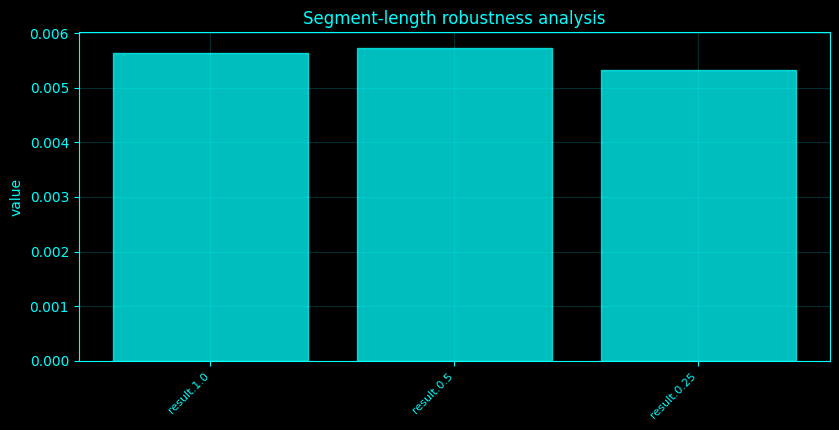

In [137]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_303():
    idx = 303
    name = 'Segment-length robustness analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    vals = {}
    for frac in (0.25, 0.5, 1.0):
        nn = max(64, int(N * frac))
        ff, pp = _psd_of(X[:nn])
        vals[str(frac)] = float(np.mean(_band_integral(pp, ff, BANDS['alpha'])))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_303,_plot_spec=_compute_method_303()
print('Segment-length robustness analysis')
if isinstance(result_303,dict):
    for _k,_v in result_303.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_303)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_303)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Segment-length robustness analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Segment-length robustness analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Segment-length robustness analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">304. Frequency-resolution robustness analysis</h3>
<p>Frequency resolution is the Fourier-grid spacing \(\Delta f=f_s/N_{FFT}\); when \(N_{FFT}=N_{seg}\), longer Welch segments produce finer nominal frequency spacing.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Frequency-resolution robustness analysis
  128: 0.9765625
  256: 0.48828125
  512: 0.244140625
  1024: 0.1220703125


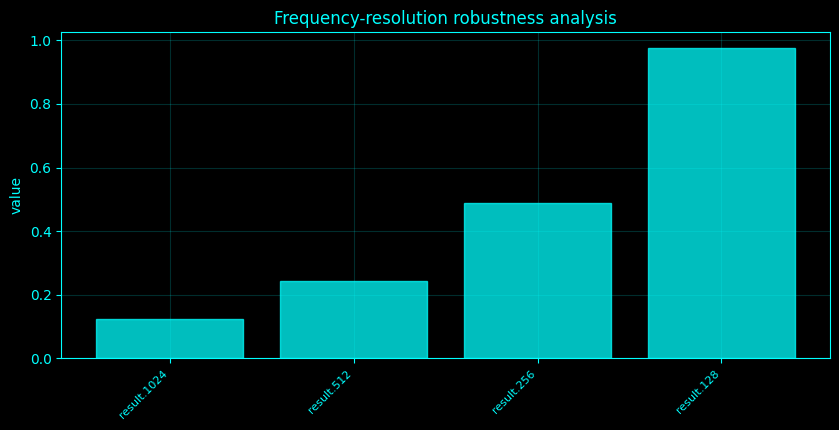

In [138]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_304():
    idx = 304
    name = 'Frequency-resolution robustness analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    vals = {}
    for n in (128, 256, 512, 1024):
        nn = min(n, N)
        ff, pp = _psd_of(X, nperseg=nn)
        vals[str(nn)] = float(ff[1] - ff[0]) if len(ff) > 1 else np.nan
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_304,_plot_spec=_compute_method_304()
print('Frequency-resolution robustness analysis')
if isinstance(result_304,dict):
    for _k,_v in result_304.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_304)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_304)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-resolution robustness analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-resolution robustness analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-resolution robustness analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">305. Spectral leakage diagnostics</h3>
<p>Spectral leakage is energy spread away from a narrow spectral component because a finite observation window convolves the true spectrum with the window spectrum. The correction cell compares a DPSS multitaper estimate, which averages orthogonal low-leakage tapers, with the single-window result.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Spectral leakage diagnostics
  peak_hz: 4.150390625
  outside_±1Hz_fraction: 0.6736124435724767


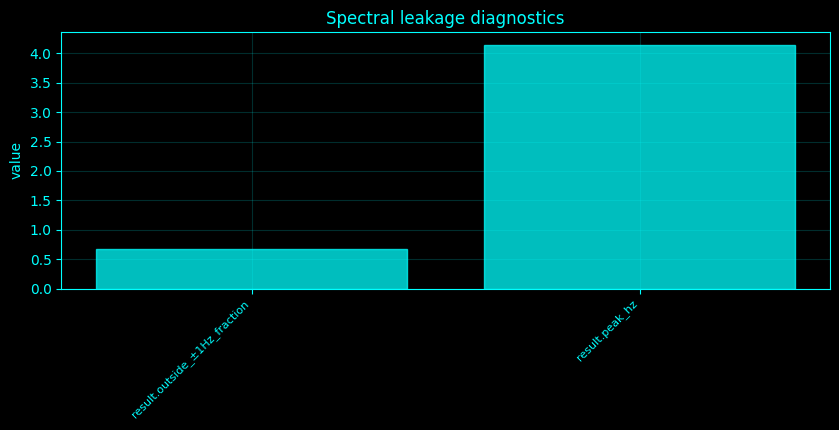

In [139]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_305():
    idx = 305
    name = 'Spectral leakage diagnostics'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    y = X[:, 0]
    mm = (f >= 4) & (f <= 30)
    fp = float(f[mm][np.argmax(P[mm, 0])])
    near = (f >= fp - 1) & (f <= fp + 1)
    total = (f >= 2) & (f <= 45)
    leak = float((np.sum(P[total, 0]) - np.sum(P[near, 0])) / (np.sum(P[total, 0]) + EPS))
    return ({'peak_hz': fp, 'outside_±1Hz_fraction': leak}, locals().get('__plot_spec', None))
    vals = {}
    for w in ('boxcar', 'hann', 'blackman'):
        ff, pp = _psd_of(X[:, [0]], window=w)
        near = (ff >= fp - 1) & (ff <= fp + 1)
        tot = (ff >= 2) & (ff <= 45)
        vals[w] = float((np.sum(pp[tot, 0]) - np.sum(pp[near, 0])) / (np.sum(pp[tot, 0]) + EPS))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_305,_plot_spec=_compute_method_305()
print('Spectral leakage diagnostics')
if isinstance(result_305,dict):
    for _k,_v in result_305.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_305)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_305)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral leakage diagnostics',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral leakage diagnostics',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral leakage diagnostics',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">306. Spectral leakage correction</h3>
<p>Spectral leakage is energy spread away from a narrow spectral component because a finite observation window convolves the true spectrum with the window spectrum. The correction cell compares a DPSS multitaper estimate, which averages orthogonal low-leakage tapers, with the single-window result.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [140]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_306():
    idx = 306
    name = 'Spectral leakage correction'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    y = X[:, 0]
    mm = (f >= 4) & (f <= 30)
    fp = float(f[mm][np.argmax(P[mm, 0])])
    n = min(int(_SPEED['nperseg']), N)
    K = 3
    tap = signal.windows.dpss(n, NW=2.5, Kmax=K)
    seg = y[:n] - np.mean(y[:n])
    ps = []
    for tt in tap:
        F = np.fft.rfft(seg * tt)
        ps.append(np.abs(F) ** 2 / (_fs * np.sum(tt ** 2)))
    pm = np.mean(ps, axis=0)
    fm = np.fft.rfftfreq(n, 1 / _fs)
    near = (fm >= fp - 1) & (fm <= fp + 1)
    tot = (fm >= 2) & (fm <= 45)
    leak = float((np.sum(pm[tot]) - np.sum(pm[near])) / (np.sum(pm[tot]) + EPS))
    return ({'multitaper_outside_±1Hz_fraction': leak}, locals().get('__plot_spec', None))
    vals = {}
    for w in ('boxcar', 'hann', 'blackman'):
        ff, pp = _psd_of(X[:, [0]], window=w)
        near = (ff >= fp - 1) & (ff <= fp + 1)
        tot = (ff >= 2) & (ff <= 45)
        vals[w] = float((np.sum(pp[tot, 0]) - np.sum(pp[near, 0])) / (np.sum(pp[tot, 0]) + EPS))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_306,_plot_spec=_compute_method_306()
print('Spectral leakage correction')
if isinstance(result_306,dict):
    for _k,_v in result_306.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_306)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_306)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral leakage correction',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral leakage correction',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral leakage correction',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral leakage correction
  multitaper_outside_±1Hz_fraction: 0.877635255682971


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">307. Window-function comparison</h3>
<p>Window-function comparison holds the data and segment length fixed while changing the taper, isolating the window's effect on leakage and bandwidth.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Window-function comparison
  boxcar: 0.9244429991190396
  hann: 0.6736124435724767
  blackman: 0.675155695682559


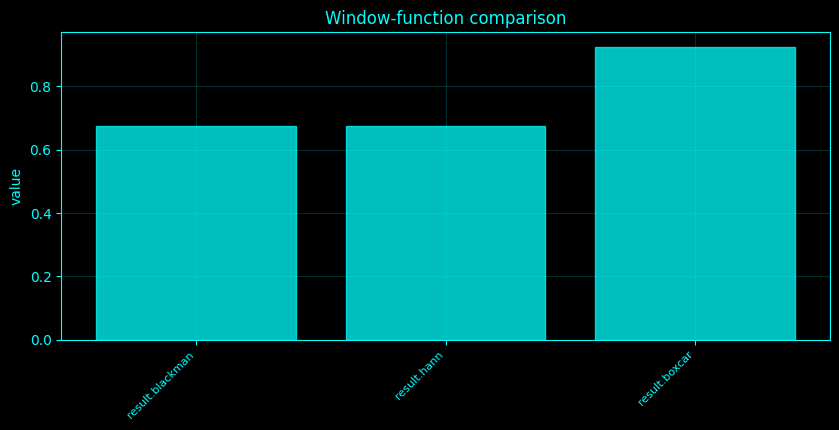

In [141]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_307():
    idx = 307
    name = 'Window-function comparison'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    y = X[:, 0]
    mm = (f >= 4) & (f <= 30)
    fp = float(f[mm][np.argmax(P[mm, 0])])
    vals = {}
    for w in ('boxcar', 'hann', 'blackman'):
        ff, pp = _psd_of(X[:, [0]], window=w)
        near = (ff >= fp - 1) & (ff <= fp + 1)
        tot = (ff >= 2) & (ff <= 45)
        vals[w] = float((np.sum(pp[tot, 0]) - np.sum(pp[near, 0])) / (np.sum(pp[tot, 0]) + EPS))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_307,_plot_spec=_compute_method_307()
print('Window-function comparison')
if isinstance(result_307,dict):
    for _k,_v in result_307.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_307)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_307)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Window-function comparison',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Window-function comparison',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Window-function comparison',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">308. Surrogate-corrected spectral testing</h3>
<p>Surrogate-corrected testing compares observed coherence with phase-randomized data that preserve individual Fourier amplitudes while disrupting cross-channel phase relationships.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Surrogate-corrected spectral testing
  observed_alpha_coherence: 0.9156869278883186
  surrogate_p: 0.1111111111111111
  null_mean: 0.020810413897265755


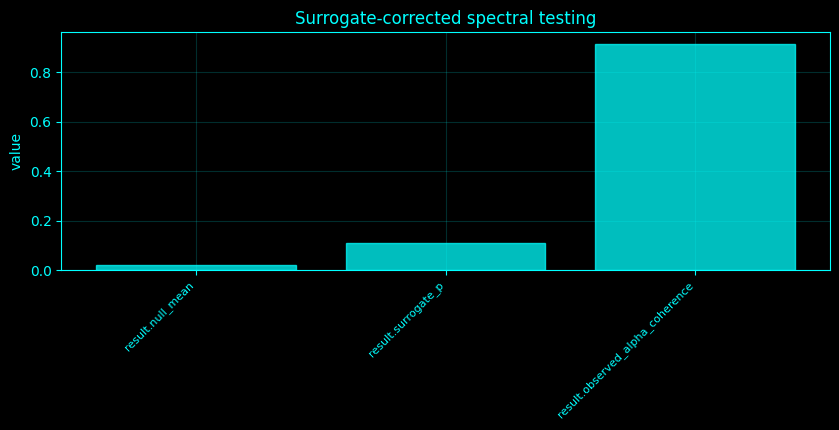

In [142]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _phase_randomize(x, rng):
    xf = np.fft.rfft(x, axis=0)
    ph = rng.uniform(0, 2 * np.pi, size=xf.shape)
    ph[0] = 0
    if x.shape[0] % 2 == 0:
        ph[-1] = 0
    return np.fft.irfft(np.abs(xf) * np.exp(1j * ph), n=x.shape[0], axis=0)

# Method-specific calculation.
def _compute_method_308():
    idx = 308
    name = 'Surrogate-corrected spectral testing'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    obs = _coherence_matrix(BANDS['alpha'])[0, 1] if C > 1 else np.nan
    vals = []
    for _ in range(_SPEED['n_sur']):
        S = _phase_randomize(X, _rng)
        ff, cc = signal.coherence(S[:, 0], S[:, 1], fs=_fs, nperseg=min(_SPEED['nperseg'], N))
        m = (ff >= 8) & (ff < 13)
        vals.append(float(np.mean(cc[m])))
    pval = (1 + np.sum(np.asarray(vals) >= obs)) / (1 + len(vals))
    return ({'observed_alpha_coherence': float(obs), 'surrogate_p': float(pval), 'null_mean': float(np.mean(vals))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_308,_plot_spec=_compute_method_308()
print('Surrogate-corrected spectral testing')
if isinstance(result_308,dict):
    for _k,_v in result_308.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_308)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_308)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Surrogate-corrected spectral testing',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Surrogate-corrected spectral testing',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Surrogate-corrected spectral testing',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">309. Phase-randomized spectral surrogates</h3>
<p>A phase-randomized surrogate keeps \(|X(f)|\) fixed and replaces phase by independent uniform values subject to real-signal symmetry. Its periodogram is therefore preserved up to numerical error.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Phase-randomized spectral surrogates
  relative_psd_error: 2.2355616096712563
  mean_time_series_correlation: -0.14338730596124388


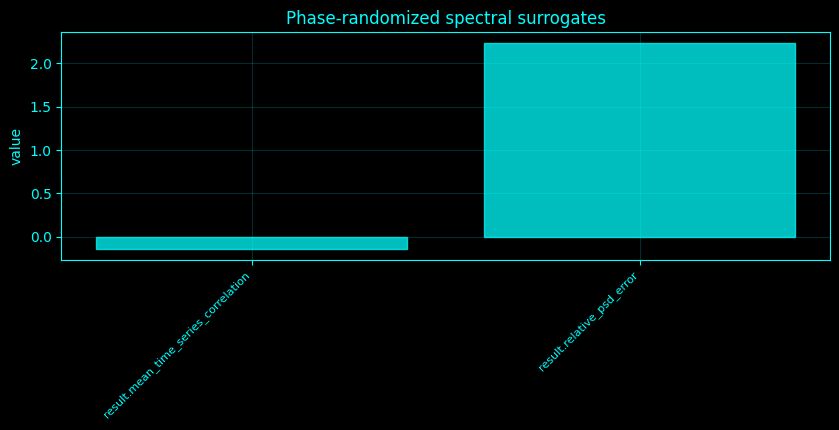

In [143]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _phase_randomize(x, rng):
    xf = np.fft.rfft(x, axis=0)
    ph = rng.uniform(0, 2 * np.pi, size=xf.shape)
    ph[0] = 0
    if x.shape[0] % 2 == 0:
        ph[-1] = 0
    return np.fft.irfft(np.abs(xf) * np.exp(1j * ph), n=x.shape[0], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_309():
    idx = 309
    name = 'Phase-randomized spectral surrogates'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    S = _phase_randomize(X, _rng)
    fs, Ps = _psd_of(S)
    rel = np.linalg.norm(Ps - P) / (np.linalg.norm(P) + EPS)
    corr = np.mean([np.corrcoef(X[:, j], S[:, j])[0, 1] for j in range(C)])
    return ({'relative_psd_error': float(rel), 'mean_time_series_correlation': float(corr)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_309,_plot_spec=_compute_method_309()
print('Phase-randomized spectral surrogates')
if isinstance(result_309,dict):
    for _k,_v in result_309.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_309)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_309)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Phase-randomized spectral surrogates',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Phase-randomized spectral surrogates',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Phase-randomized spectral surrogates',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">310. IAAFT spectral surrogates</h3>
<p>IAAFT alternates between imposing the original Fourier-amplitude spectrum and imposing the original sorted amplitude distribution, approximately preserving both PSD and marginal distribution.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


IAAFT spectral surrogates
  KS_amplitude_distance: 0.0
  relative_psd_error: 5.192063770368677


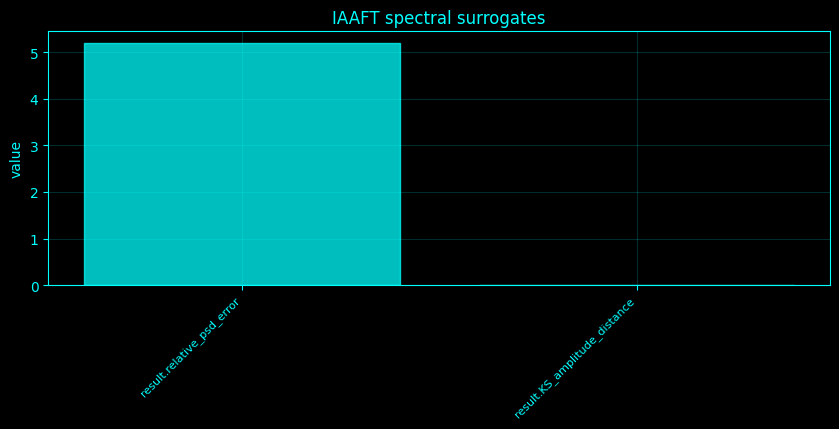

In [144]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _iaaft_1d(x, rng, n_iter=30):
    x = np.asarray(x, float)
    target = np.sort(x)
    amp = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        yf = np.fft.rfft(y)
        y = np.fft.irfft(amp * np.exp(1j * np.angle(yf)), n=len(x))
        order = np.argsort(y)
        z = np.empty_like(y)
        z[order] = target
        y = z
    return y

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_310():
    idx = 310
    name = 'IAAFT spectral surrogates'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    y = _iaaft_1d(X[:, 0], _rng, n_iter=30 if FAST_OPTION == 'ultra' else 60)
    ff, pp = _psd_of(y[:, None])
    ks = stats.ks_2samp(X[:, 0], y).statistic
    spec = np.linalg.norm(pp[:, 0] - P[:, 0]) / (np.linalg.norm(P[:, 0]) + EPS)
    return ({'KS_amplitude_distance': float(ks), 'relative_psd_error': float(spec)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_310,_plot_spec=_compute_method_310()
print('IAAFT spectral surrogates')
if isinstance(result_310,dict):
    for _k,_v in result_310.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_310)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_310)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'IAAFT spectral surrogates',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'IAAFT spectral surrogates',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('IAAFT spectral surrogates',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">311. Shuffle spectral surrogates</h3>
<p>A shuffle surrogate randomly permutes time samples. It preserves the one-point amplitude distribution but destroys temporal autocorrelation and therefore generally flattens the spectrum.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [145]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_311():
    idx = 311
    name = 'Shuffle spectral surrogates'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    S = np.column_stack([_rng.permutation(X[:, j]) for j in range(C)])
    fs, Ps = _psd_of(S)
    return ({'alpha_power_ratio': float(np.mean(_band_integral(Ps, fs, BANDS['alpha'])) / (np.mean(_band_integral(P, f, BANDS['alpha'])) + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_311,_plot_spec=_compute_method_311()
print('Shuffle spectral surrogates')
if isinstance(result_311,dict):
    for _k,_v in result_311.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_311)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_311)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Shuffle spectral surrogates',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Shuffle spectral surrogates',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Shuffle spectral surrogates',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Shuffle spectral surrogates
  alpha_power_ratio: 14.26886050899847


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">312. Colored-noise spectral surrogates</h3>
<p>Colored-noise surrogates are generated with Fourier amplitude proportional to \(f^{-\beta/2}\), giving power \(S(f)\propto f^{-\beta}\) with random phases.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The proportionality symbol means the two quantities are expected to follow the same scaling law up to a multiplicative constant.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [146]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_312():
    idx = 312
    name = 'Colored-noise spectral surrogates'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    m = (f >= 2) & (f <= 45)
    S = np.zeros_like(X)
    for j in range(C):
        coef = np.polyfit(np.log(f[m] + EPS), np.log(P[m, j] + EPS), 1)
        beta = -coef[0]
        fre = np.fft.rfftfreq(N, 1 / _fs)
        amp = (fre + max(fre[1] if len(fre) > 1 else 1, EPS)) ** (-beta / 2)
        ph = _rng.uniform(0, 2 * np.pi, len(fre))
        z = amp * np.exp(1j * ph)
        z[0] = 0
        S[:, j] = np.fft.irfft(z, n=N)
    fs, Ps = _psd_of(S)
    return ({'surrogate_mean_alpha': float(np.mean(_band_integral(Ps, fs, BANDS['alpha'])))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_312,_plot_spec=_compute_method_312()
print('Colored-noise spectral surrogates')
if isinstance(result_312,dict):
    for _k,_v in result_312.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_312)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_312)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Colored-noise spectral surrogates',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Colored-noise spectral surrogates',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Colored-noise spectral surrogates',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Colored-noise spectral surrogates
  surrogate_mean_alpha: 3.108381880264284e-07


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">313. Bootstrap confidence intervals for PSD</h3>
<p>Bootstrap PSD intervals resample approximately independent tapered segments with replacement, recompute their mean periodogram, and use empirical 2.5/97.5 percentiles as pointwise 95% intervals.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Bootstrap analysis estimates sampling uncertainty by repeatedly resampling the available observations and recomputing the statistic. The spread of the resampled statistics shows how sensitive the result is to which observations happened to be included. A bootstrap confidence interval is therefore an empirical uncertainty estimate; it does not remove bias in the original estimator and assumes that the resampling scheme adequately represents the data-generating structure.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Bootstrap confidence intervals for PSD
  n_segments: 51
  median_ci_width: 3.821558201227702e-05


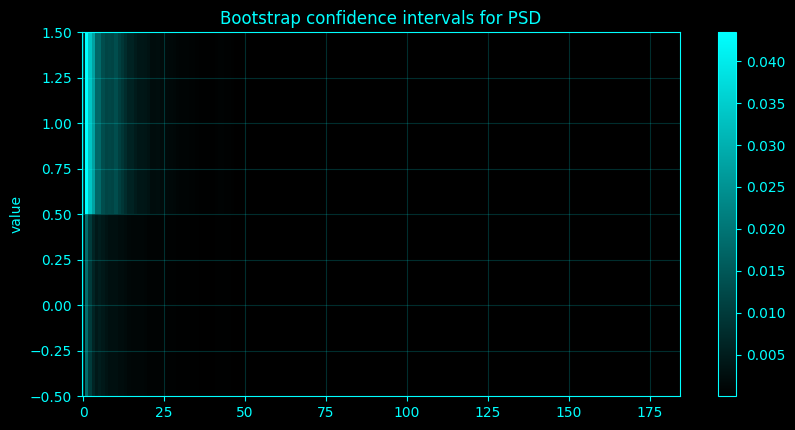

In [147]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_313():
    idx = 313
    name = 'Bootstrap confidence intervals for PSD'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    segs = []
    for a in range(0, N - n + 1, step):
        ff, pp = signal.periodogram(X[a:a + n, 0], fs=_fs, window='hann', scaling='density')
        segs.append(pp)
    segs = np.asarray(segs)
    B = max(50, 5 * _SPEED['n_sur'])
    boots = []
    for _ in range(B):
        boots.append(np.mean(segs[_rng.integers(0, len(segs), len(segs))], axis=0))
    lo, hi = np.percentile(boots, [2.5, 97.5], axis=0)
    m = ff <= 45
    __plot_spec = ('summary', np.vstack([lo[m], hi[m]]), name, None, '', 'value')
    return ({'n_segments': len(segs), 'median_ci_width': float(np.median(hi[m] - lo[m]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_313,_plot_spec=_compute_method_313()
print('Bootstrap confidence intervals for PSD')
if isinstance(result_313,dict):
    for _k,_v in result_313.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_313)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_313)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bootstrap confidence intervals for PSD',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bootstrap confidence intervals for PSD',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bootstrap confidence intervals for PSD',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">314. Bootstrap confidence intervals for coherence</h3>
<p>Bootstrap coherence intervals resample paired Fourier segments so cross- and auto-spectra remain aligned, then recompute \(C_{xy}=|S_{xy}|^2/(S_{xx}S_{yy})\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Bootstrap confidence intervals for coherence
  alpha_coherence_CI95: array(2,), mean=0.914954


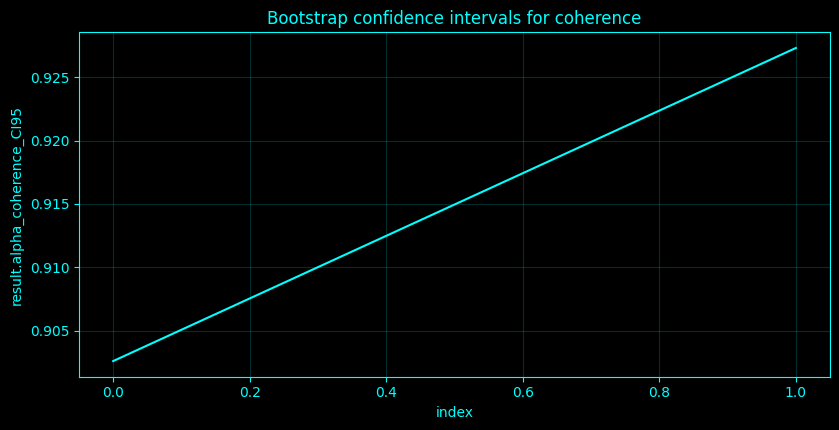

In [148]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_314():
    idx = 314
    name = 'Bootstrap confidence intervals for coherence'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    Xs = []
    Ys = []
    for a in range(0, N - n + 1, step):
        wx = signal.windows.hann(n)
        Xs.append(np.fft.rfft(X[a:a + n, 0] * wx))
        Ys.append(np.fft.rfft(X[a:a + n, 1] * wx))
    Xs = np.asarray(Xs)
    Ys = np.asarray(Ys)
    fre = np.fft.rfftfreq(n, 1 / _fs)
    m = (fre >= 8) & (fre < 13)
    vals = []
    B = max(40, 4 * _SPEED['n_sur'])
    for _ in range(B):
        ii = _rng.integers(0, len(Xs), len(Xs))
        Sxy = np.mean(Xs[ii] * np.conj(Ys[ii]), axis=0)
        Sxx = np.mean(np.abs(Xs[ii]) ** 2, axis=0)
        Syy = np.mean(np.abs(Ys[ii]) ** 2, axis=0)
        coh = np.abs(Sxy) ** 2 / (Sxx * Syy + EPS)
        vals.append(float(np.mean(coh[m])))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return ({'alpha_coherence_CI95': [float(lo), float(hi)]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_314,_plot_spec=_compute_method_314()
print('Bootstrap confidence intervals for coherence')
if isinstance(result_314,dict):
    for _k,_v in result_314.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_314)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_314)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bootstrap confidence intervals for coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bootstrap confidence intervals for coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bootstrap confidence intervals for coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">315. Permutation testing of bandpower</h3>
<p>Permutation testing of bilateral bandpower uses sign flips of paired left-minus-right window differences, which is the exchangeability operation under a symmetric paired null.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Permutation testing of bandpower
  left_minus_right: 0.09840085636777089
  permutation_p: 0.06930693069306931


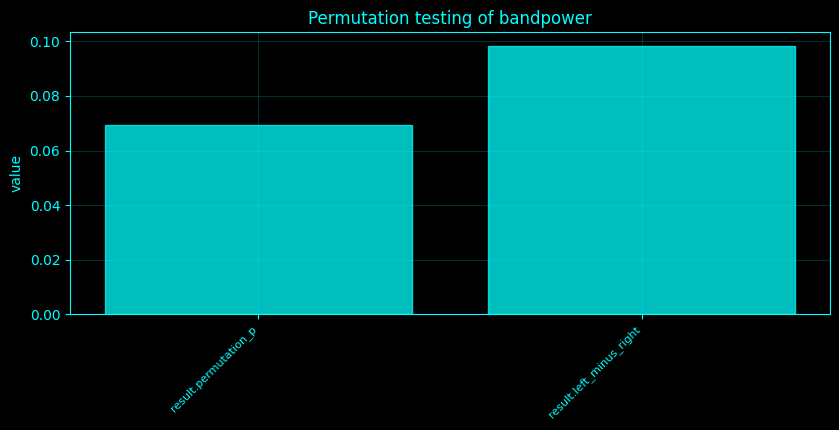

In [149]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

# Method-specific calculation.
def _compute_method_315():
    idx = 315
    name = 'Permutation testing of bandpower'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    t, W = _window_bandpower()
    a = list(BANDS).index('alpha')
    left = [CH_NAMES.index(ch) for ch in LEFT if ch in CH_NAMES]
    right = [CH_NAMES.index(ch) for ch in RIGHT if ch in CH_NAMES]
    if not left or not right:
        return ({'status': 'insufficient bilateral channels'}, locals().get('__plot_spec', None))
    d = np.mean(np.log(W[:, left, a] + EPS), axis=1) - np.mean(np.log(W[:, right, a] + EPS), axis=1)
    obs = float(np.mean(d))
    vals = [float(np.mean(d * _rng.choice([-1, 1], size=len(d)))) for _ in range(max(100, 10 * _SPEED['n_sur']))]
    pval = (1 + np.sum(np.abs(vals) >= abs(obs))) / (1 + len(vals))
    return ({'left_minus_right': obs, 'permutation_p': float(pval)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_315,_plot_spec=_compute_method_315()
print('Permutation testing of bandpower')
if isinstance(result_315,dict):
    for _k,_v in result_315.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_315)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_315)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Permutation testing of bandpower',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Permutation testing of bandpower',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Permutation testing of bandpower',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">316. FDR-corrected spectral significance maps</h3>
<p>Benjamini-Hochberg FDR sorts p-values \(p_{(k)}\) and rejects through the largest \(k\) satisfying \(p_{(k)}\le \alpha k/m\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> When many hypotheses are tested, some small p-values occur by chance. Benjamini-Hochberg false-discovery-rate control ranks the p-values and chooses a threshold designed to limit the expected fraction of false discoveries among the results called significant. FDR control is less strict than controlling the probability of any false positive, which gives it more power in large exploratory analyses. The correction should be applied to a clearly defined family of related tests.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


FDR-corrected spectral significance maps
  discoveries: 56
  BH_cutoff: 0.0010735395711611822


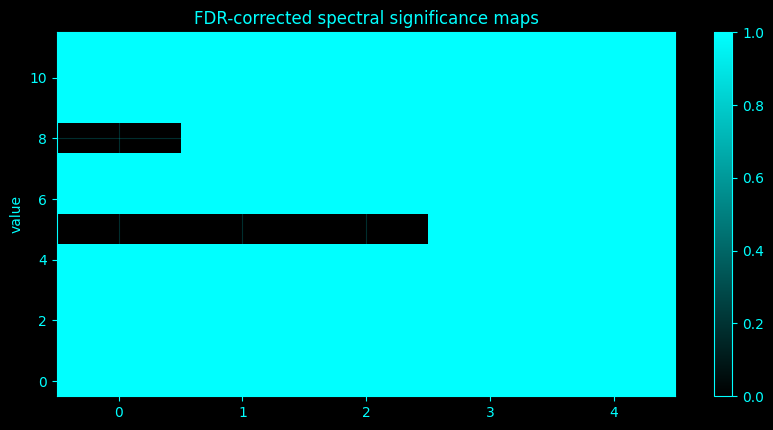

In [150]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _fdr_bh(pvals, alpha=0.05):
    p = np.asarray(pvals, float)
    flat = p.ravel()
    order = np.argsort(flat)
    ranked = flat[order]
    crit = alpha * np.arange(1, len(flat) + 1) / max(len(flat), 1)
    ok = ranked <= crit
    cutoff = ranked[np.max(np.where(ok)[0])] if np.any(ok) else -np.inf
    return (p <= cutoff, cutoff)

# Method-specific calculation.
def _compute_method_316():
    idx = 316
    name = 'FDR-corrected spectral significance maps'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    t, W = _window_bandpower()
    logW = np.log(W + EPS)
    pvals = np.ones((C, len(BANDS)))
    for i in range(C):
        for b in range(len(BANDS)):
            d = logW[:, i, b] - np.mean(logW[:, :, b], axis=1)
            _, p = stats.ttest_1samp(d, 0, nan_policy='omit')
            pvals[i, b] = p
    rej, cut = _fdr_bh(pvals, 0.05)
    __plot_spec = ('summary', rej.astype(float), name, None, '', 'value')
    return ({'discoveries': int(rej.sum()), 'BH_cutoff': float(cut) if np.isfinite(cut) else None}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_316,_plot_spec=_compute_method_316()
print('FDR-corrected spectral significance maps')
if isinstance(result_316,dict):
    for _k,_v in result_316.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_316)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_316)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'FDR-corrected spectral significance maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'FDR-corrected spectral significance maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('FDR-corrected spectral significance maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">317. Cluster-based permutation testing in time-frequency space</h3>
<p>Cluster-based permutation first thresholds a time-frequency statistic, groups adjacent supra-threshold bins, and compares cluster mass with a permutation null. Without real event labels this notebook uses a clearly marked first-half/second-half demonstration rather than calling the split stimulus-locked.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Cluster-based permutation testing in time-frequency space
  pseudo_condition_note: first-half vs second-half, not stimulus labels
  n_clusters: 7
  max_cluster_mass: 1.7593589920014256


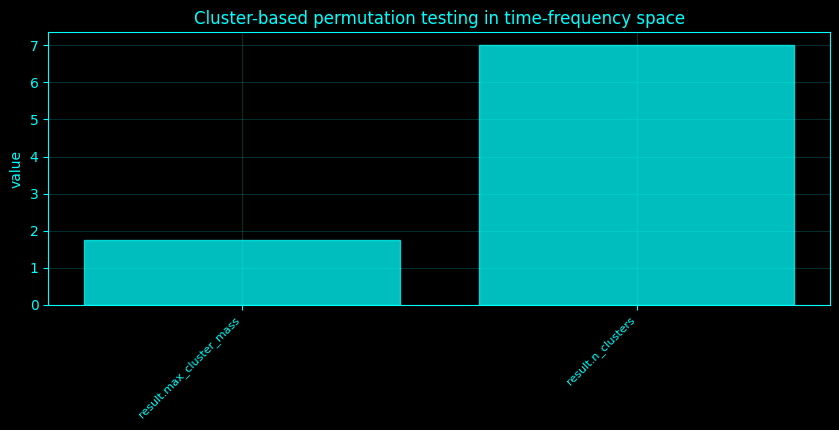

In [151]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

# Method-specific calculation.
def _compute_method_317():
    idx = 317
    name = 'Cluster-based permutation testing in time-frequency space'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    ff, tt, Sp, _ = _stft_summary()
    Z = np.log(Sp[:, 0, :] + EPS)
    mid = Z.shape[1] // 2
    if mid < 3:
        return ({'status': 'too few time bins'}, locals().get('__plot_spec', None))
    d = np.mean(Z[:, :mid], axis=1) - np.mean(Z[:, mid:2 * mid], axis=1)
    obs = np.abs(d)
    null = []
    Y = Z[:, :2 * mid]
    for _ in range(max(50, 5 * _SPEED['n_sur'])):
        perm = _rng.permutation(2 * mid)
        null.append(np.abs(np.mean(Y[:, perm[:mid]], 1) - np.mean(Y[:, perm[mid:]], 1)))
    null = np.asarray(null)
    thr = np.quantile(null, 0.95, axis=0)
    supra = obs > thr
    lab, nlab = ndimage.label(supra.astype(int))
    masses = [float(np.sum(obs[lab == k])) for k in range(1, nlab + 1)]
    return ({'pseudo_condition_note': 'first-half vs second-half, not stimulus labels', 'n_clusters': nlab, 'max_cluster_mass': max(masses) if masses else 0.0}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_317,_plot_spec=_compute_method_317()
print('Cluster-based permutation testing in time-frequency space')
if isinstance(result_317,dict):
    for _k,_v in result_317.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_317)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_317)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cluster-based permutation testing in time-frequency space',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cluster-based permutation testing in time-frequency space',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cluster-based permutation testing in time-frequency space',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">318. Nonparametric spectral confidence intervals</h3>
<p>Nonparametric spectral confidence intervals use empirical percentiles of segment periodograms rather than a parametric chi-square model; they are pointwise finite-sample intervals.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Nonparametric spectral confidence intervals
  n_segments: 51
  median_pointwise_width: 0.0002446304265473511


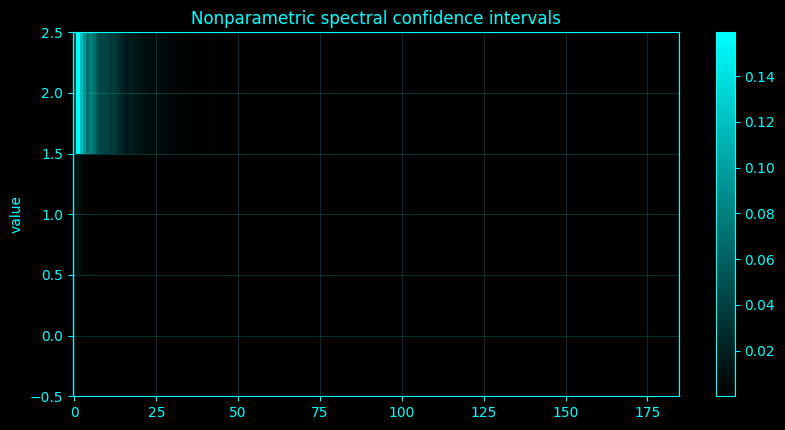

In [152]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_318():
    idx = 318
    name = 'Nonparametric spectral confidence intervals'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    seg = []
    for a in range(0, N - n + 1, step):
        ff, pp = signal.periodogram(X[a:a + n, 0], fs=_fs, window='hann', scaling='density')
        seg.append(pp)
    seg = np.asarray(seg)
    lo, med, hi = np.percentile(seg, [2.5, 50, 97.5], axis=0)
    m = ff <= 45
    __plot_spec = ('summary', np.vstack([lo[m], med[m], hi[m]]), name, None, '', 'value')
    return ({'n_segments': len(seg), 'median_pointwise_width': float(np.median(hi[m] - lo[m]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_318,_plot_spec=_compute_method_318()
print('Nonparametric spectral confidence intervals')
if isinstance(result_318,dict):
    for _k,_v in result_318.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_318)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_318)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Nonparametric spectral confidence intervals',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Nonparametric spectral confidence intervals',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Nonparametric spectral confidence intervals',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">319. Spectral topography</h3>
<p>This cell maps broadband log power onto the fixed electrode coordinates. The topography is a sensor-space visualization; spatial interpolation or plotting does not imply cortical source localization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral topography
  broadband_log_power_range: array(2,), mean=-3.99486


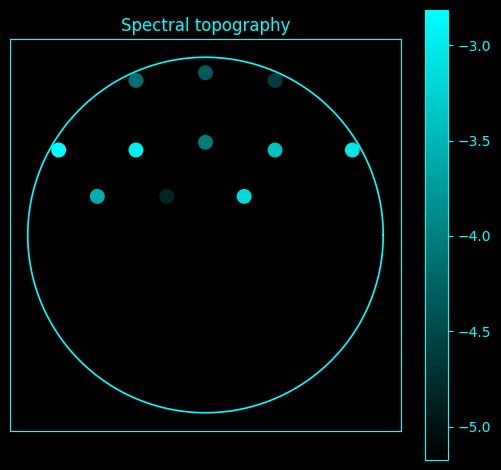

In [153]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_319():
    idx = 319
    name = 'Spectral topography'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    broad = _band_integral(P, f, (2, 45))
    __plot_spec = ('scalp', np.log(broad + EPS), name, None, '', 'value')
    return ({'broadband_log_power_range': [float(np.min(np.log(broad + EPS))), float(np.max(np.log(broad + EPS)))]}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_319,_plot_spec=_compute_method_319()
print('Spectral topography')
if isinstance(result_319,dict):
    for _k,_v in result_319.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_319)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_319)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral topography',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral topography',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral topography',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">320. Bandpower scalp maps</h3>
<p>This cell maps alpha-band log power onto the fixed electrode coordinates. The topography is a sensor-space visualization; spatial interpolation or plotting does not imply cortical source localization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [154]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_320():
    idx = 320
    name = 'Bandpower scalp maps'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    __plot_spec = ('scalp', np.log(BP[:, aidx] + EPS), name, None, '', 'value')
    return ({'band': 'alpha', 'max_channel': CH_NAMES[int(np.argmax(BP[:, aidx]))]}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_320,_plot_spec=_compute_method_320()
print('Bandpower scalp maps')
if isinstance(result_320,dict):
    for _k,_v in result_320.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_320)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_320)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bandpower scalp maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bandpower scalp maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bandpower scalp maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bandpower scalp maps
  band: alpha
  max_channel: FC2


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">321. Aperiodic slope scalp maps</h3>
<p>This cell maps aperiodic exponent onto the fixed electrode coordinates. The topography is a sensor-space visualization; spatial interpolation or plotting does not imply cortical source localization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [1]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_321():
    idx = 321
    name = 'Aperiodic slope scalp maps'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    __plot_spec = ('scalp', slopes, name, None, '', 'value')
    return ({'mean_aperiodic_exponent': float(np.mean(slopes))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_321,_plot_spec=_compute_method_321()
print('Aperiodic slope scalp maps')
if isinstance(result_321,dict):
    for _k,_v in result_321.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_321)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_321)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Aperiodic slope scalp maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Aperiodic slope scalp maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Aperiodic slope scalp maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Aperiodic slope scalp maps
  mean_aperiodic_exponent: 1.3925729879414082


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">322. Peak-frequency scalp maps</h3>
<p>This cell maps dominant peak frequency onto the fixed electrode coordinates. The topography is a sensor-space visualization; spatial interpolation or plotting does not imply cortical source localization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [8]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_322():
    idx = 322
    name = 'Peak-frequency scalp maps'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    __plot_spec = ('scalp', peaks, name, None, '', 'value')
    return ({'mean_peak_hz': float(np.mean(peaks))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_322,_plot_spec=_compute_method_322()
print('Peak-frequency scalp maps')
if isinstance(result_322,dict):
    for _k,_v in result_322.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_322)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_322)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Peak-frequency scalp maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Peak-frequency scalp maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Peak-frequency scalp maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Peak-frequency scalp maps
  mean_peak_hz: 9.3994140625


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">323. Coherence scalp-edge maps</h3>
<p>Coherence scalp-edge maps draw an edge for channel pairs whose alpha-band magnitude-squared coherence exceeds a high quantile. Coherence is \(C_{xy}(f)=|S_{xy}(f)|^2/[S_{xx}(f)S_{yy}(f)]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


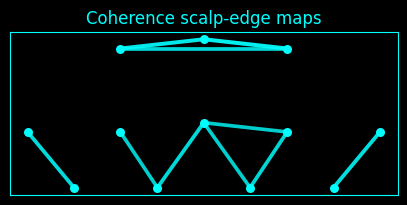

Coherence scalp-edge maps
  threshold: 0.792803233873641
  edges: 10


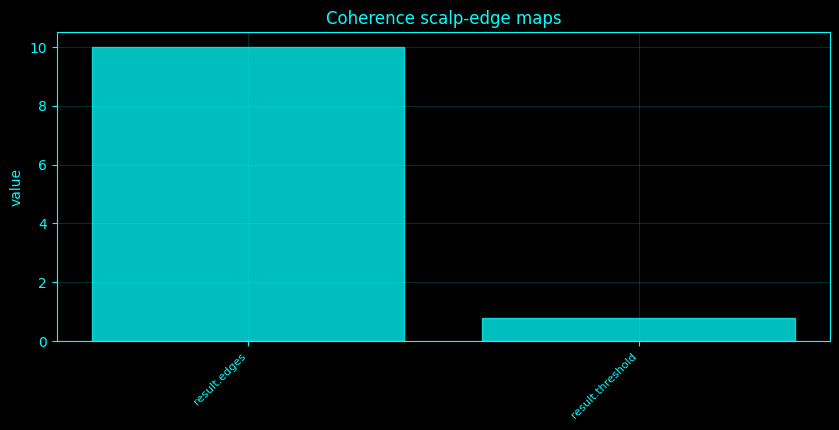

In [29]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_323():
    idx = 323
    name = 'Coherence scalp-edge maps'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    M = _coherence_matrix(BANDS['alpha'], phase=idx == 324)
    xy = np.array([ELECTRODE_XY[ch] for ch in CH_NAMES])
    vals = M[np.triu_indices(C, 1)]
    th = np.quantile(vals, 0.85)
    fig, ax = plt.subplots(figsize=(5, 5))
    for i in range(C):
        for j in range(i + 1, C):
            if M[i, j] >= th:
                ax.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]], color=ACCENT, alpha=float(np.clip(M[i, j], 0.15, 1)), lw=1 + 2 * M[i, j])
    ax.scatter(xy[:, 0], xy[:, 1], c=ACCENT, s=30)
    ax.set_facecolor(BG)
    ax.set_title(name, color=ACCENT)
    ax.tick_params(axis='both', colors=ACCENT)
    ax.grid(False)
    for _spine in ax.spines.values():
        _spine.set_color(ACCENT)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()
    return ({'threshold': float(th), 'edges': int(np.sum(vals >= th))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_323,_plot_spec=_compute_method_323()
print('Coherence scalp-edge maps')
if isinstance(result_323,dict):
    for _k,_v in result_323.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_323)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_323)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Coherence scalp-edge maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Coherence scalp-edge maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Coherence scalp-edge maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">324. PLV scalp-edge maps</h3>
<p>PLV scalp-edge maps threshold \(\mathrm{PLV}=|\langle e^{i(\phi_x-\phi_y)}\rangle|\) and draw the surviving sensor-space edges.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


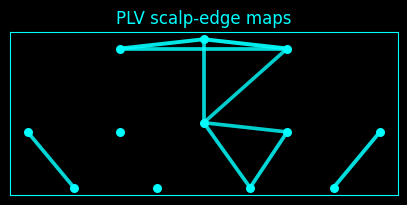

PLV scalp-edge maps
  threshold: 0.8022014846596417
  edges: 10


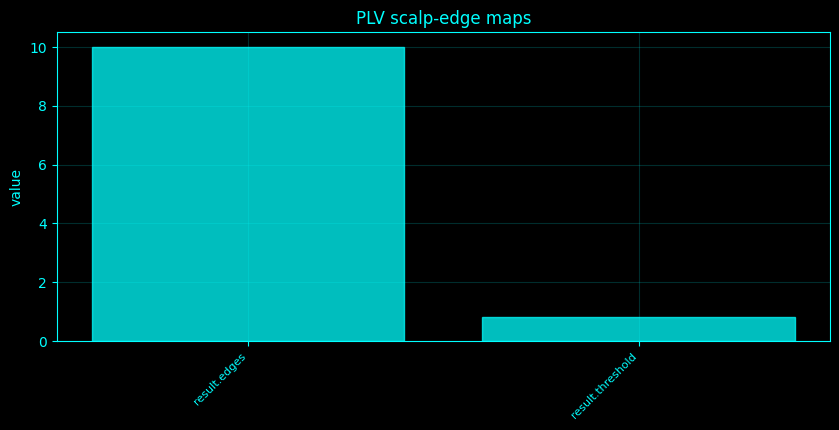

In [30]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_324():
    idx = 324
    name = 'PLV scalp-edge maps'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    M = _coherence_matrix(BANDS['alpha'], phase=idx == 324)
    xy = np.array([ELECTRODE_XY[ch] for ch in CH_NAMES])
    vals = M[np.triu_indices(C, 1)]
    th = np.quantile(vals, 0.85)
    fig, ax = plt.subplots(figsize=(5, 5))
    for i in range(C):
        for j in range(i + 1, C):
            if M[i, j] >= th:
                ax.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]], color=ACCENT, alpha=float(np.clip(M[i, j], 0.15, 1)), lw=1 + 2 * M[i, j])
    ax.scatter(xy[:, 0], xy[:, 1], c=ACCENT, s=30)
    ax.set_facecolor(BG)
    ax.set_title(name, color=ACCENT)
    ax.tick_params(axis='both', colors=ACCENT)
    ax.grid(False)
    for _spine in ax.spines.values():
        _spine.set_color(ACCENT)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()
    return ({'threshold': float(th), 'edges': int(np.sum(vals >= th))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_324,_plot_spec=_compute_method_324()
print('PLV scalp-edge maps')
if isinstance(result_324,dict):
    for _k,_v in result_324.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_324)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_324)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'PLV scalp-edge maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'PLV scalp-edge maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('PLV scalp-edge maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">325. PAC scalp maps</h3>
<p>This cell maps theta-phase/gamma-amplitude coupling onto the fixed electrode coordinates. The topography is a sensor-space visualization; spatial interpolation or plotting does not imply cortical source localization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [31]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_325():
    idx = 325
    name = 'PAC scalp maps'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    low = _analytic_band(BANDS['theta'])
    high = _analytic_band(BANDS['gamma'])
    phase = np.angle(low)
    amp = np.abs(high)
    pac = np.abs(np.mean(amp / (np.mean(amp, axis=0) + EPS) * np.exp(1j * phase), axis=0))
    __plot_spec = ('scalp', pac, name, None, '', 'value')
    return ({'max_PAC_channel': CH_NAMES[int(np.argmax(pac))]}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_325,_plot_spec=_compute_method_325()
print('PAC scalp maps')
if isinstance(result_325,dict):
    for _k,_v in result_325.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_325)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_325)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'PAC scalp maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'PAC scalp maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('PAC scalp maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


PAC scalp maps
  max_PAC_channel: Fp2


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">326. Spectral asymmetry topographies</h3>
<p>This cell maps bilateral log-power asymmetry onto the fixed electrode coordinates. The topography is a sensor-space visualization; spatial interpolation or plotting does not imply cortical source localization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [32]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_326():
    idx = 326
    name = 'Spectral asymmetry topographies'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    vals = np.zeros(C)
    alpha = np.log(BP[:, aidx] + EPS)
    pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('C3', 'C4'), ('P3', 'P4'), ('O1', 'O2')]
    for l, r in pairs:
        if l in CH_NAMES and r in CH_NAMES:
            il, ir = (CH_NAMES.index(l), CH_NAMES.index(r))
            d = alpha[il] - alpha[ir]
            vals[il] = d
            vals[ir] = -d
    __plot_spec = ('scalp', vals, name, None, '', 'value')
    return ({'max_abs_asymmetry': float(np.max(np.abs(vals)))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_326,_plot_spec=_compute_method_326()
print('Spectral asymmetry topographies')
if isinstance(result_326,dict):
    for _k,_v in result_326.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_326)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_326)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral asymmetry topographies',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral asymmetry topographies',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral asymmetry topographies',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral asymmetry topographies
  max_abs_asymmetry: 0.46309877663285093


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">327. Regional spectral summaries</h3>
<p>Regional spectral summaries average channel-level spectral descriptors within predefined frontal, central, and posterior sensor groups. The averaging is descriptive and does not create source-space regions.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Regional spectral summaries
  frontal: {'alpha': 0.0040352280235983, 'slope': 1.6226703901705772, 'peak_hz': 8.382161458333334}


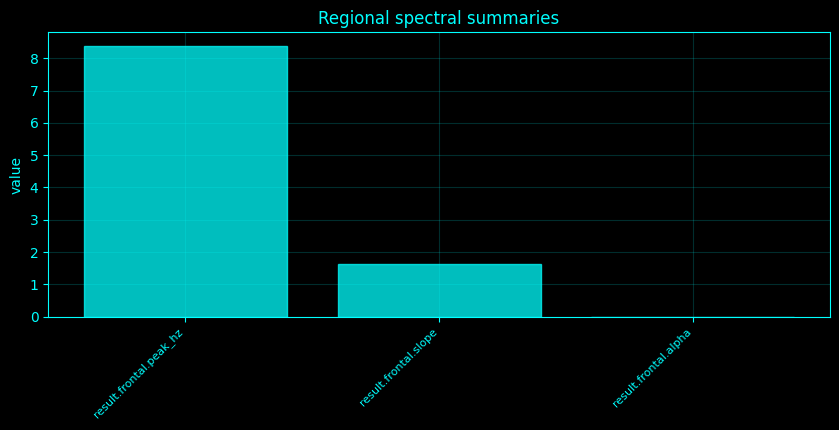

In [33]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_327():
    idx = 327
    name = 'Regional spectral summaries'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    rows = {}
    for roi, chans in ROI.items():
        ii = [CH_NAMES.index(ch) for ch in chans if ch in CH_NAMES]
        if ii:
            rows[roi] = {'alpha': float(np.mean(BP[ii, aidx])), 'slope': float(np.mean(slopes[ii])), 'peak_hz': float(np.mean(peaks[ii]))}
    return (rows, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_327,_plot_spec=_compute_method_327()
print('Regional spectral summaries')
if isinstance(result_327,dict):
    for _k,_v in result_327.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_327)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_327)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Regional spectral summaries',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Regional spectral summaries',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Regional spectral summaries',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">328. Spectral channel fingerprints</h3>
<p>A channel fingerprint concatenates standardized log bandpowers, aperiodic exponent, dominant peak frequency, and spectral entropy into a multivariate feature vector for each channel.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Spectral entropy treats the normalized power spectrum as a probability distribution over frequency bins and applies Shannon entropy to that distribution. If power is concentrated in only a few frequencies, the distribution is uneven and entropy is low. If power is spread broadly across many frequencies, entropy is higher. The result therefore describes spectral dispersion, not temporal unpredictability in exactly the same sense as Sample Entropy or permutation entropy.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral channel fingerprints
  fingerprint_shape: array(2,), mean=10


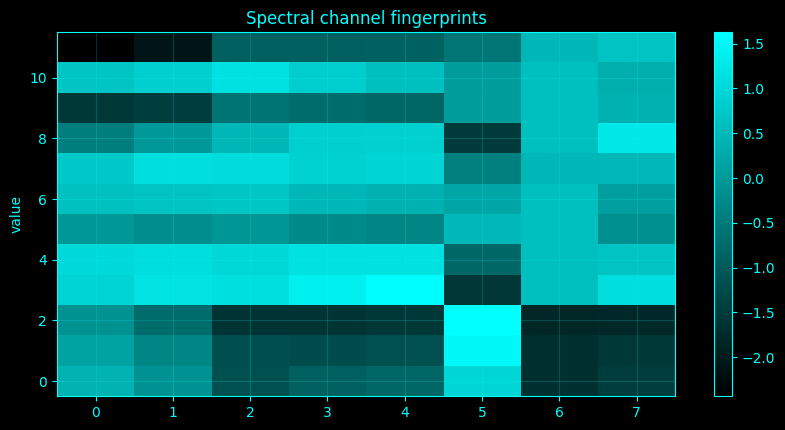

In [34]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_328():
    idx = 328
    name = 'Spectral channel fingerprints'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    __plot_spec = ('summary', F, name, None, '', 'value')
    return ({'fingerprint_shape': F.shape}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_328,_plot_spec=_compute_method_328()
print('Spectral channel fingerprints')
if isinstance(result_328,dict):
    for _k,_v in result_328.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_328)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_328)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral channel fingerprints',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral channel fingerprints',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral channel fingerprints',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">329. Spectral clustering of channels</h3>
<p>Spectral clustering of channels applies k-means to standardized spectral fingerprints, minimizing within-cluster squared Euclidean distance \(\sum_i\|x_i-\mu_{c_i}\|^2\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [35]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_329():
    idx = 329
    name = 'Spectral clustering of channels'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    k = min(4, max(2, C // 4))
    labels = KMeans(k, n_init=20, random_state=0).fit_predict(F)
    return ({'clusters': {int(q): [CH_NAMES[i] for i in np.where(labels == q)[0]] for q in np.unique(labels)}}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_329,_plot_spec=_compute_method_329()
print('Spectral clustering of channels')
if isinstance(result_329,dict):
    for _k,_v in result_329.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_329)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_329)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral clustering of channels',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral clustering of channels',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral clustering of channels',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral clustering of channels
  clusters: {0: ['F7', 'F3', 'F4', 'F8', 'FC5', 'FC2'], 1: ['Fp1', 'Fpz', 'Fp2'], 2: ['Fz', 'FC1', 'FC6']}


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">330. Spectral PCA/UMAP embeddings</h3>
<p>PCA projects fingerprints onto orthogonal directions maximizing variance. If `umap-learn` is installed, UMAP is additionally computed as a nonlinear neighbourhood embedding; otherwise the notebook explicitly retains PCA only.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Spectral PCA/UMAP embeddings
  PCA_explained_variance: array(2,), mean=0.482761
  UMAP_shape: array(2,), mean=7


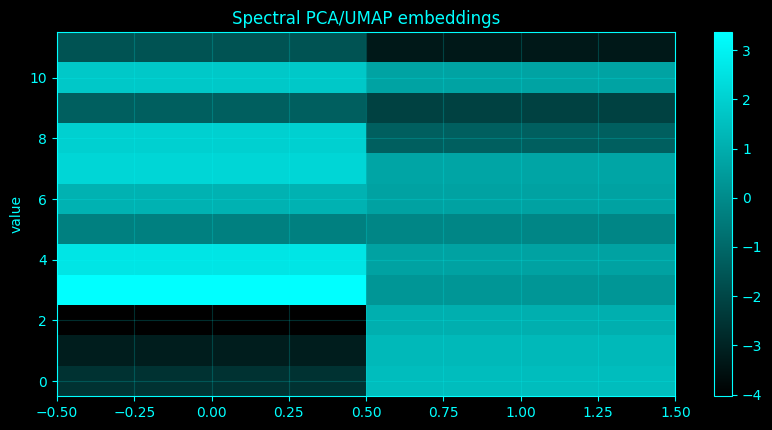

In [36]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_330():
    idx = 330
    name = 'Spectral PCA/UMAP embeddings'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    pca = PCA(n_components=min(2, F.shape[1], C)).fit_transform(F)
    out = {'PCA_explained_variance': PCA(n_components=min(2, F.shape[1], C)).fit(F).explained_variance_ratio_.tolist()}
    try:
        import umap
        emb = umap.UMAP(n_components=2, random_state=0, n_neighbors=min(10, C - 1)).fit_transform(F)
        out['UMAP_shape'] = emb.shape
    except Exception:
        out['UMAP_status'] = 'optional umap-learn package not installed; PCA result retained'
    __plot_spec = ('summary', pca, name, None, '', 'value')
    return (out, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_330,_plot_spec=_compute_method_330()
print('Spectral PCA/UMAP embeddings')
if isinstance(result_330,dict):
    for _k,_v in result_330.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_330)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_330)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral PCA/UMAP embeddings',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral PCA/UMAP embeddings',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral PCA/UMAP embeddings',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">331. Spectral distance matrices</h3>
<p>The spectral distance matrix contains Euclidean distances between standardized channel fingerprints, \(d_{ij}=\|z_i-z_j\|_2\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [37]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_331():
    idx = 331
    name = 'Spectral distance matrices'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    D = pairwise_distances(F, metric='euclidean')
    __plot_spec = ('summary', D, name, None, '', 'value')
    return ({'mean_distance': float(np.mean(D[np.triu_indices(C, 1)]))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_331,_plot_spec=_compute_method_331()
print('Spectral distance matrices')
if isinstance(result_331,dict):
    for _k,_v in result_331.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_331)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_331)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral distance matrices',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral distance matrices',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral distance matrices',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral distance matrices
  mean_distance: 3.769735056324824


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">332. Spectrogram clustering</h3>
<p>Spectrogram state analysis treats each time column of the log spectrogram as a frequency-profile vector. k-means partitions these vectors; centroids are spectral archetypes and the time-ordered labels form a discrete state sequence.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectrogram clustering
  states: 5
  counts: array(5,), mean=10.2


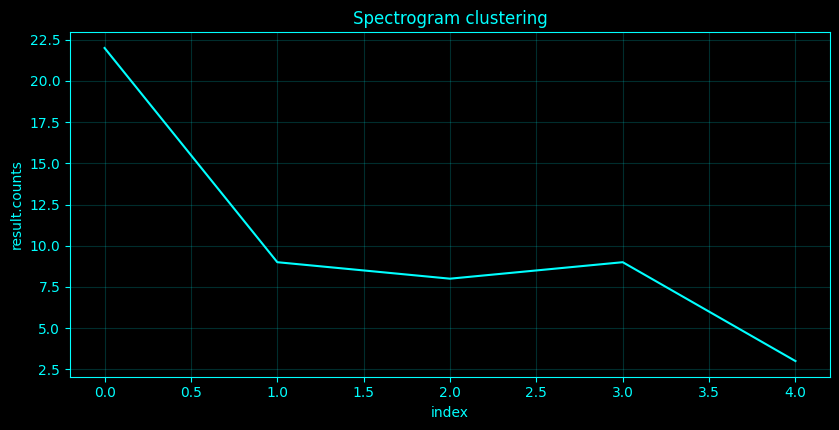

In [38]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_332():
    idx = 332
    name = 'Spectrogram clustering'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    k = min(5, max(2, len(Qs) // 8))
    lab = KMeans(k, n_init=20, random_state=0).fit_predict(Qs)
    return ({'states': k, 'counts': np.bincount(lab).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_332,_plot_spec=_compute_method_332()
print('Spectrogram clustering')
if isinstance(result_332,dict):
    for _k,_v in result_332.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_332)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_332)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectrogram clustering',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectrogram clustering',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectrogram clustering',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">333. Spectrogram archetypes</h3>
<p>Spectrogram state analysis treats each time column of the log spectrogram as a frequency-profile vector. k-means partitions these vectors; centroids are spectral archetypes and the time-ordered labels form a discrete state sequence.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [39]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_333():
    idx = 333
    name = 'Spectrogram archetypes'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    k = min(5, max(2, len(Qs) // 8))
    km = KMeans(k, n_init=20, random_state=0).fit(Qs)
    __plot_spec = ('summary', km.cluster_centers_, name, None, '', 'value')
    return ({'archetypes': km.cluster_centers_.shape[0]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_333,_plot_spec=_compute_method_333()
print('Spectrogram archetypes')
if isinstance(result_333,dict):
    for _k,_v in result_333.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_333)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_333)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectrogram archetypes',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectrogram archetypes',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectrogram archetypes',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectrogram archetypes
  archetypes: 5


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">334. Spectrogram state segmentation</h3>
<p>Spectrogram state analysis treats each time column of the log spectrogram as a frequency-profile vector. k-means partitions these vectors; centroids are spectral archetypes and the time-ordered labels form a discrete state sequence.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [40]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_334():
    idx = 334
    name = 'Spectrogram state segmentation'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    k = min(5, max(2, len(Qs) // 8))
    lab = KMeans(k, n_init=20, random_state=0).fit_predict(Qs)
    __plot_spec = ('summary', lab, name, tt, 'time (s)', 'state')
    return ({'transitions': int(np.sum(np.diff(lab) != 0))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_334,_plot_spec=_compute_method_334()
print('Spectrogram state segmentation')
if isinstance(result_334,dict):
    for _k,_v in result_334.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_334)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_334)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectrogram state segmentation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectrogram state segmentation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectrogram state segmentation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectrogram state segmentation
  transitions: 32


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">335. Spectrogram change-point detection</h3>
<p>A spectrogram change score is the Euclidean norm of the difference between adjacent standardized spectral-state vectors, \(d_t=\|z_t-z_{t-1}\|_2\). High-quantile values are finite-sample change-point candidates.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectrogram change-point detection
  change_points_sec: array(6,), mean=38.5707


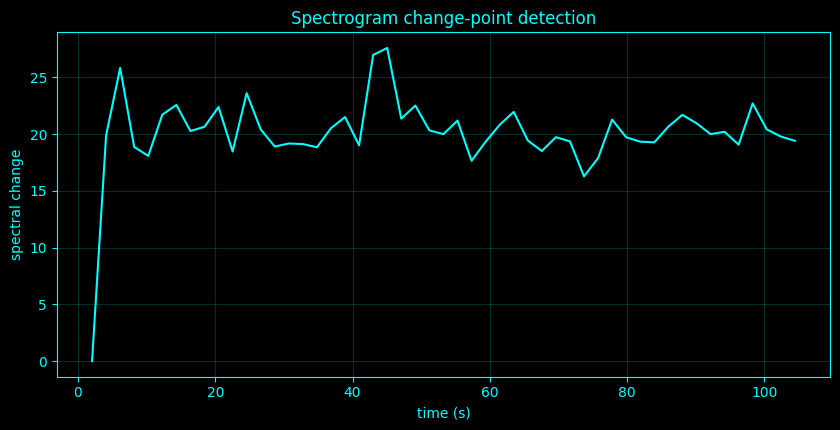

In [41]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_335():
    idx = 335
    name = 'Spectrogram change-point detection'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    d = np.r_[0, np.linalg.norm(np.diff(Qs, axis=0), axis=1)]
    th = np.quantile(d, 0.9)
    cp = np.where(d >= th)[0]
    __plot_spec = ('summary', d, name, tt, 'time (s)', 'spectral change')
    return ({'change_points_sec': tt[cp].tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_335,_plot_spec=_compute_method_335()
print('Spectrogram change-point detection')
if isinstance(result_335,dict):
    for _k,_v in result_335.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_335)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_335)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectrogram change-point detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectrogram change-point detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectrogram change-point detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">336. Spectrogram recurrence analysis</h3>
<p>A recurrence matrix is \(R_{ij}=\mathbf 1[d(z_i,z_j)\le\varepsilon]\). The threshold is chosen from a lower distance quantile, and the recurrence rate is the fraction of recurrent pairs.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Recurrence analysis compares pairs of reconstructed states and marks them as recurrent when their distance is below a chosen threshold. The recurrence rate is simply the fraction of state pairs that satisfy this condition. Diagonal line structures indicate that similar state sequences evolve in similar ways for several steps, which motivates determinism-related measures. Vertical line structures indicate that the trajectory stays near a region of state space for several samples, which motivates laminarity-related measures. These quantities depend on embedding choices, distance scaling, and the recurrence threshold, so those settings should be held consistent when channels are compared.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [42]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_336():
    idx = 336
    name = 'Spectrogram recurrence analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    D = pairwise_distances(Qs)
    th = np.quantile(D[np.triu_indices(len(D), 1)], 0.15)
    R = (D <= th).astype(float)
    __plot_spec = ('summary', R, name, None, '', 'value')
    return ({'recurrence_rate': float(np.mean(R))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_336,_plot_spec=_compute_method_336()
print('Spectrogram recurrence analysis')
if isinstance(result_336,dict):
    for _k,_v in result_336.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_336)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_336)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectrogram recurrence analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectrogram recurrence analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectrogram recurrence analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectrogram recurrence analysis
  recurrence_rate: 0.16724336793540945


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">337. Spectrogram similarity matrices</h3>
<p>Spectrogram similarity uses cosine similarity \(s_{ij}=z_i^\top z_j/(\|z_i\|\|z_j\|)\) between time-resolved spectral profiles.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [43]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_337():
    idx = 337
    name = 'Spectrogram similarity matrices'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    Qn = Qs / (np.linalg.norm(Qs, axis=1, keepdims=True) + EPS)
    Simi = np.clip(Qn @ Qn.T, -1, 1)
    __plot_spec = ('summary', Simi, name, None, '', 'value')
    return ({'mean_similarity': float(np.mean(Simi[np.triu_indices(len(Simi), 1)]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_337,_plot_spec=_compute_method_337()
print('Spectrogram similarity matrices')
if isinstance(result_337,dict):
    for _k,_v in result_337.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_337)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_337)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectrogram similarity matrices',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectrogram similarity matrices',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectrogram similarity matrices',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectrogram similarity matrices
  mean_similarity: -0.019290651339135326


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">338. Spectrogram dictionary learning</h3>
<p>Dictionary learning approximates spectrogram states as sparse linear combinations \(Z\approx DA\), estimating reusable spectral atoms under a sparsity-promoting code.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectrogram dictionary learning
  dictionary_atoms: 4
  reconstruction_error: 4664.731352365888


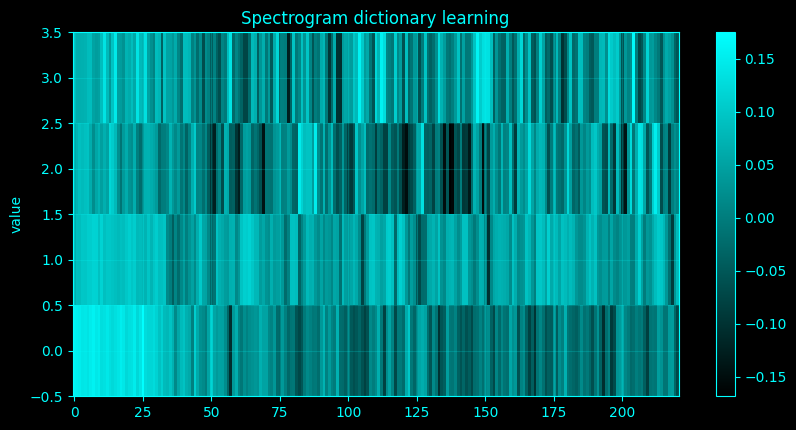

In [44]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_338():
    idx = 338
    name = 'Spectrogram dictionary learning'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    ncomp = min(_SPEED['rank'], max(2, min(Qs.shape) - 1))
    mdl = DictionaryLearning(n_components=ncomp, random_state=0, max_iter=200, transform_algorithm='lasso_lars').fit(Qs)
    __plot_spec = ('summary', mdl.components_, name, None, '', 'value')
    return ({'dictionary_atoms': ncomp, 'reconstruction_error': float(mdl.error_[-1]) if len(mdl.error_) else np.nan}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_338,_plot_spec=_compute_method_338()
print('Spectrogram dictionary learning')
if isinstance(result_338,dict):
    for _k,_v in result_338.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_338)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_338)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectrogram dictionary learning',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectrogram dictionary learning',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectrogram dictionary learning',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">339. Nonnegative matrix factorization of spectrograms</h3>
<p>Nonnegative matrix factorization decomposes a shifted nonnegative spectrogram \(V\approx WH\), with \(W,H\ge0\), producing additive spectral components.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Nonnegative matrix factorization of spectrograms
  rank: 4
  relative_error: 0.13100557566250656


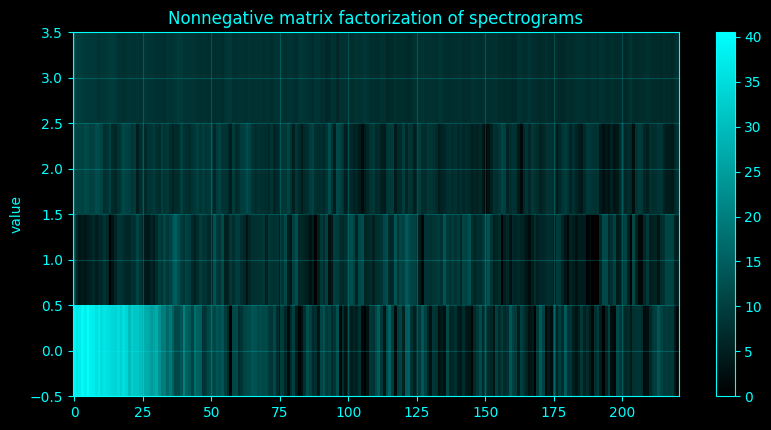

In [45]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_339():
    idx = 339
    name = 'Nonnegative matrix factorization of spectrograms'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    V = np.maximum(Q - Q.min() + EPS, 0)
    r = min(_SPEED['rank'], max(2, min(V.shape) - 1))
    mdl = NMF(n_components=r, init='nndsvda', random_state=0, max_iter=500).fit(V)
    R = mdl.transform(V) @ mdl.components_
    __plot_spec = ('summary', mdl.components_, name, None, '', 'value')
    return ({'rank': r, 'relative_error': float(np.linalg.norm(V - R) / (np.linalg.norm(V) + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_339,_plot_spec=_compute_method_339()
print('Nonnegative matrix factorization of spectrograms')
if isinstance(result_339,dict):
    for _k,_v in result_339.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_339)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_339)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Nonnegative matrix factorization of spectrograms',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Nonnegative matrix factorization of spectrograms',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Nonnegative matrix factorization of spectrograms',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">340. Independent component analysis of spectra</h3>
<p>Spectral ICA seeks statistically independent components of channel spectra after whitening. FastICA maximizes a non-Gaussianity contrast rather than variance alone.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [46]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_340():
    idx = 340
    name = 'Independent component analysis of spectra'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    Xspec = np.log(P + EPS).T
    r = min(_SPEED['rank'], C - 1, Xspec.shape[1])
    ica = FastICA(n_components=max(1, r), random_state=0, max_iter=1000, whiten='unit-variance').fit(Xspec)
    __plot_spec = ('summary', ica.components_, name, None, '', 'value')
    return ({'components': ica.components_.shape[0]}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_340,_plot_spec=_compute_method_340()
print('Independent component analysis of spectra')
if isinstance(result_340,dict):
    for _k,_v in result_340.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_340)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_340)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Independent component analysis of spectra',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Independent component analysis of spectra',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Independent component analysis of spectra',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Independent component analysis of spectra
  components: 4


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">341. Spectral topic modeling</h3>
<p>Spectral topic modeling applies latent Dirichlet allocation to nonnegative discretized spectrogram counts, treating time windows as documents and frequency bins as terms. It is a descriptive probabilistic factorization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Spectral topic modeling
  topics: 4
  perplexity: 220.85936911725153


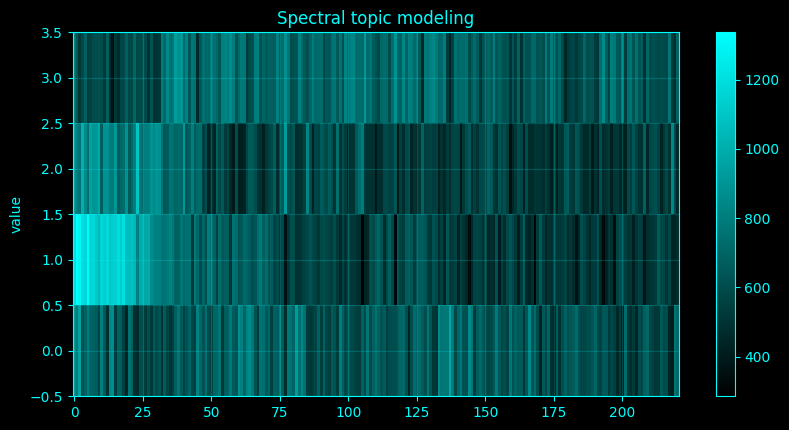

In [47]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_341():
    idx = 341
    name = 'Spectral topic modeling'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    V = Q - Q.min() + EPS
    scale = 50 / (np.mean(V) + EPS)
    counts = np.maximum(np.round(V * scale), 0).astype(int)
    r = min(_SPEED['rank'], max(2, min(counts.shape) - 1))
    lda = LatentDirichletAllocation(n_components=r, random_state=0, max_iter=30, learning_method='batch').fit(counts)
    __plot_spec = ('summary', lda.components_, name, None, '', 'value')
    return ({'topics': r, 'perplexity': float(lda.perplexity(counts))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_341,_plot_spec=_compute_method_341()
print('Spectral topic modeling')
if isinstance(result_341,dict):
    for _k,_v in result_341.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_341)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_341)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral topic modeling',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral topic modeling',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral topic modeling',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">342. Low-rank spectrogram decomposition</h3>
<p>Low-rank spectrogram decomposition uses the truncated SVD \(Z_r=U_r\Sigma_rV_r^\top\), the optimal rank-\(r\) approximation in Frobenius norm.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Low-rank spectrogram decomposition
  rank: 4
  variance_fraction: 0.24267210924888272
  relative_error: 0.8702458794795312


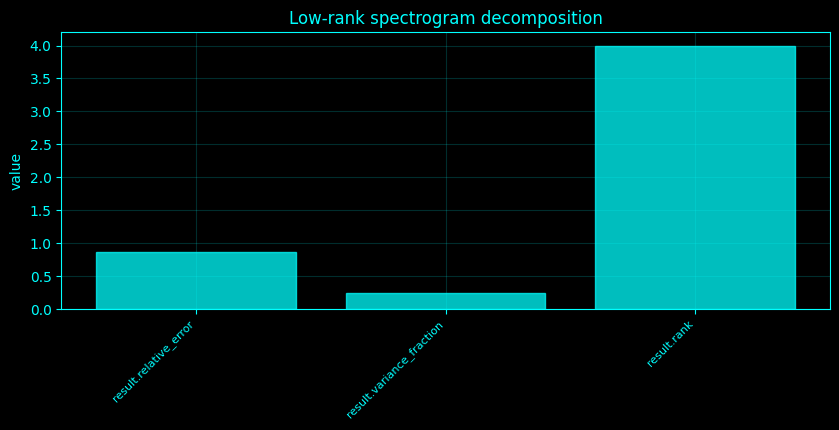

In [48]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_342():
    idx = 342
    name = 'Low-rank spectrogram decomposition'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    F, slopes, peaks, ent = _spectral_features()
    aidx = list(BANDS).index('alpha')
    _, BP = _bandpower_matrix()
    ff, tt, S, _ = _stft_summary()
    Q = np.log(S[:, 0, :] + EPS).T
    Qs = (Q - Q.mean(0)) / (Q.std(0) + EPS)
    U, s, Vh = np.linalg.svd(Qs, full_matrices=False)
    r = min(_SPEED['rank'], len(s))
    R = U[:, :r] * s[:r] @ Vh[:r]
    return ({'rank': r, 'variance_fraction': float(np.sum(s[:r] ** 2) / (np.sum(s ** 2) + EPS)), 'relative_error': float(np.linalg.norm(Qs - R) / (np.linalg.norm(Qs) + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_342,_plot_spec=_compute_method_342()
print('Low-rank spectrogram decomposition')
if isinstance(result_342,dict):
    for _k,_v in result_342.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_342)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_342)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Low-rank spectrogram decomposition',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Low-rank spectrogram decomposition',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Low-rank spectrogram decomposition',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">343. Harmonic-to-noise ratio</h3>
<p>Harmonic-to-noise ratio compares power at integer multiples of the dominant fundamental with remaining in-band power: \(HNR=10\log_{10}(P_{harm}/P_{noise})\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Harmonic-to-noise ratio
  fundamental_hz: 10.498046875
  harmonic_to_noise_ratio_db: -14.7119145296315


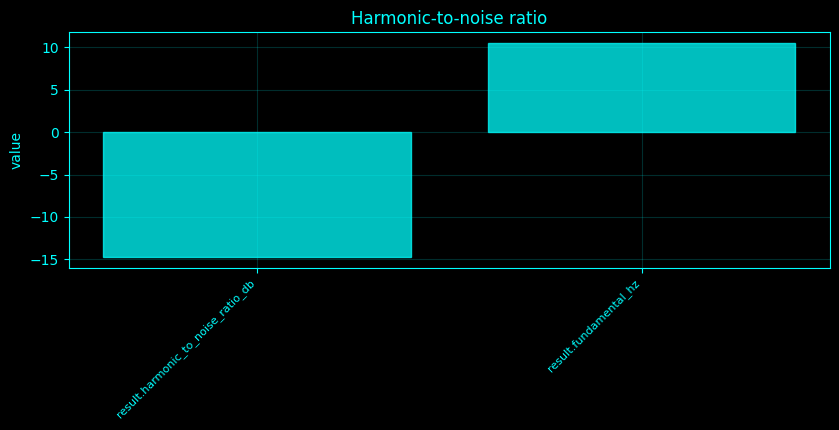

In [49]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_343():
    idx = 343
    name = 'Harmonic-to-noise ratio'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    harmonics = []
    for n in range(1, 6):
        fh = n * f0
        if fh > f[-1]:
            break
        harmonics.append(np.abs(f - fh).argmin())
    harm_power = np.sum(p[harmonics])
    mask = (f >= 2) & (f <= 45)
    noise = np.sum(p[mask]) - harm_power
    return ({'fundamental_hz': f0, 'harmonic_to_noise_ratio_db': float(10 * np.log10((harm_power + EPS) / (noise + EPS)))}, locals().get('__plot_spec', None))
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_343,_plot_spec=_compute_method_343()
print('Harmonic-to-noise ratio')
if isinstance(result_343,dict):
    for _k,_v in result_343.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_343)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_343)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Harmonic-to-noise ratio',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Harmonic-to-noise ratio',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Harmonic-to-noise ratio',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">344. Subharmonic detection</h3>
<p>Subharmonic detection tests for excess spectral power near \(f_0/2\) relative to its local spectral background.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Subharmonic detection
  subharmonic_hz: 5.126953125
  subharmonic_to_local_median: 0.9867533216554233


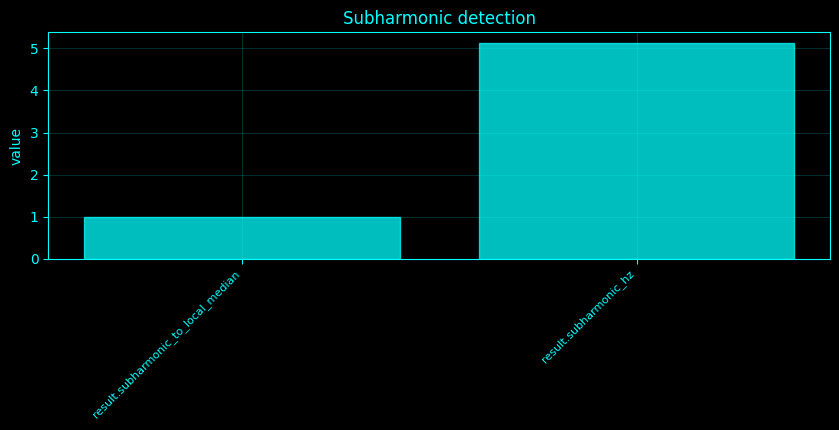

In [50]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_344():
    idx = 344
    name = 'Subharmonic detection'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    target = f0 / 2
    k = np.argmin(np.abs(f - target))
    local = (f >= max(1, target - 1)) & (f <= target + 1)
    bg = np.median(p[local]) if np.any(local) else np.median(p)
    return ({'subharmonic_hz': float(f[k]), 'subharmonic_to_local_median': float(p[k] / (bg + EPS))}, locals().get('__plot_spec', None))
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_344,_plot_spec=_compute_method_344()
print('Subharmonic detection')
if isinstance(result_344,dict):
    for _k,_v in result_344.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_344)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_344)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Subharmonic detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Subharmonic detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Subharmonic detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">345. Interharmonic detection</h3>
<p>Interharmonics are peaks not close to integer multiples of the fundamental. The cell reports their frequency offsets from the nearest harmonic grid.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Interharmonic detection
  n_peaks: 2
  median_interharmonic_offset_hz: 4.0283203125


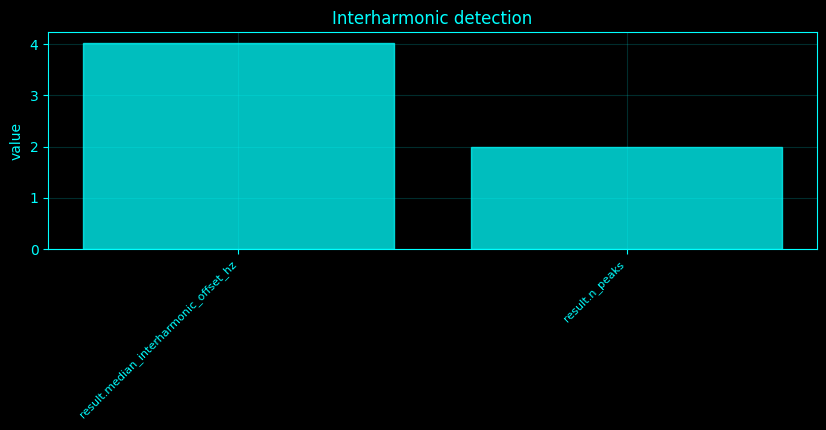

In [51]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_345():
    idx = 345
    name = 'Interharmonic detection'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    peaks = pf[(pf >= 2) & (pf <= 45)]
    residual = []
    for q in peaks:
        n = max(1, round(q / f0))
        residual.append(min(abs(q - n * f0), abs(q - (n + 0.5) * f0)))
    return ({'n_peaks': len(peaks), 'median_interharmonic_offset_hz': float(np.median(residual)) if residual else np.nan}, locals().get('__plot_spec', None))
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_345,_plot_spec=_compute_method_345()
print('Interharmonic detection')
if isinstance(result_345,dict):
    for _k,_v in result_345.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_345)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_345)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Interharmonic detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Interharmonic detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Interharmonic detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">346. Harmonic stability analysis</h3>
<p>Harmonic stability tracks the dominant 4–30-Hz peak across windows and summarizes its temporal standard deviation.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Harmonic stability analysis
  mean_peak_hz: 8.219835421984993
  peak_sd_hz: 3.9594046943937937


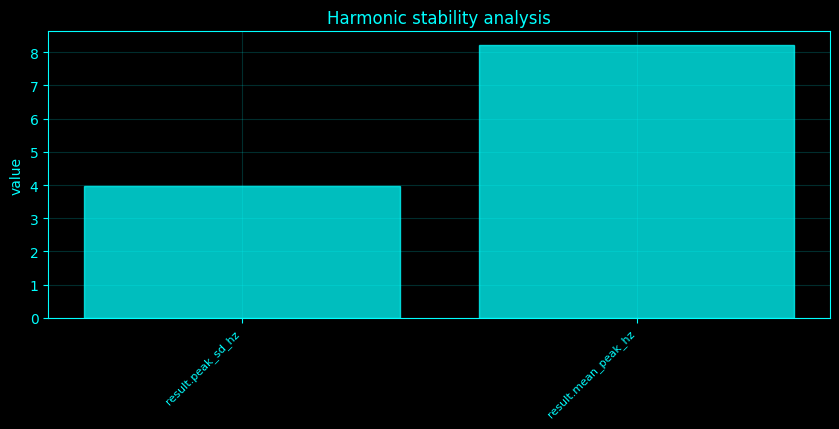

In [52]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

# Method-specific calculation.
def _compute_method_346():
    idx = 346
    name = 'Harmonic stability analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    tt, W = _window_bandpower()
    nwin = len(tt)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    traj = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(max(32, b - a), _SPEED['nperseg']))
        m = (ff >= 4) & (ff <= 30)
        traj.append(float(ff[m][np.argmax(pp[m, 0])]) if np.any(m) else np.nan)
    return ({'mean_peak_hz': float(np.nanmean(traj)), 'peak_sd_hz': float(np.nanstd(traj))}, locals().get('__plot_spec', None))
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_346,_plot_spec=_compute_method_346()
print('Harmonic stability analysis')
if isinstance(result_346,dict):
    for _k,_v in result_346.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_346)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_346)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Harmonic stability analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Harmonic stability analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Harmonic stability analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">347. Harmonic phase locking</h3>
<p>For a 2:1 harmonic relation, harmonic phase locking is \(R=|\langle e^{i(2\phi_{f_0}-\phi_{2f_0})}\rangle|\). It equals one for a perfectly stable quadratic phase relation.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [53]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_347():
    idx = 347
    name = 'Harmonic phase locking'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    bw = max(1.0, 0.12 * f0)
    b1 = (max(1, f0 - bw), min(0.45 * _fs, f0 + bw))
    b2 = (max(1, 2 * f0 - bw), min(0.45 * _fs, 2 * f0 + bw))
    if b2[0] >= b2[1]:
        return ({'status': 'second harmonic above analysis Nyquist'}, locals().get('__plot_spec', None))
    z1 = _analytic_band(b1)[:, 0]
    z2 = _analytic_band(b2)[:, 0]
    phase_lock = np.abs(np.mean(np.exp(1j * (2 * np.angle(z1) - np.angle(z2)))))
    return ({'2:1_harmonic_phase_locking': float(phase_lock)}, locals().get('__plot_spec', None))
    u = (z1 / (np.abs(z1) + EPS)) ** 2
    v = z2 / (np.abs(z2) + EPS)
    coh = np.abs(np.mean(u * np.conj(v))) ** 2
    return ({'harmonic_phase_coherence': float(coh)}, locals().get('__plot_spec', None))
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_347,_plot_spec=_compute_method_347()
print('Harmonic phase locking')
if isinstance(result_347,dict):
    for _k,_v in result_347.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_347)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_347)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Harmonic phase locking',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Harmonic phase locking',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Harmonic phase locking',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Harmonic phase locking
  2:1_harmonic_phase_locking: 0.0717467148864045


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">348. Harmonic coherence</h3>
<p>Harmonic coherence is computed after phase-only frequency translation: the squared fundamental phasor is compared with the second-harmonic phasor, \(|\langle u_{f_0}^2u_{2f_0}^*\rangle|^2\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [54]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_348():
    idx = 348
    name = 'Harmonic coherence'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    bw = max(1.0, 0.12 * f0)
    b1 = (max(1, f0 - bw), min(0.45 * _fs, f0 + bw))
    b2 = (max(1, 2 * f0 - bw), min(0.45 * _fs, 2 * f0 + bw))
    if b2[0] >= b2[1]:
        return ({'status': 'second harmonic above analysis Nyquist'}, locals().get('__plot_spec', None))
    z1 = _analytic_band(b1)[:, 0]
    z2 = _analytic_band(b2)[:, 0]
    phase_lock = np.abs(np.mean(np.exp(1j * (2 * np.angle(z1) - np.angle(z2)))))
    u = (z1 / (np.abs(z1) + EPS)) ** 2
    v = z2 / (np.abs(z2) + EPS)
    coh = np.abs(np.mean(u * np.conj(v))) ** 2
    return ({'harmonic_phase_coherence': float(coh)}, locals().get('__plot_spec', None))
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_348,_plot_spec=_compute_method_348()
print('Harmonic coherence')
if isinstance(result_348,dict):
    for _k,_v in result_348.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_348)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_348)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Harmonic coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Harmonic coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Harmonic coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Harmonic coherence
  harmonic_phase_coherence: 0.0051475910947910725


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">349. Harmonic cascade metrics</h3>
<p>Harmonic cascade metrics compare powers at \(nf_0\) with the fundamental and fit the decay of log harmonic power versus harmonic number.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Harmonic cascade metrics
  harmonic_relative_powers: array(4,), mean=0.0753833
  cascade_decay_slope: -0.7477211080394306


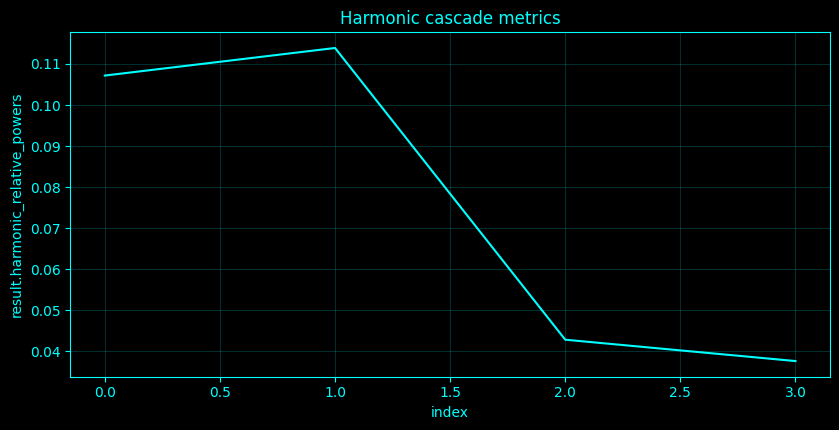

In [55]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_349():
    idx = 349
    name = 'Harmonic cascade metrics'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    vals = []
    for n in range(1, 6):
        fh = n * f0
        if fh > f[-1]:
            break
        k = np.argmin(np.abs(f - fh))
        vals.append(float(p[k]))
    ratios = [vals[i] / (vals[0] + EPS) for i in range(1, len(vals))]
    return ({'harmonic_relative_powers': ratios, 'cascade_decay_slope': float(np.polyfit(np.arange(1, len(vals) + 1), np.log(np.array(vals) + EPS), 1)[0]) if len(vals) >= 2 else np.nan}, locals().get('__plot_spec', None))
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_349,_plot_spec=_compute_method_349()
print('Harmonic cascade metrics')
if isinstance(result_349,dict):
    for _k,_v in result_349.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_349)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_349)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Harmonic cascade metrics',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Harmonic cascade metrics',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Harmonic cascade metrics',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">350. Resonance Q-factor estimation</h3>
<p>The resonance quality factor is \(Q=f_0/\Delta f_{FWHM}\), where \(\Delta f_{FWHM}\) is the half-power bandwidth.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Resonance Q-factor estimation
  f0_hz: 10.498046875
  Q_factor: 7.166666666661774


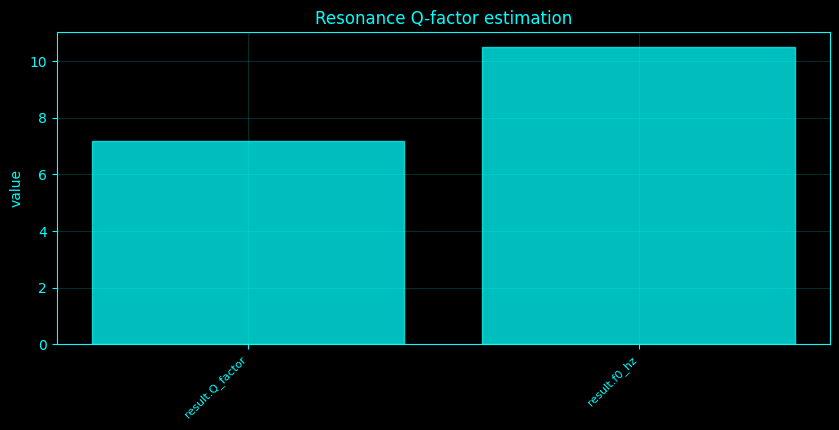

In [56]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_350():
    idx = 350
    name = 'Resonance Q-factor estimation'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    return ({'f0_hz': f0, 'Q_factor': float(Q)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_350,_plot_spec=_compute_method_350()
print('Resonance Q-factor estimation')
if isinstance(result_350,dict):
    for _k,_v in result_350.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_350)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_350)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Resonance Q-factor estimation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Resonance Q-factor estimation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Resonance Q-factor estimation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">351. Resonance bandwidth estimation</h3>
<p>Resonance bandwidth is estimated as the full width between frequencies where spectral power falls below half the peak power.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [57]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_351():
    idx = 351
    name = 'Resonance bandwidth estimation'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    return ({'FWHM_hz': float(bw)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_351,_plot_spec=_compute_method_351()
print('Resonance bandwidth estimation')
if isinstance(result_351,dict):
    for _k,_v in result_351.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_351)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_351)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Resonance bandwidth estimation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Resonance bandwidth estimation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Resonance bandwidth estimation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Resonance bandwidth estimation
  FWHM_hz: 1.46484375


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">352. Resonance damping estimation</h3>
<p>For a lightly damped second-order resonance, the damping ratio is approximately \(\zeta\approx1/(2Q)\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [58]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_352():
    idx = 352
    name = 'Resonance damping estimation'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    return ({'damping_ratio_zeta': float(1 / (2 * Q + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_352,_plot_spec=_compute_method_352()
print('Resonance damping estimation')
if isinstance(result_352,dict):
    for _k,_v in result_352.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_352)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_352)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Resonance damping estimation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Resonance damping estimation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Resonance damping estimation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Resonance damping estimation
  damping_ratio_zeta: 0.06976744186050787


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">353. Resonance peak lifetime</h3>
<p>For an exponentially decaying lightly damped oscillator, the amplitude decay time constant is approximately \(\tau=Q/(\pi f_0)\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [59]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_353():
    idx = 353
    name = 'Resonance peak lifetime'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    return ({'amplitude_decay_time_s': float(Q / (np.pi * f0 + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_353,_plot_spec=_compute_method_353()
print('Resonance peak lifetime')
if isinstance(result_353,dict):
    for _k,_v in result_353.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_353)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_353)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Resonance peak lifetime',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Resonance peak lifetime',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Resonance peak lifetime',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Resonance peak lifetime
  amplitude_decay_time_s: 0.2172995489679795


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">354. Resonance ridge tracking</h3>
<p>Resonance ridge tracking follows the frequency of maximal spectrogram power within the resonance search band at each time bin.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Resonance ridge tracking
  ridge_mean_hz: 7.396024816176471
  ridge_sd_hz: 4.295355412216341


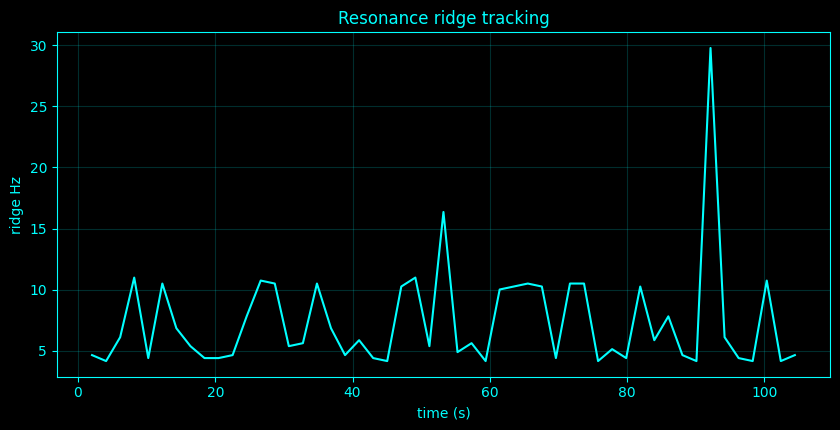

In [60]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_354():
    idx = 354
    name = 'Resonance ridge tracking'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    ff, tt, S, _ = _stft_summary()
    Z = S[:, 0, :]
    m = (ff >= 4) & (ff <= 30)
    ridge = ff[m][np.argmax(Z[m], axis=0)]
    __plot_spec = ('summary', ridge, name, tt, 'time (s)', 'ridge Hz')
    return ({'ridge_mean_hz': float(np.mean(ridge)), 'ridge_sd_hz': float(np.std(ridge))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_354,_plot_spec=_compute_method_354()
print('Resonance ridge tracking')
if isinstance(result_354,dict):
    for _k,_v in result_354.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_354)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_354)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Resonance ridge tracking',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Resonance ridge tracking',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Resonance ridge tracking',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">355. Resonance network analysis</h3>
<p>A resonance network connects channels by similarity of their dominant resonance frequencies; edge weight decays exponentially with frequency mismatch.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [61]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _harmonic_metrics():
    if 'harmonic' in SPEC_CACHE:
        return SPEC_CACHE['harmonic']
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    mm = (f >= 4) & (f <= 20)
    f0 = float(f[mm][np.argmax(p[mm])])
    peaks, _ = signal.find_peaks(p, prominence=max(np.std(p) * 0.1, EPS))
    pf = f[peaks]
    pv = p[peaks]
    SPEC_CACHE['harmonic'] = (f, p, f0, pf, pv)
    return SPEC_CACHE['harmonic']

# Method-specific calculation.
def _compute_method_355():
    idx = 355
    name = 'Resonance network analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, p, f0, pf, pv = _harmonic_metrics()
    k0 = np.argmin(np.abs(f - f0))
    peak = p[k0]
    half = peak / 2
    il = k0
    while il > 0 and p[il] > half:
        il -= 1
    ir = k0
    while ir < len(p) - 1 and p[ir] > half:
        ir += 1
    bw = max(float(f[ir] - f[il]), float(f[1] - f[0]) if len(f) > 1 else EPS)
    Q = f0 / (bw + EPS)
    fw, Pall = _welch_all()
    vals = []
    for j in range(C):
        mm = (fw >= 4) & (fw <= 30)
        fj = float(fw[mm][np.argmax(Pall[mm, j])])
        vals.append(fj)
    vals = np.asarray(vals)
    D = np.abs(vals[:, None] - vals[None, :])
    scale = np.median(D[D > 0]) + EPS if np.any(D > 0) else 1
    A = np.exp(-D / scale)
    np.fill_diagonal(A, 0)
    __plot_spec = ('summary', A, name, None, '', 'value')
    return ({'mean_resonance_similarity': float(np.mean(A[np.triu_indices(C, 1)]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_355,_plot_spec=_compute_method_355()
print('Resonance network analysis')
if isinstance(result_355,dict):
    for _k,_v in result_355.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_355)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_355)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Resonance network analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Resonance network analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Resonance network analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Resonance network analysis
  mean_resonance_similarity: 0.7347129682278791


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">356. Spectral graph theory of EEG connectivity</h3>
<p>The weighted EEG connectivity graph is represented by adjacency \(W\) and normalized Laplacian \(L_n=D^{-1/2}(D-W)D^{-1/2}\). Its eigenvalues are graph frequencies; the second eigenvalue measures algebraic connectivity for a connected undirected graph.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral graph theory of EEG connectivity
  nodes: 12
  weighted_edges: 66
  lambda2: 0.8953934289414058
  lambda_max: 1.16101840393075


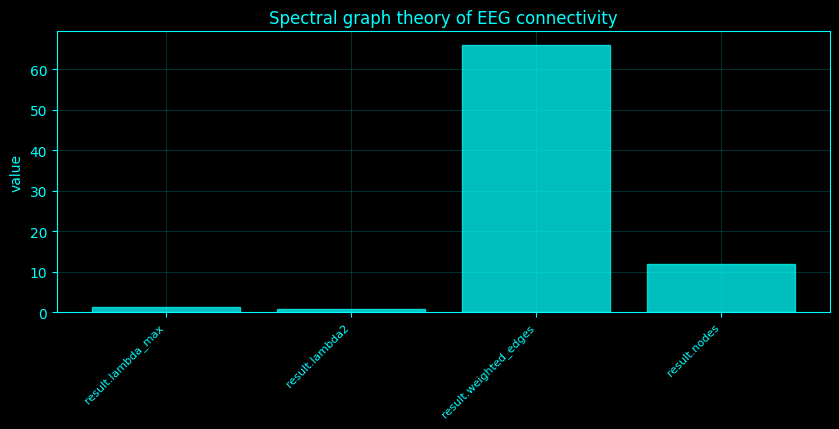

In [62]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_356():
    idx = 356
    name = 'Spectral graph theory of EEG connectivity'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    return ({'nodes': C, 'weighted_edges': int(C * (C - 1) / 2), 'lambda2': float(lam[1]) if C > 1 else 0, 'lambda_max': float(lam[-1])}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_356,_plot_spec=_compute_method_356()
print('Spectral graph theory of EEG connectivity')
if isinstance(result_356,dict):
    for _k,_v in result_356.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_356)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_356)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral graph theory of EEG connectivity',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral graph theory of EEG connectivity',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral graph theory of EEG connectivity',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">357. Laplacian eigenvalue spectrum of coherence networks</h3>
<p>The coherence graph is represented by adjacency \(W\) and normalized Laplacian \(L_n=D^{-1/2}(D-W)D^{-1/2}\). Its eigenvalues are graph frequencies; the second eigenvalue measures algebraic connectivity for a connected undirected graph.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [63]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_357():
    idx = 357
    name = 'Laplacian eigenvalue spectrum of coherence networks'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    __plot_spec = ('summary', lam, name, np.arange(C), 'mode', 'λ')
    return ({'coherence_graph_lambda2': float(lam[1]) if C > 1 else 0}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_357,_plot_spec=_compute_method_357()
print('Laplacian eigenvalue spectrum of coherence networks')
if isinstance(result_357,dict):
    for _k,_v in result_357.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_357)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_357)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Laplacian eigenvalue spectrum of coherence networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Laplacian eigenvalue spectrum of coherence networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Laplacian eigenvalue spectrum of coherence networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Laplacian eigenvalue spectrum of coherence networks
  coherence_graph_lambda2: 0.8953934289414058


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">358. Laplacian eigenvalue spectrum of PLV networks</h3>
<p>The PLV graph is represented by adjacency \(W\) and normalized Laplacian \(L_n=D^{-1/2}(D-W)D^{-1/2}\). Its eigenvalues are graph frequencies; the second eigenvalue measures algebraic connectivity for a connected undirected graph.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [64]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_358():
    idx = 358
    name = 'Laplacian eigenvalue spectrum of PLV networks'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    M = _coherence_matrix(BANDS['alpha'], phase=True)
    np.fill_diagonal(M, 0)
    D = np.diag(M.sum(1) + EPS)
    Di = np.diag(1 / np.sqrt(np.diag(D) + EPS))
    Lv = Di @ (D - M) @ Di
    lv = np.linalg.eigvalsh((Lv + Lv.T) / 2)
    __plot_spec = ('summary', lv, name, None, '', 'value')
    return ({'PLV_lambda2': float(lv[1]) if C > 1 else 0}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_358,_plot_spec=_compute_method_358()
print('Laplacian eigenvalue spectrum of PLV networks')
if isinstance(result_358,dict):
    for _k,_v in result_358.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_358)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_358)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Laplacian eigenvalue spectrum of PLV networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Laplacian eigenvalue spectrum of PLV networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Laplacian eigenvalue spectrum of PLV networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Laplacian eigenvalue spectrum of PLV networks
  PLV_lambda2: 0.9712053913426317


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">359. Spectral graph wavelets on EEG networks</h3>
<p>Graph spectral wavelets are generated from the Laplacian eigendecomposition \(L=U\Lambda U^\top\). The implemented heat-kernel family is \(g_s(L)=Ue^{-s\Lambda}U^\top\), applied to an alpha-bandpower graph signal.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral graph wavelets on EEG networks
  scales: array(4,), mean=1.875


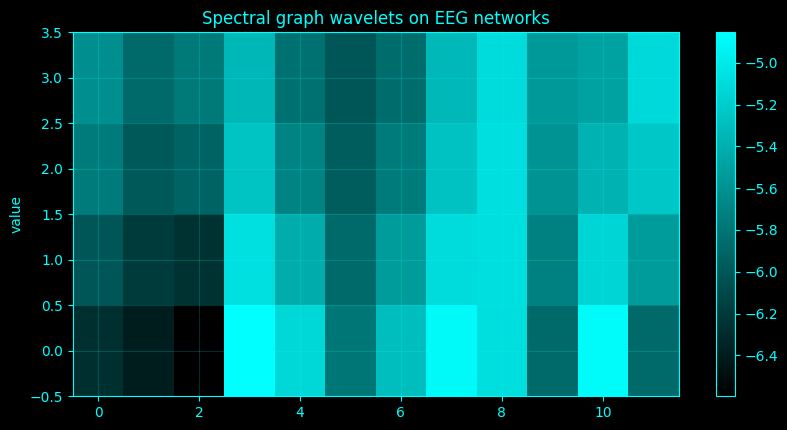

In [65]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_359():
    idx = 359
    name = 'Spectral graph wavelets on EEG networks'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    x = np.log(BP[:, list(BANDS).index('alpha')] + EPS)
    scales = [0.5, 1, 2, 4]
    coeff = []
    for s in scales:
        coeff.append(U @ np.diag(np.exp(-s * lam)) @ U.T @ x)
    __plot_spec = ('summary', np.asarray(coeff), name, None, '', 'value')
    return ({'scales': scales}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_359,_plot_spec=_compute_method_359()
print('Spectral graph wavelets on EEG networks')
if isinstance(result_359,dict):
    for _k,_v in result_359.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_359)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_359)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral graph wavelets on EEG networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral graph wavelets on EEG networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral graph wavelets on EEG networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">360. Graph Fourier transform of bandpower maps</h3>
<p>The graph Fourier transform of node signal \(x\) is \(\hat x=U^\top x\), where columns of \(U\) are Laplacian eigenvectors.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The Fourier transform represents a time-domain signal as a weighted sum of sinusoidal components. Each Fourier coefficient is complex: its magnitude describes the strength of a frequency component, while its angle describes phase relative to the chosen time origin. The discrete Fourier transform evaluates this representation only at a finite set of frequencies determined by the sampling rate and record length. It describes global frequency content over the analyzed window and does not by itself show when a frequency occurs.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [66]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_360():
    idx = 360
    name = 'Graph Fourier transform of bandpower maps'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    x = np.log(BP[:, list(BANDS).index('alpha')] + EPS)
    xhat = U.T @ x
    __plot_spec = ('summary', np.abs(xhat) ** 2, name, lam, 'graph λ', 'energy')
    return ({'low_graph_frequency_energy_fraction': float(np.sum(np.abs(xhat[:max(1, C // 4)]) ** 2) / (np.sum(np.abs(xhat) ** 2) + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_360,_plot_spec=_compute_method_360()
print('Graph Fourier transform of bandpower maps')
if isinstance(result_360,dict):
    for _k,_v in result_360.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_360)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_360)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Graph Fourier transform of bandpower maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Graph Fourier transform of bandpower maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Graph Fourier transform of bandpower maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Graph Fourier transform of bandpower maps
  low_graph_frequency_energy_fraction: 0.9805424516989104


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">361. Graph spectral entropy</h3>
<p>Graph spectral entropy normalizes graph-Fourier energy \(q_k=|\hat x_k|^2/\sum_j|\hat x_j|^2\) and computes \(H=-\sum_kq_k\log q_k\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Spectral entropy treats the normalized power spectrum as a probability distribution over frequency bins and applies Shannon entropy to that distribution. If power is concentrated in only a few frequencies, the distribution is uneven and entropy is low. If power is spread broadly across many frequencies, entropy is higher. The result therefore describes spectral dispersion, not temporal unpredictability in exactly the same sense as Sample Entropy or permutation entropy.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Graph spectral entropy
  graph_spectral_entropy: 0.1871161413062576
  normalized: 0.07530107471933459


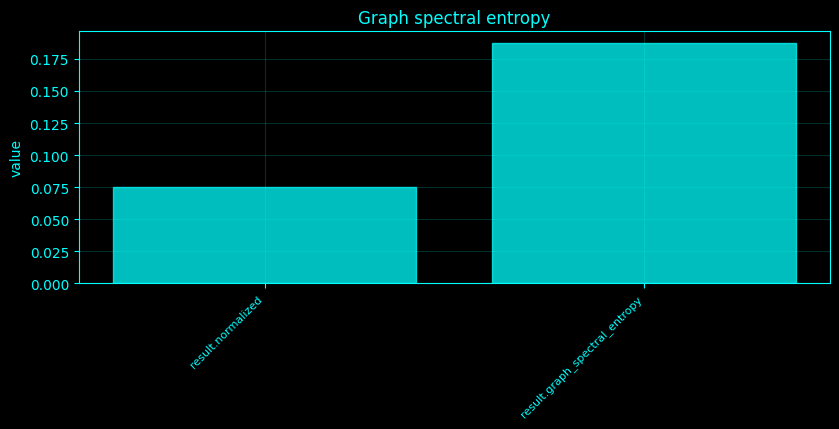

In [67]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_361():
    idx = 361
    name = 'Graph spectral entropy'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    x = np.log(BP[:, list(BANDS).index('alpha')] + EPS)
    e = np.abs(U.T @ x) ** 2
    q = e / (e.sum() + EPS)
    H = -np.sum(q * np.log(q + EPS))
    return ({'graph_spectral_entropy': float(H), 'normalized': float(H / np.log(len(q)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_361,_plot_spec=_compute_method_361()
print('Graph spectral entropy')
if isinstance(result_361,dict):
    for _k,_v in result_361.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_361)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_361)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Graph spectral entropy',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Graph spectral entropy',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Graph spectral entropy',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">362. Graph spectral energy by frequency band</h3>
<p>For each EEG bandpower map, graph spectral energy is \(|U^\top x|^2\). The cell reports the fraction carried by the lowest graph-frequency modes.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Graph spectral energy by frequency band
  delta: 0.969119987769031
  theta: 0.97910935254947
  alpha: 0.9811262777030769
  beta: 0.9806844942550126
  gamma: 0.9825039137136014


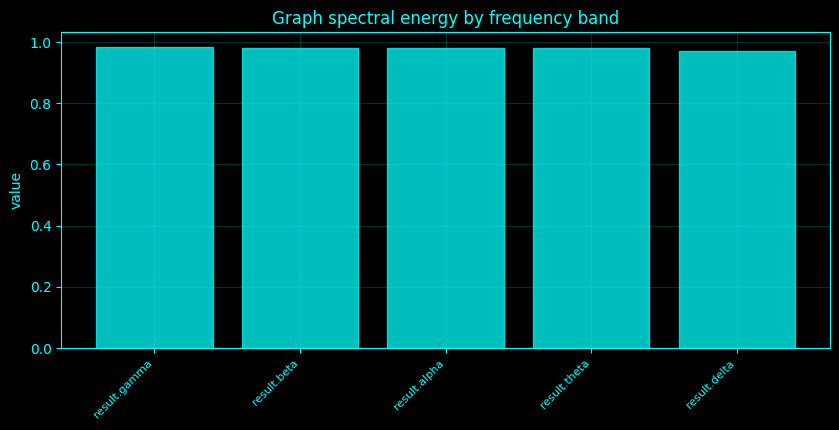

In [68]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_362():
    idx = 362
    name = 'Graph spectral energy by frequency band'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    out = {}
    for bi, bn in enumerate(BANDS):
        x = np.log(BP[:, bi] + EPS)
        e = np.abs(U.T @ x) ** 2
        out[bn] = float(np.sum(e[:max(1, C // 3)]) / (np.sum(e) + EPS))
    return (out, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_362,_plot_spec=_compute_method_362()
print('Graph spectral energy by frequency band')
if isinstance(result_362,dict):
    for _k,_v in result_362.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_362)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_362)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Graph spectral energy by frequency band',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Graph spectral energy by frequency band',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Graph spectral energy by frequency band',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">363. Graph signal smoothness by EEG band</h3>
<p>Graph signal smoothness is the normalized Dirichlet energy \(x^\top Lx/(x^\top x)\); small values mean adjacent strongly connected electrodes have similar bandpower.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Graph signal smoothness by EEG band
  delta: 0.173188361543159
  theta: 0.11376884966119395
  alpha: 0.20226352621251817
  beta: 0.23332573376009216
  gamma: 0.20630878777744185


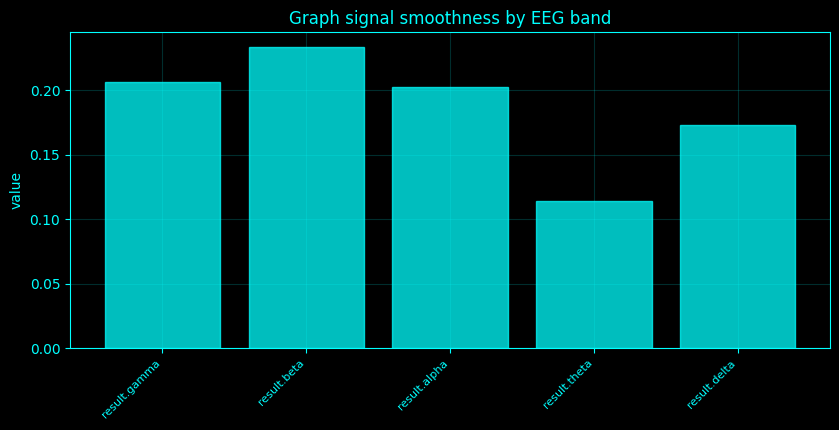

In [69]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_363():
    idx = 363
    name = 'Graph signal smoothness by EEG band'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    out = {}
    for bi, bn in enumerate(BANDS):
        x = np.log(BP[:, bi] + EPS)
        out[bn] = float(x @ L @ x / (x @ x + EPS))
    return (out, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_363,_plot_spec=_compute_method_363()
print('Graph signal smoothness by EEG band')
if isinstance(result_363,dict):
    for _k,_v in result_363.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_363)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_363)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Graph signal smoothness by EEG band',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Graph signal smoothness by EEG band',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Graph signal smoothness by EEG band',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">364. Graph signal total variation</h3>
<p>Graph total variation is \(\tfrac12\sum_{ij}w_{ij}|x_i-x_j|\), an \(L^1\) measure of spatial variation over graph edges.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [70]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_364():
    idx = 364
    name = 'Graph signal total variation'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    x = np.log(BP[:, list(BANDS).index('alpha')] + EPS)
    tv = 0.5 * np.sum(A * np.abs(x[:, None] - x[None, :]))
    return ({'alpha_graph_total_variation': float(tv)}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_364,_plot_spec=_compute_method_364()
print('Graph signal total variation')
if isinstance(result_364,dict):
    for _k,_v in result_364.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_364)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_364)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Graph signal total variation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Graph signal total variation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Graph signal total variation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Graph signal total variation
  alpha_graph_total_variation: 45.23765798831839


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">365. Graph frequency localization</h3>
<p>Graph frequency localization is summarized by the energy-weighted graph-frequency centroid \(\bar\lambda=\sum_k\lambda_k|\hat x_k|^2/\sum_k|\hat x_k|^2\) and inverse participation of the spectral energy.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Graph frequency localization
  graph_frequency_centroid: 0.032453473677971155
  inverse_participation: 0.9414685360745186


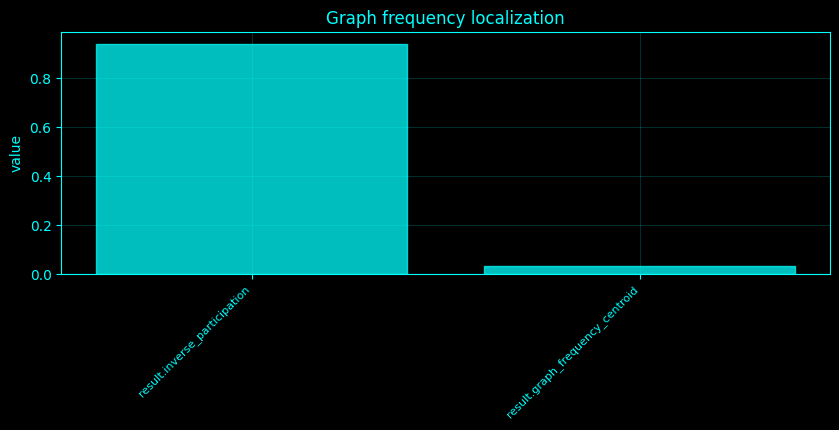

In [71]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_365():
    idx = 365
    name = 'Graph frequency localization'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    x = np.log(BP[:, list(BANDS).index('alpha')] + EPS)
    e = np.abs(U.T @ x) ** 2
    centroid = float(np.sum(lam * e) / (np.sum(e) + EPS))
    return ({'graph_frequency_centroid': centroid, 'inverse_participation': float(np.sum((e / (e.sum() + EPS)) ** 2))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_365,_plot_spec=_compute_method_365()
print('Graph frequency localization')
if isinstance(result_365,dict):
    for _k,_v in result_365.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_365)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_365)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Graph frequency localization',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Graph frequency localization',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Graph frequency localization',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">366. Graph wavelet coherence</h3>
<p>Graph wavelet coherence here is a cross-scale consistency measure: dynamic bandpower maps are filtered by two heat-kernel graph scales and their channel-wise temporal correlations are summarized.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [72]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _spectral_graph():
    if 'sgraph' in SPEC_CACHE:
        return SPEC_CACHE['sgraph']
    A = np.array(_coherence_matrix(BANDS['alpha']), float)
    np.fill_diagonal(A, 0)
    D = np.diag(A.sum(1) + EPS)
    L = D - A
    d = np.diag(D)
    Din = np.diag(1 / np.sqrt(d + EPS))
    Ln = Din @ L @ Din
    lam, U = np.linalg.eigh((Ln + Ln.T) / 2)
    SPEC_CACHE['sgraph'] = (A, L, Ln, lam, U)
    return SPEC_CACHE['sgraph']

# Method-specific calculation.
def _compute_method_366():
    idx = 366
    name = 'Graph wavelet coherence'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    A, L, Ln, lam, U = _spectral_graph()
    _, BP = _bandpower_matrix()
    t, W = _window_bandpower()
    alpha = np.log(W[:, :, list(BANDS).index('alpha')] + EPS)
    K1 = U @ np.diag(np.exp(-0.5 * lam)) @ U.T
    K2 = U @ np.diag(np.exp(-2 * lam)) @ U.T
    c1 = alpha @ K1.T
    c2 = alpha @ K2.T
    vals = [np.corrcoef(c1[:, j], c2[:, j])[0, 1] for j in range(C)]
    return ({'mean_cross_scale_graph_wavelet_coherence': float(np.nanmean(np.abs(vals)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_366,_plot_spec=_compute_method_366()
print('Graph wavelet coherence')
if isinstance(result_366,dict):
    for _k,_v in result_366.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_366)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_366)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Graph wavelet coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Graph wavelet coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Graph wavelet coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Graph wavelet coherence
  mean_cross_scale_graph_wavelet_coherence: 0.9612226956529185


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">367. Spectral dimensionality reduction</h3>
<p>Frequency-domain PCA applies PCA to standardized channel log spectra. The covariance eigendecomposition finds orthogonal spectral directions that maximize explained variance.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral dimensionality reduction
  components: 4
  cumulative_variance: 0.9943209814442456


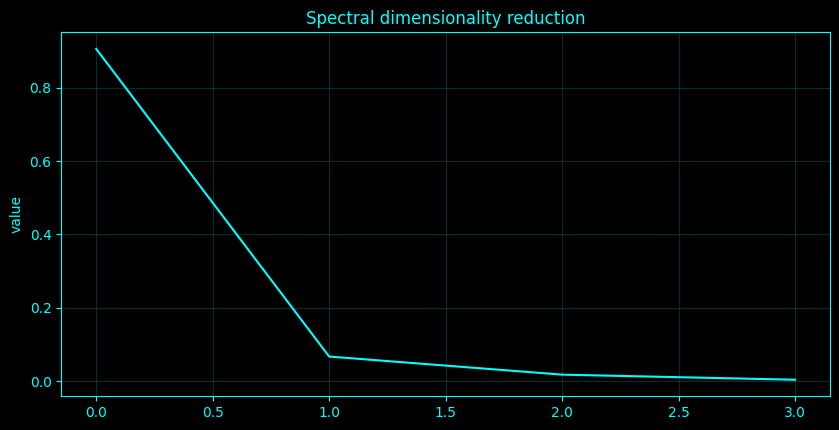

In [73]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_367():
    idx = 367
    name = 'Spectral dimensionality reduction'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    r = min(_SPEED['rank'], C, Xz.shape[1])
    pca = PCA(n_components=r).fit(Xz)
    __plot_spec = ('summary', pca.explained_variance_ratio_, name, None, '', 'value')
    return ({'components': r, 'cumulative_variance': float(np.sum(pca.explained_variance_ratio_))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_367,_plot_spec=_compute_method_367()
print('Spectral dimensionality reduction')
if isinstance(result_367,dict):
    for _k,_v in result_367.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_367)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_367)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral dimensionality reduction',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral dimensionality reduction',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral dimensionality reduction',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">368. Frequency-domain PCA</h3>
<p>Frequency-domain PCA applies PCA to standardized channel log spectra. The covariance eigendecomposition finds orthogonal spectral directions that maximize explained variance.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Frequency-domain PCA
  components: 4
  cumulative_variance: 0.9943209814442456


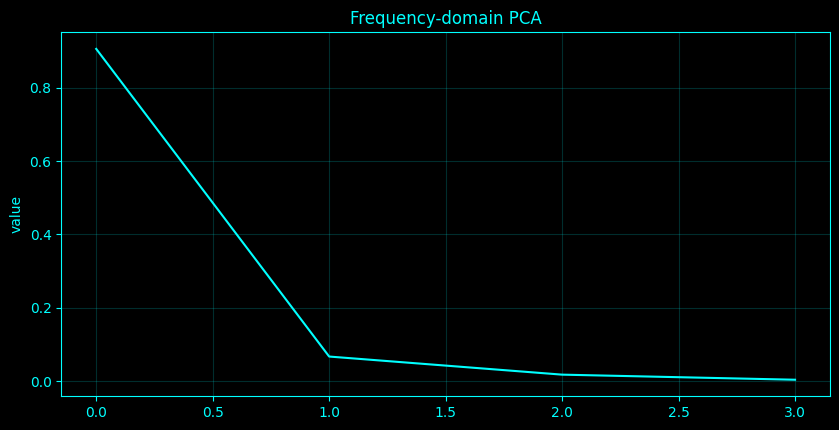

In [74]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_368():
    idx = 368
    name = 'Frequency-domain PCA'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    r = min(_SPEED['rank'], C, Xz.shape[1])
    pca = PCA(n_components=r).fit(Xz)
    __plot_spec = ('summary', pca.explained_variance_ratio_, name, None, '', 'value')
    return ({'components': r, 'cumulative_variance': float(np.sum(pca.explained_variance_ratio_))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_368,_plot_spec=_compute_method_368()
print('Frequency-domain PCA')
if isinstance(result_368,dict):
    for _k,_v in result_368.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_368)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_368)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-domain PCA',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-domain PCA',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-domain PCA',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">369. Frequency-domain ICA</h3>
<p>Frequency-domain ICA applies ICA to channel spectra, seeking independent non-Gaussian spectral components after whitening.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Frequency-domain ICA
  components: 4
  mean_abs_kurtosis: 1.4861371340559821


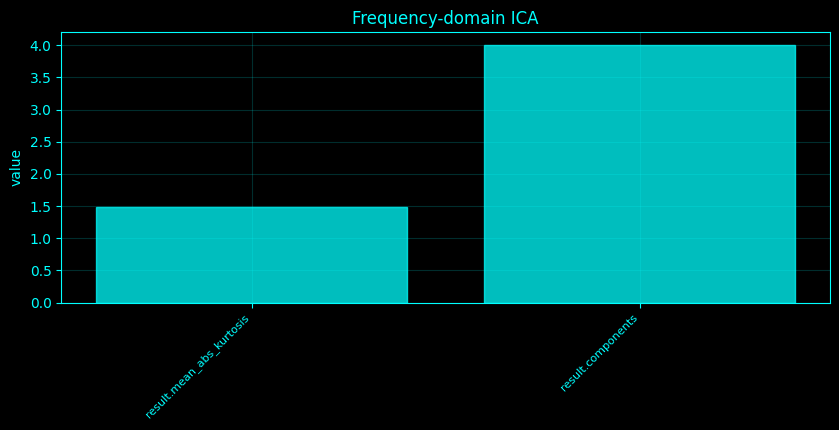

In [75]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_369():
    idx = 369
    name = 'Frequency-domain ICA'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    r = min(_SPEED['rank'], C - 1, Xz.shape[1])
    ica = FastICA(n_components=max(1, r), random_state=0, max_iter=1000, whiten='unit-variance').fit(Xz)
    return ({'components': ica.components_.shape[0], 'mean_abs_kurtosis': float(np.mean(np.abs(stats.kurtosis(ica.transform(Xz), axis=0, fisher=True))))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_369,_plot_spec=_compute_method_369()
print('Frequency-domain ICA')
if isinstance(result_369,dict):
    for _k,_v in result_369.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_369)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_369)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-domain ICA',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-domain ICA',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-domain ICA',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">370. Frequency-domain NMF</h3>
<p>Frequency-domain NMF factorizes nonnegative shifted spectra \(V\approx WH\) into additive channel loadings and spectral basis functions.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Frequency-domain NMF
  rank: 4
  relative_error: 0.024955794751464706


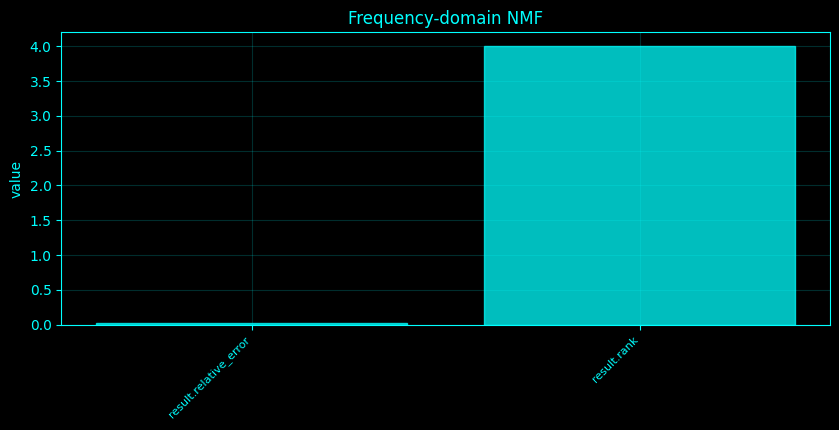

In [76]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_370():
    idx = 370
    name = 'Frequency-domain NMF'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    V = Xspec - Xspec.min() + EPS
    r = min(_SPEED['rank'], min(V.shape) - 1)
    nmf = NMF(n_components=max(1, r), init='nndsvda', random_state=0, max_iter=500).fit(V)
    R = nmf.transform(V) @ nmf.components_
    return ({'rank': r, 'relative_error': float(np.linalg.norm(V - R) / (np.linalg.norm(V) + EPS))}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_370,_plot_spec=_compute_method_370()
print('Frequency-domain NMF')
if isinstance(result_370,dict):
    for _k,_v in result_370.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_370)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_370)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-domain NMF',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-domain NMF',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-domain NMF',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">371. Complex PCA of cross-spectral matrices</h3>
<p>Complex PCA of cross-spectral matrices eigendecomposes the Hermitian mean cross-spectrum \(S(f)\). Its eigenvectors are complex spatial modes and eigenvalues give modal spectral power.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Complex PCA of cross-spectral matrices
  complex_PCA_eigenvalue_fraction: array(5,), mean=0.197057


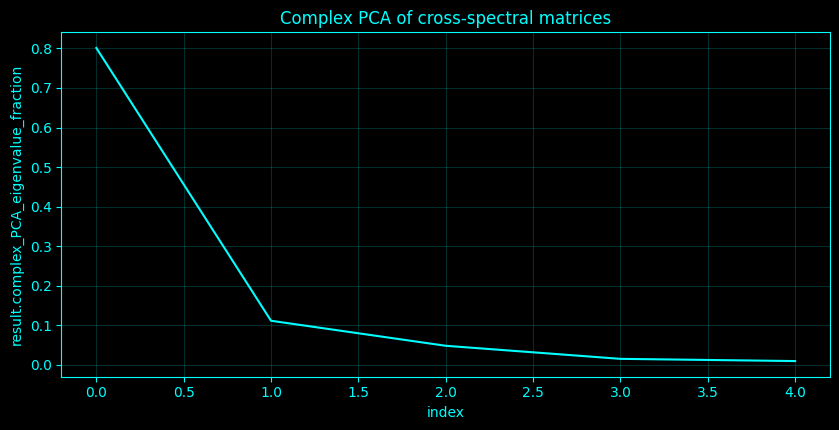

In [77]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_371():
    idx = 371
    name = 'Complex PCA of cross-spectral matrices'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    n = min(_SPEED['nperseg'], N)
    step = max(1, n // 2)
    mats = []
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft(X[a:a + n] * signal.windows.hann(n)[:, None], axis=0)
        fre = np.fft.rfftfreq(n, 1 / _fs)
        m = (fre >= 8) & (fre < 13)
        if np.any(m):
            for z in F[m]:
                mats.append(np.outer(z, np.conj(z)))
    Smean = np.mean(mats, axis=0)
    w, V = np.linalg.eigh((Smean + Smean.conj().T) / 2)
    w = np.maximum(w, 0)[::-1]
    return ({'complex_PCA_eigenvalue_fraction': (w / (w.sum() + EPS))[:min(5, len(w))].tolist()}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_371,_plot_spec=_compute_method_371()
print('Complex PCA of cross-spectral matrices')
if isinstance(result_371,dict):
    for _k,_v in result_371.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_371)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_371)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Complex PCA of cross-spectral matrices',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Complex PCA of cross-spectral matrices',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Complex PCA of cross-spectral matrices',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">372. Complex ICA of Fourier coefficients</h3>
<p>Complex Fourier coefficients contain in-phase and quadrature information. The implementation uses a real-augmented representation \([\Re Z,\Im Z]\) for ICA, which preserves both quadratures while using a real FastICA solver.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Complex ICA of Fourier coefficients
  augmented_complex_components: 4
  mean_abs_kurtosis: 9.540784524963607
  note: real-augmented ICA represents complex Fourier coefficients without discarding quadrature


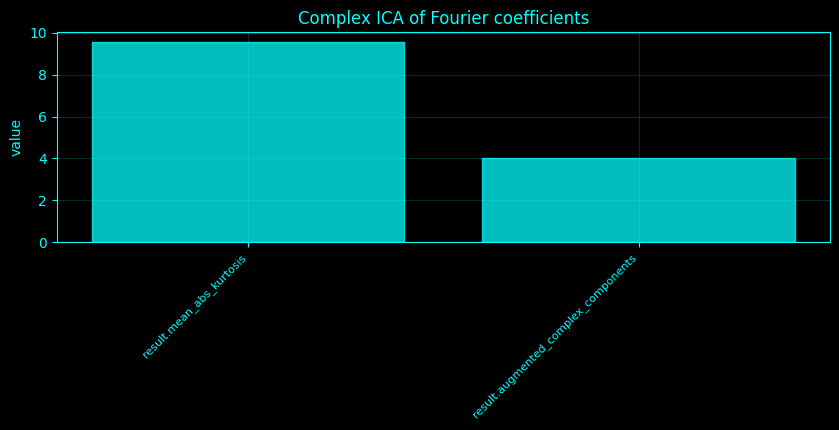

In [78]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_372():
    idx = 372
    name = 'Complex ICA of Fourier coefficients'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    n = min(_SPEED['nperseg'], N)
    F = np.fft.rfft(X[:n], axis=0)
    fre = np.fft.rfftfreq(n, 1 / _fs)
    m = (fre >= 2) & (fre <= 45)
    Z = F[m]
    R = np.hstack([Z.real, Z.imag])
    r = min(_SPEED['rank'], R.shape[1], R.shape[0] - 1)
    Sica = FastICA(n_components=max(1, r), random_state=0, max_iter=1000, whiten='unit-variance').fit_transform(R)
    return ({'augmented_complex_components': r, 'mean_abs_kurtosis': float(np.mean(np.abs(stats.kurtosis(Sica, axis=0, fisher=True)))), 'note': 'real-augmented ICA represents complex Fourier coefficients without discarding quadrature'}, locals().get('__plot_spec', None))
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_372,_plot_spec=_compute_method_372()
print('Complex ICA of Fourier coefficients')
if isinstance(result_372,dict):
    for _k,_v in result_372.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_372)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_372)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Complex ICA of Fourier coefficients',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Complex ICA of Fourier coefficients',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Complex ICA of Fourier coefficients',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">373. Spectral tensor decomposition</h3>
<p>Spectral tensor decomposition treats \(T\in\mathbb R^{channel\times frequency\times time}\) as a three-way tensor. HOSVD examines the singular spectrum of each mode unfolding.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral tensor decomposition
  channel_mode: array(4,), mean=0.248866
  frequency_mode: array(4,), mean=0.246842
  time_mode: array(4,), mean=0.246991


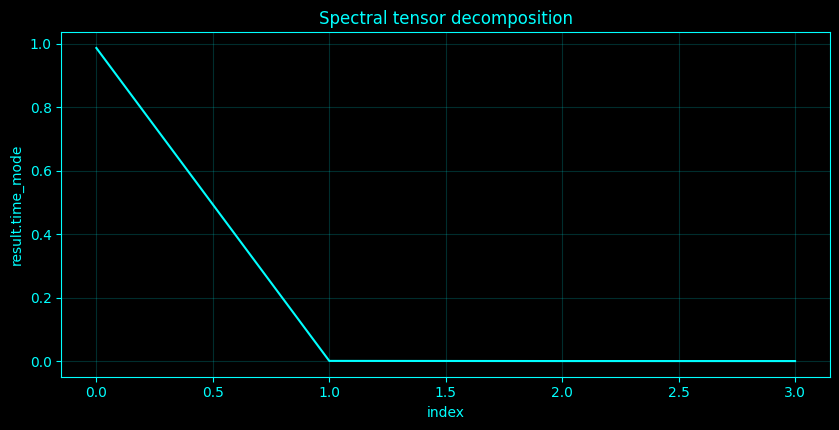

In [79]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_373():
    idx = 373
    name = 'Spectral tensor decomposition'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    spectra = []
    for mode in range(3):
        M = np.moveaxis(T, mode, 0).reshape(T.shape[mode], -1)
        s = np.linalg.svd(M, compute_uv=False)
        spectra.append((s ** 2 / (np.sum(s ** 2) + EPS))[:_SPEED['rank']].tolist())
    return ({'channel_mode': spectra[0], 'frequency_mode': spectra[1], 'time_mode': spectra[2]}, locals().get('__plot_spec', None))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_373,_plot_spec=_compute_method_373()
print('Spectral tensor decomposition')
if isinstance(result_373,dict):
    for _k,_v in result_373.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_373)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_373)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral tensor decomposition',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral tensor decomposition',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral tensor decomposition',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">374. PARAFAC of channel × frequency × time</h3>
<p>PARAFAC/CP models the tensor as \(T_{ijk}\approx\sum_{r=1}^R a_{ir}b_{jr}c_{kr}\). The cell uses alternating least squares on a speed-limited tensor.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


PARAFAC of channel × frequency × time
  CP_rank: 3
  relative_error: 0.11431514935890656


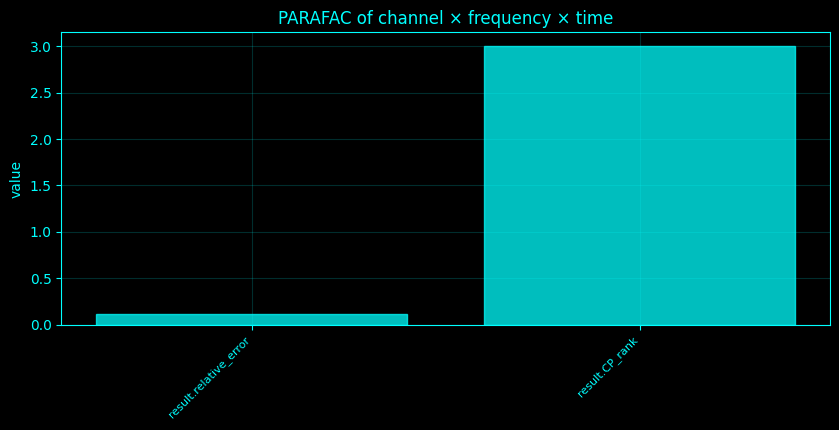

In [80]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _cp_rank1_tensor(T, rank=3, n_iter=30):
    T = np.asarray(T, float)
    I, J, K = T.shape
    rng = np.random.default_rng(123)
    A = rng.normal(size=(I, rank))
    B = rng.normal(size=(J, rank))
    Cc = rng.normal(size=(K, rank))
    for _ in range(n_iter):
        KR = np.einsum('jr,kr->jkr', B, Cc).reshape(J * K, rank)
        A = T.reshape(I, J * K) @ KR @ np.linalg.pinv(B.T @ B * (Cc.T @ Cc) + 1e-08 * np.eye(rank))
        KR = np.einsum('ir,kr->ikr', A, Cc).reshape(I * K, rank)
        B = np.transpose(T, (1, 0, 2)).reshape(J, I * K) @ KR @ np.linalg.pinv(A.T @ A * (Cc.T @ Cc) + 1e-08 * np.eye(rank))
        KR = np.einsum('ir,jr->ijr', A, B).reshape(I * J, rank)
        Cc = np.transpose(T, (2, 0, 1)).reshape(K, I * J) @ KR @ np.linalg.pinv(A.T @ A * (B.T @ B) + 1e-08 * np.eye(rank))
    recon = np.einsum('ir,jr,kr->ijk', A, B, Cc)
    return (A, B, Cc, recon)

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_374():
    idx = 374
    name = 'PARAFAC of channel × frequency × time'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    Ts = T[:, ::max(1, T.shape[1] // 32), ::max(1, T.shape[2] // 48)]
    r = min(3, _SPEED['rank'], min(Ts.shape))
    A1, B1, C1, R = _cp_rank1_tensor(Ts, rank=max(1, r), n_iter=12 if FAST_OPTION == 'ultra' else 25)
    return ({'CP_rank': r, 'relative_error': float(np.linalg.norm(Ts - R) / (np.linalg.norm(Ts) + EPS))}, locals().get('__plot_spec', None))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_374,_plot_spec=_compute_method_374()
print('PARAFAC of channel × frequency × time')
if isinstance(result_374,dict):
    for _k,_v in result_374.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_374)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_374)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'PARAFAC of channel × frequency × time',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'PARAFAC of channel × frequency × time',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('PARAFAC of channel × frequency × time',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">375. Tucker decomposition of spectrogram tensors</h3>
<p>Tucker decomposition projects each tensor mode onto a low-dimensional orthonormal subspace, \(T\approx G\times_1U_1\times_2U_2\times_3U_3\), where \(G\) is the core tensor.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Tucker decomposition of spectrogram tensors
  Tucker_ranks: array(3,), mean=4
  core_norm_fraction: 0.9869857521197557


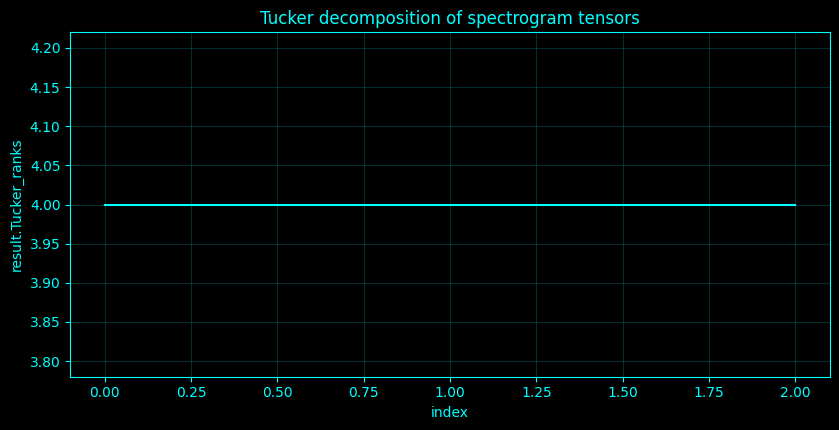

In [81]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_375():
    idx = 375
    name = 'Tucker decomposition of spectrogram tensors'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    ranks = [min(_SPEED['rank'], d) for d in T.shape]
    Us = []
    for mode, r in enumerate(ranks):
        M = np.moveaxis(T, mode, 0).reshape(T.shape[mode], -1)
        U, _, _ = np.linalg.svd(M, full_matrices=False)
        Us.append(U[:, :r])
    core = np.einsum('ia,jb,kc,ijk->abc', Us[0], Us[1], Us[2], T, optimize=True)
    return ({'Tucker_ranks': ranks, 'core_norm_fraction': float(np.linalg.norm(core) ** 2 / (np.linalg.norm(T) ** 2 + EPS))}, locals().get('__plot_spec', None))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_375,_plot_spec=_compute_method_375()
print('Tucker decomposition of spectrogram tensors')
if isinstance(result_375,dict):
    for _k,_v in result_375.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_375)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_375)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Tucker decomposition of spectrogram tensors',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Tucker decomposition of spectrogram tensors',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Tucker decomposition of spectrogram tensors',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">376. Dynamic mode decomposition of spectral states</h3>
<p>Dynamic mode decomposition fits a linear map between consecutive spectral-state snapshots. If \(\mu_k\) is a DMD eigenvalue and \(\Delta t\) the snapshot interval, continuous-time rate is \(\omega_k=\log\mu_k/\Delta t\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Dynamic mode decomposition of spectral states
  DMD_eigenvalues: array(4,), mean=0.206225
  dominant_frequencies_hz: array(4,), mean=0.0656642


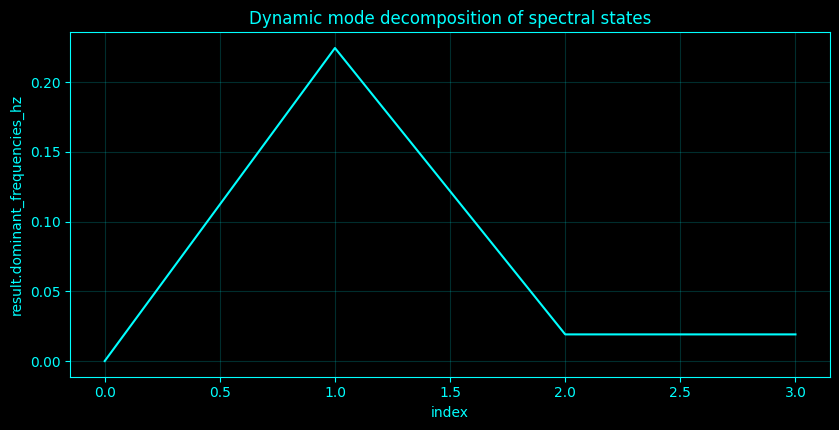

In [82]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_376():
    idx = 376
    name = 'Dynamic mode decomposition of spectral states'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    return ({'DMD_eigenvalues': eig[:min(8, len(eig))].tolist(), 'dominant_frequencies_hz': (np.abs(np.imag(omega)) / (2 * np.pi))[:min(8, len(eig))].tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_376,_plot_spec=_compute_method_376()
print('Dynamic mode decomposition of spectral states')
if isinstance(result_376,dict):
    for _k,_v in result_376.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_376)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_376)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Dynamic mode decomposition of spectral states',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Dynamic mode decomposition of spectral states',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Dynamic mode decomposition of spectral states',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">377. Koopman spectral analysis</h3>
<p>Koopman spectral analysis approximates the Koopman operator on chosen observables—in this notebook, log channel×band powers—using DMD. \(\Re\omega_k\) gives modal growth/decay and \(\Im\omega_k/(2\pi)\) the modal frequency.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Koopman spectral analysis
  Koopman_growth_rates: array(4,), mean=-0.532826
  Koopman_frequencies_hz: array(4,), mean=0.0561041
  observables: log channel × band power


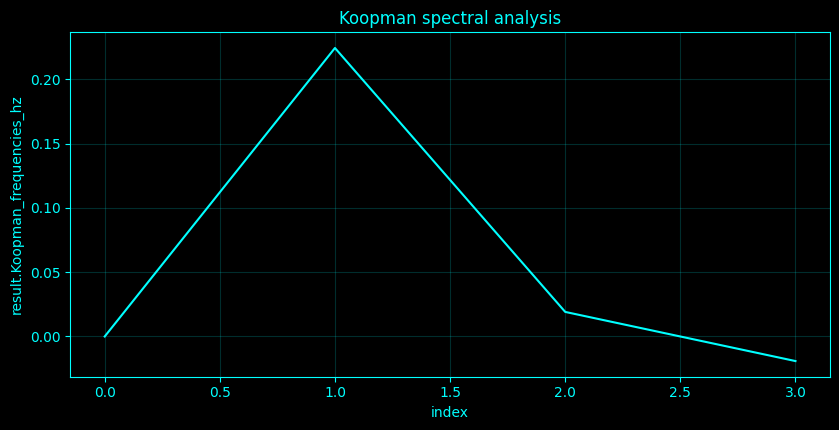

In [83]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

def _dmd(Xsnap, rank=None):
    X1 = Xsnap[:, :-1]
    X2 = Xsnap[:, 1:]
    U, s, Vh = np.linalg.svd(X1, full_matrices=False)
    r = min(int(rank or _SPEED['rank']), np.sum(s > 1e-10), len(s))
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh[:r].conj().T
    Atil = Ur.conj().T @ X2 @ Vr @ np.diag(1 / (sr + EPS))
    eig, W = np.linalg.eig(Atil)
    Phi = X2 @ Vr @ np.diag(1 / (sr + EPS)) @ W
    return (eig, Phi)

# Method-specific calculation.
def _compute_method_377():
    idx = 377
    name = 'Koopman spectral analysis'
    __plot_spec = None
    'Execute one catalogue method using the shared EEG segment and cached intermediates.'
    f, P = _welch_all()
    Xspec = np.log(P + EPS).T
    Xz = (Xspec - Xspec.mean(0)) / (Xspec.std(0) + EPS)
    ff, tt, S, _ = _stft_summary()
    T = np.transpose(np.log(S + EPS), (1, 0, 2))
    tw, W = _window_bandpower()
    snap = np.log(W + EPS).reshape(len(W), -1).T
    eig, Phi = _dmd(snap, rank=min(_SPEED['rank'], snap.shape[0], snap.shape[1] - 1))
    dt = float(np.median(np.diff(tw))) if len(tw) > 1 else 1.0
    omega = np.log(eig + 0j) / (dt + EPS)
    return ({'Koopman_growth_rates': np.real(omega[:min(8, len(omega))]).tolist(), 'Koopman_frequencies_hz': (np.imag(omega[:min(8, len(omega))]) / (2 * np.pi)).tolist(), 'observables': 'log channel × band power'}, locals().get('__plot_spec', None))
    raise KeyError(f'Catalogue method {idx}: {name} has no implementation')

result_377,_plot_spec=_compute_method_377()
print('Koopman spectral analysis')
if isinstance(result_377,dict):
    for _k,_v in result_377.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_377)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_377)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Koopman spectral analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Koopman spectral analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Koopman spectral analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)
